# [기말 과제] 와인 품질 예측

**작성자**: 김준  
**날짜**: 2025-11-28

## 0. 요구사항 및 목표

### 0.1 과제 요구 사항

* 가능하면 적은 갯수의 필드로 Quality를 예측합니다.
* Quality 예측이 잘 되었는지 평가하는 기계학습 성능지표를 잘 선정해야 합니다.
* 학생이 선호하는 기계학습 알고리즘을 사용합니다.
* 사용하는 알고리즘이 파라미터를 많이 사용하는 것이라면, mlflow를 활용하는 것을 권장합니다.
* mlflow 사용했을 경우, mlruns 폴더 전체를 zip 파일로 archive 하여 제출합니다.
* 4000여개의 데이터를 제공하였고, 학생의 성과는 제공되지 않은 900여개의 데이터로 평가합니다.
* 간혹 이상치가 있을 수 있으니, 이상치를 제거하는 전처리 작업도 시행하여야 합니다

### 0.2 목표

* **데이터 엔지니어링 + 기계학습 + 설명 및 분석**
* `wine_data_homework.csv` 데이터를 활용하여 와인의 품질(Quality)을예측하는 모델을 개발하는 것을 목표로 합니다. 
* 단순한 모델링을 넘어, 데이터의 통계적 특성을 분석하고 양조학적 도메인지식을 활용한 피처 엔지니어링, 그리고 MLflow를 활용한 체계적인 실험 관리를수행합니다. 
* 각 단계의 의사결정 과정을 투명하게 시각화하여 논리적 타당성을 확보합니다. 
  * 코드 셀 앞 markdown 셀: 코드 셀의 목표, 사용 기법의 목적, 사용 기법의 원리, 사용 기법의 예상 결과
  * 코드 셀: 다양한 기법을 활용할 경우 성능평가 필요, 성능평가 및 결과 산출울 위한 다양한 시각화 자료
  * 코드 셀 뒤 markdown 셀: 코드 셀의 결과 분석, 결론
  
### 0.3 핵심 요구사항 및 해결 전략

1.  **Deep EDA**: 단순 분포 확인을 넘어, 품질(Quality) 등급별 변수의 차이를 비교 분석합니다.
- 1.1 데이터 구조 파악(통계 요약)
- 1.2 결측치 탐색 -> 결측치없음 확인
- 1.3 변수 분포 확인('KDE plot', target 분포 확인) -> 클래스 불균형 확인 -> SMOTETomek 필요 확인
- 1.4 변수 간 관계 탐색(correlation heatmap, VIF) -> 다중공선성 확인
- 1.5 이상치 탐색(`Boxplot`) -> 이상치 탐색이 필요함 확인
- 1.6 target 과 관계 분석(`Boxplot`)
2. 데이터 분리
- 2.1 StratifiedKFold 로 train / test 분리
3. 이상치 처리
- 3.1 PCA 분석 -> PCA 로 IQR 과 Isolation Forest 이상치 비교해서 IF 선택
4. ElasticNet 으로 baseline 모델링
- 4.1 ElasticNet 모델링(Pipeline:정규화(StandardScaler), Cross Validation(RepeatKFold))
5. 피처 엔지니어링
- 5.1 파생변수 생성 (연산, 도메인 지식기반)
- 5.2 변수 간 관계 탐색(correlation heatmap) -> 피처 선택
- 5.3 VIF 확인 -> 피처 선택
- 5.4 분석 후 피처 선택
6. 샘플링
- 6.1 샘플링 방법 비교 -> SMOTETomek 선택
7. 모델링
- 7.1 데이터 나눔 (LOOCV) 
- 7.2 분류모델 - 모델 별 샘플링 정규화 적용
- 7.3 회귀모델 - 모델 별 샘플링 정규화 적용
- 7.4 두 접근 방식의 성능을 정량적으로 비교하고 시각화하여 어떤 방식이 더 적합한지 결론을 도출
    - 분류모델 분석(주요지표: Accuracy, Precision, Recall, F1-Score, 시각화: Confusion Matrix, ROC-AUC)
    - 회귀모델 분석(주요지표: RMSE, MAE, R2 시각화: Residual Plot)
- 7.5 QWK 로 Best 모델 선정 
    - Wine Quality에서 QWK는 회귀·분류 모델을 공정하게 비교할 수 있는 “가장 설득력 있는 공통 지표”다
    - Quality 점수의 순서적 특성을 반영하기 위해 Quadratic Weighted Kappa(QWK)를 추가 지표로 사용하였다.
    - 이는 ±1 점수 오차에 대해 관대한 평가를 제공하며, 실제 와인 품질 평가자의 주관적 판단과 유사한 특성을 갖는다.
- 7.6 모델저장
- 7.7 모델 선정 분석 보고서
8. 모델 배포
- 8.1 새로운 데이터 로드 - 4001 번부터 데이터 사용
- 8.2 모델 사용

9.  **이상치 처리**: 데이터의 노이즈를 줄이기 위해 IQR 및 Isolation Forest 기법을 비교 분석하여 최적의 이상치 제거 전략을 수립합니다. 이상치 제거 전후의 데이터 손실과 분포 개선의 트레이드오프를 확인합니다.
10. **최소한의 피처 사용**: 다중공선성(Multicollinearity)을 피하고 모델의 일반화 성능을 높이기 위해 중요 변수(Feature Importance)를 선별합니다.
11. **MLflow 활용**: 하이퍼파라미터 튜닝 과정과 실험 결과를 MLflow로 추적하여 모델의 재현성을 확보합니다.
12. **일반화 성능 확보**: 과적합(Overfitting)을 방지하기 위해 교차 검증(Cross Validation)과 홀드아웃 테스트 셋을 엄격히 분리합니다.
13. **Model Evaluation**: 예측 결과의 잔차(Residual) 패턴과 혼동 행렬(Confusion Matrix)을 시각화하여 모델의 약점을 파악합니다.
14. **최종 검증**: 제공된 `wine-quality_searched.csv`의 특정 구간(4001~4897행)을 사용하여 최종 모델의 성능을 평가합니다.




### 0.4 전체 분석 파이프라인 (Process Architecture)

데이터 로드 -> 데이터 확인 -> 


1.  **Data Loading & Split**: 데이터 로드 및 Train/Test 분리 (Data Leakage 원천 차단)
2.  **Deep EDA**: 분포 확인, 상관관계 분석, 시각화를 통한 인사이트 도출
3.  **Outlier Detection**: IQR vs Isolation Forest 비교 실험 및 적용
4.  **Feature Engineering**: 도메인 기반 파생 변수 생성 및 검증
5.  **Preprocessing**: Scaling, Encoding, Imbalance Handling (SMOTE)
6.  **Modeling & Optimization**: MLflow 기반 모델 비교 (ElasticNet, RF, XGBoost)
7.  **Evaluation & Interpretation**: SHAP 분석 및 잔차 분석
8.  **Final Deployment**: 히든 테스트 셋에 대한 최종 예측

---

#### 목표
- [코드 셀의 목표 설명]

#### 사용 기법
- **[기법명]**: [기법의 목적]

#### 원리
- [기법의 작동 원리 설명]

#### 예상 결과
- [실행 후 예상되는 결과]

## 1. 데이터 준비 및 탐색적 데이터 분석

In [4]:
import sys
sys.executable


'c:\\Users\\junkim\\MyProjects\\mlflow_wine\\.venv\\Scripts\\python.exe'

In [5]:
where python

SyntaxError: invalid syntax (2490086425.py, line 1)

### 1.1 환경설정 및 데이터 로드

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import mlflow
import mlflow.sklearn

# 머신러닝 및 전처리 관련 라이브러리
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.metrics import classification_report, cohen_kappa_score, make_scorer, mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from catboost import CatBoostRegressor, CatBoostClassifier
from lightgbm import LGBMRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import FunctionTransformer



# 시각화 설정 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정
plt.rc('axes', unicode_minus=False)
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 고정
SEED = 42
np.random.seed(SEED)

# MLflow 설정 (로컬 저장소 사용)
mlflow.set_tracking_uri("./mlruns")
experiment_name = "HW_Wine_Quality"
mlflow.set_experiment(experiment_name)
mlflow.sklearn.autolog(log_models=True) # Pipeline도 자동 기록됨
print(f"MLflow experiment set to: {experiment_name}")

# 1. 데이터 로드
try:
    df_full = pd.read_csv('../wine_data_homework.csv', index_col=0)
    print("데이터 로드 완료. Shape:", df_full.shape)
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

print("\n=== 기본 통계 정보 ===")
print(df_full.head())

ModuleNotFoundError: No module named 'matplotlib.pyplot'

### 1.2 구조 파악 및 결측치 파악

In [ ]:
# 기본 정보 확인
print("=== 데이터 구조 파악 ===")
df_full.info()
df_full.describe()

# 결측치 확인
print("\n=== 데이터 결측치 확인 ===")
missing_values = df_full.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0])
if missing_values.sum() > 0:
    print(f"총 결측치: {missing_values.sum()}개")
else:
    print("결측치가 없습니다.")


=== 데이터 구조 파악 ===
<class 'pandas.core.frame.DataFrame'>
Index: 4001 entries, 0 to 4000
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4001 non-null   float64
 1   volatile acidity      4001 non-null   float64
 2   citric acid           4001 non-null   float64
 3   residual sugar        4001 non-null   float64
 4   chlorides             4001 non-null   float64
 5   free sulfur dioxide   4001 non-null   float64
 6   total sulfur dioxide  4001 non-null   float64
 7   density               4001 non-null   float64
 8   pH                    4001 non-null   float64
 9   sulphates             4001 non-null   float64
 10  alcohol               4001 non-null   float64
 11  quality               4001 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 406.4 KB

=== 데이터 결측치 확인 ===
Missing Values per Column:
Series([], dtype: int64)
결측치가 없습니다.


#### 함수: Count plot
* **목적**: 타겟 변수의 클래스별 분포를 시각화하여 **데이터 불균형(Imbalance)** 상태를 직관적으로 파악
* **시각화**: Seaborn `countplot`을 사용하며, 각 막대 상단에 전체 대비 **비율(%)을 텍스트로 주석 처리(`annotate`)**
* **분석 로직**: 특정 임계값(약 14.3%) 기준으로 다수/소수 클래스를 구분하고, **불균형 비율(Imbalance Ratio)**을 계산하여 출력
* **입력 처리**: 다양한 형태의 입력 데이터를 `pd.Series`로 자동 변환하여 호환성 확보
* **결과**: 클래스별 빈도수 그래프 출력 및 콘솔에 불균형 지표 로그 기록

In [ ]:
def plot_target_distribution(y_data, title="타겟 변수 분포 분석", xlabel="Quality Score", ylabel="Count", figsize=(10, 5), palette='viridis'):
    """
    타겟 변수의 분포를 Count Plot으로 시각화하고, 각 클래스의 비율(%)을 표시합니다.

    Args:
        y_data (pd.Series or np.array): 시각화할 타겟 변수 데이터 (e.g., y_train).
        title (str): 그래프의 제목.
        xlabel (str): x축 레이블.
        ylabel (str): y축 레이블.
        figsize (tuple): 그래프의 크기.
        palette (str): Seaborn 색상 팔레트.
    """
    if not isinstance(y_data, pd.Series):
        try:
            # y_data가 Series가 아니면 Series로 변환 시도
            y_data = pd.Series(y_data)
        except:
            print("오류: y_data는 pandas Series 또는 Series로 변환 가능한 형태여야 합니다.")
            return

    plt.figure(figsize=figsize)
    
    # 1. Count Plot 생성
    ax = sns.countplot(x=y_data, palette=palette)
    
    # 2. 막대 위에 비율(%) 표시
    total = len(y_data)
    low_class_percentages = 0
    high_class_percentages = 0
    low_class_count = 0
    high_class_count = 0
    for p in ax.patches:
        height = p.get_height()
        # 높이가 0이 아닌 경우에만 비율을 계산하고 표시
        if height > 0:
            percentage = '{:.1f}%'.format(100 * height / total)
            percentage_float = (100 * height / total)
            # x 좌표: 막대의 중앙
            x = p.get_x() + p.get_width() / 2
            # y 좌표: 막대 끝에서 약간 위에 위치
            y = height
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)
            if percentage_float < (100 / 7):
                low_class_percentages = low_class_percentages + percentage_float
                low_class_count = low_class_count + 1
            else:
                high_class_percentages = high_class_percentages + percentage_float
                high_class_count = high_class_count + 1

    print("Low class percentages: ", low_class_percentages)
    print("High class percentages: ", high_class_percentages)
    print(f"Imbalance Ratio (IR): (다수 클래스 수({high_class_count})) / (소수 클래스 수({low_class_count})): {high_class_percentages} / {low_class_percentages}")
    
    # 3. 제목 및 레이블 설정
    plt.title(f'{title} - 클래스 불균형 확인', fontsize=15)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

#### 함수: 수치형 변수들의 분포 (`Histogram & KDE`)
* **목적**: 수치형 독립 변수들의 데이터 분포 형태(정규성, 왜도)를 시각적으로 분석
* **전처리**: `select_dtypes`를 사용하여 수치형 컬럼만 자동으로 필터링하여 에러 방지
* **시각화**: Seaborn `histplot(kde=True)`을 통해 **히스토그램과 밀도 곡선(KDE)**을 동시에 표현
* **레이아웃**: 전체 피처 개수에 맞춰 Subplot의 행(`n_rows`)과 열 개수를 동적으로 계산 및 배치
* **결과**: `tight_layout`이 적용되어 가독성이 최적화된 다중 분포 그래프 출력

In [ ]:
# 수치형 변수들의 분포 (Histogram & KDE)
def plot_numerical_distribution(X_data, n_cols=3, bins=30, color='skyblue', figsize_per_row=4):
    """
    수치형 독립 변수들의 분포를 히스토그램과 KDE 플롯으로 시각화합니다.
    
    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        n_cols (int): 한 행에 표시할 서브플롯의 개수. 기본값은 3.
        bins (int): 히스토그램의 막대(bin) 개수.
        color (str): 플롯의 색상.
        figsize_per_row (int): 한 행당 높이 비율을 결정하는 값.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return
        
    # 수치형 변수만 선택
    # 와인 데이터셋은 보통 모든 피처가 수치형이지만, 안전을 위해 필터링
    numerical_features = X_data.select_dtypes(include=np.number).columns
    
    if numerical_features.empty:
        print("오류: X_data에 시각화할 수 있는 수치형 변수가 없습니다.")
        return

    n_features = len(numerical_features)
    # 필요한 행의 개수 계산
    n_rows = (n_features + n_cols - 1) // n_cols

    # 전체 Figure 크기 설정
    plt.figure(figsize=(20, figsize_per_row * n_rows))
    
    print(f"총 {n_features}개의 수치형 피처 분포를 생성합니다.")

    # 각 피처에 대해 반복하며 서브플롯 생성
    for i, col in enumerate(numerical_features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Histplot 생성 (kde=True로 KDE 곡선 함께 표시)
        sns.histplot(X_data[col], kde=True, bins=bins, color=color)
        
        plt.title(f'{col} Distribution', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Density / Count')
        
    plt.tight_layout()
    plt.show()

#### 함수: target 과 관계 분석(`Botplot`)
* **목적**: 타겟 변수(Quality)의 클래스별 독립 변수들의 통계적 분포(중앙값, IQR, 이상치) 차이를 비교 분석
* **시각화**: Seaborn `boxplot`을 사용하여 피처가 타겟 클래스를 얼마나 잘 구분하는지 직관적으로 확인
* **자동화**: 전체 피처 개수에 맞춰 Subplot 그리드(행/열)를 동적으로 계산하여 한 번에 출력
* **분석 포인트**: 클래스 간 박스 높낮이 차이가 클수록 해당 피처의 타겟 변별력이 높음을 시사
* **디자인**: `coolwarm` 색상과 `grid` 옵션을 적용하여 데이터 분포의 시인성 강화

In [ ]:
# 피처별 Quality 구분 능력 분석 (Boxplot)
def plot_feature_quality_boxplots(X_data, y_data, n_cols=3, figsize_per_row=5):
    """
    각 독립 변수(Feature)가 타겟 변수(Quality)에 따라 어떻게 분포하는지 Boxplot으로 시각화합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
        n_cols (int): 한 행에 표시할 서브플롯의 개수. 기본값은 3.
        figsize_per_row (int): 한 행당 높이 비율을 결정하는 값. (전체 높이 = n_rows * figsize_per_row)
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return
    
    features = X_data.columns
    n_features = len(features)
    # 필요한 행의 개수 계산
    n_rows = (n_features + n_cols - 1) // n_cols

    # 전체 Figure 크기 설정
    plt.figure(figsize=(20, figsize_per_row * n_rows))

    print(f"총 {n_features}개의 피처에 대해 Quality별 Boxplot을 생성합니다.")

    # 각 피처에 대해 반복하며 서브플롯 생성
    for i, col in enumerate(features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Boxplot으로 중앙값과 분포 비교
        # x축은 타겟 변수, y축은 현재 피처
        sns.boxplot(x=y_data, y=X_data[col], palette='coolwarm')
        
        plt.title(f'{col} vs Quality', fontsize=14, fontweight='bold')
        plt.xlabel('Quality Score')
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

#### 함수: 변수 간 상관관계 분석(`Correlation Heatmap`)
* **목적**: 변수 간 상관관계(Heatmap)와 타겟 변수와의 선형 관계(Bar Plot)를 시각화하여 분석
* **기능**: 피처 간 다중공선성을 시각적으로 확인하고, 타겟에 미치는 영향력을 수치화하여 표현
* **로직**: 사용자 정의 임계값(High/Medium)을 기준으로 피처를 분류하고 유효 변수 자동 식별
* **출력**: 임계값을 초과하는 중요 피처들을 `{변수명: 상관계수_절대값}` 딕셔너리로 반환
* **활용**: 모델 학습에 불필요한 노이즈 변수를 제거하고 핵심 변수를 선별하는 필터링 단계 수행

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
selected_corr_features = {}
def visualize_and_classify_correlation(X_data, y_data, target_name='quality', high_threshold=0.2, medium_threshold=0.1):
    """
    변수 간 상관관계 Heatmap과 타겟 변수와의 상관관계 Barh 플롯을 생성하고,
    상관계수 임계값에 따라 피처를 분류하여 선택된 피처 딕셔너리를 반환합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
        target_name (str): 타겟 변수의 이름. 기본값은 'quality'.
        high_threshold (float): 높은 상관관계의 임계값 (절댓값 기준).
        medium_threshold (float): 중간 상관관계의 임계값 (절댓값 기준).

    Returns:
        dict: 높은 상관관계와 중간 상관관계를 가진 피처와 그 절대값 상관계수 (selected_corr_features).
              Format: {'feature_name': abs(correlation_value)}
    """
    
    # 1. 상관관계 계산
    combined_df = pd.concat([X_data, y_data.rename(target_name)], axis=1)
    correlation_matrix = combined_df.corr()
    
    # 타겟 변수와의 상관관계 추출 및 내림차순 정렬
    target_correlation = correlation_matrix[target_name].drop(target_name).sort_values(ascending=False)

    # 2. 서브플롯 설정
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('변수 간 상관관계 분석 및 타겟 변수와의 관계 시각화', fontsize=18, y=1.02)

    # --- Subplot 1: 상관관계 Heatmap (Triangle Heatmap) ---
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='RdBu_r', 
                ax=axes[0], fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, center=0,
                cbar_kws={'shrink': 0.8})
    axes[0].set_title('변수 간 다중공선성 확인 (Correlation Heatmap)', fontsize=15)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    # --- Subplot 2: 타겟 변수와의 상관관계 Barh ---
    
    # Bar Plot 생성 (수평 막대 그래프)
    bars = axes[1].barh(target_correlation.index, target_correlation.values, 
                        color=np.where(target_correlation.values > 0, 'skyblue', 'salmon'))

    axes[1].set_title(f'타겟 변수 ({target_name})와의 상관관계', fontsize=15)
    axes[1].set_xlabel('상관계수 값')
    axes[1].set_ylabel('특성 변수')
    axes[1].set_xlim(-1, 1) # x축 범위를 -1에서 1로 설정

    # 임계값 표시 (수직선)
    axes[1].axvline(high_threshold, color='green', linestyle='--', linewidth=1.5, label=f'High Threshold ({high_threshold})')
    axes[1].axvline(-high_threshold, color='green', linestyle='--', linewidth=1.5)
    axes[1].axvline(medium_threshold, color='orange', linestyle=':', linewidth=1.5, label=f'Medium Threshold ({medium_threshold})')
    axes[1].axvline(-medium_threshold, color='orange', linestyle=':', linewidth=1.5)
    axes[1].legend(loc='lower right')

    # 막대 끝에 값 표시
    for bar in bars:
        width = bar.get_width()
        axes[1].text(width, bar.get_y() + bar.get_height()/2, 
                     f'{width:.2f}',
                     va='center', ha='left' if width > 0 else 'right',
                     fontsize=10, color='black' if abs(width) < 0.8 else 'white')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # --- 상관관계에 따른 변수 분류 및 저장 ---
    # abs()를 사용하여 절대값 기준으로 필터링
    high_corr_features = target_correlation[target_correlation.abs() > high_threshold].index.tolist()
    medium_corr_features = target_correlation[(target_correlation.abs() > medium_threshold) & (target_correlation.abs() <= high_threshold)].index.tolist()
    low_corr_features = target_correlation[target_correlation.abs() <= medium_threshold].index.tolist()

    print("\n=== 상관관계에 따른 변수 분류 ===")
    print(f"High correlation features with {target_name} (> {high_threshold}): {high_corr_features}")
    print(f"Medium correlation features with {target_name} ({medium_threshold} < |r| <= {high_threshold}): {medium_corr_features}")
    print(f"Low correlation features with {target_name} (<= {medium_threshold}): {low_corr_features}")

    # [수정됨] 선택된 상관관계 변수 딕셔너리 생성 (Feature Name : Abs(Correlation))
    # High와 Medium에 해당하는 변수들을 합친 리스트
    selected_features_list = high_corr_features + medium_corr_features
    
    # 딕셔너리 컴프리헨션을 이용해 {이름: 절대값} 형태로 저장
    selected_corr_features = {
        feature: abs(target_correlation[feature]) 
        for feature in selected_features_list
    }
    
    # 절대값 크기 순으로 내림차순 정렬 (선택 사항, 보기 좋게 하기 위함)
    selected_corr_features = dict(sorted(selected_corr_features.items(), key=lambda item: item[1], reverse=True))

    print(f"\n선택된 상관관계 변수 딕셔너리 (High + Medium, Abs Value):")
    print(selected_corr_features)
    
    return selected_corr_features

#### 함수: 다중공선성 분석(`VIF`)
* **목적**: 독립 변수들 간의 강한 상관관계(다중공선성)를 수치화하여 모델의 불안정성 방지
* **계산 로직**: `variance_inflation_factor`를 사용하여 각 변수의 설명력이 다른 변수들로 얼마나 설명되는지 측정
* **시각화**: VIF 수치를 수평 막대 그래프로 표현하고, 임계값(기본 10) 초과 시 **빨간색으로 경고** 표시
* **필터링**: 설정된 `vif_threshold`를 기준으로 **사용 가능 피처**와 **제거 대상(고위험) 피처**를 자동 분류
* **출력**: 시각화 차트와 함께 VIF 임계값을 통과한 피처/탈락한 피처 리스트 반환

In [ ]:
def calculate_vif(df):
    """VIF 계산 함수 - 다중공선성 분석"""
    # 데이터프레임이 비어있거나 단일 열인 경우 처리
    if df.shape[1] == 0:
        return pd.DataFrame({'Features': [], 'VIF': []})
    
    vif = pd.DataFrame()
    vif["Features"] = df.columns
    
    # 단일 변수는 VIF가 정의되지 않거나 1.0
    if df.shape[1] == 1:
        vif["VIF"] = 1.0
    else:
        # variance_inflation_factor는 numpy 배열을 사용합니다.
        vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
        
    return vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)

def run_vif_analysis(X_data, vif_threshold=10):
    """
    독립 변수의 VIF를 계산하고 시각화하며, VIF 임계값 미만인 피처 목록을 반환합니다. 
    (스케일링 전 기준 분석)

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        vif_threshold (int): 다중공선성 판단 VIF 임계값. 기본값은 10.

    Returns:
        list: VIF 임계값 미만인 피처 목록.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return []

    # 1. VIF 계산
    vif_results = calculate_vif(X_data)
    
    print(f"\nVIF 분석 결과 (VIF > {vif_threshold}: 다중공선성 의심):")
    print(vif_results)
    
    # 2. VIF 시각화
    plt.figure(figsize=(12, 6))
    
    # VIF 임계값 기준으로 색상 설정
    colors = ['red' if v > vif_threshold else 'green' for v in vif_results['VIF']]
    
    plt.barh(vif_results['Features'], vif_results['VIF'], color=colors)
    plt.axvline(x=vif_threshold, color='red', linestyle='--', label=f'VIF = {vif_threshold} (임계값)')
    
    plt.xlabel('VIF')
    plt.title('VIF (Variance Inflation Factor) - 다중공선성 분석', fontsize=15)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. VIF 기준 피처 선택
    vif_selected = vif_results[vif_results['VIF'] < vif_threshold]['Features'].tolist()
    vif_not_selected = vif_results[vif_results['VIF'] >= vif_threshold]['Features'].tolist()

    print(f"\nVIF < {vif_threshold}인 피처 ({len(vif_selected)}개): {vif_selected}")
    print(f"\nVIF >= {vif_threshold}인 피처 ({len(vif_not_selected)}개): {vif_not_selected}")

    return vif_selected, vif_not_selected

#### 함수: 데이터 전처리 확인(`Botplot`, `Histogram&KDE`, `correlation`, `VIF`)
* **목적**: 데이터 분포 시각화부터 다중공선성(VIF), 상관관계 분석까지 일괄 수행하는 종합 검증(Wrapper) 함수
* **시각화**: `Boxplot`(구분 능력)과 `Histogram`(분포 형태)을 호출하여 데이터의 기초 통계적 특성 파악
* **단계적 필터링**: **VIF 분석**을 선행하여 다중공선성 위험 변수를 1차 제거(`selected_vif_features`)
* **상관관계 분석**: VIF를 통과한 변수들에 대해서만 타겟과의 상관관계를 분석하여 최종 변수 선별
* **출력**: 다중공선성이 해소되고 일정 수준 이상의 상관관계를 가진 **최종 유효 피처 목록**을 콘솔에 출력

In [ ]:
# 데이터 전처리를 확인
# 피처별 Quality 구분 능력 분석 (Boxplot)
# 수치형 변수들의 분포 (Histogram & KDE)
# 상관관계 확인
# VIF 분석
# 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
def check_data(X_data, y_data, stage="None"):
    """
    데이터 전처리를 확인합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
    """
    # 피처별 Quality 구분 능력 분석 (Boxplot)
    plot_feature_quality_boxplots(X_data, y_data)
    # 수치형 변수들의 분포 (Histogram & KDE)
    plot_numerical_distribution(X_data)

    # VIF 분석
    selected_vif_features, _ = run_vif_analysis(X_data)
    # # 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
    # print("=" * 20, "스케일링 후 VIF","=" * 20)
    # scaler_temp = StandardScaler()
    # X_scaled_temp = pd.DataFrame(
    #     scaler_temp.fit_transform(X_data),
    #     columns=X_data.columns
    # )
    # selected_vif_features = run_vif_analysis(X_scaled_temp)

    # 상관관계 확인
    selected_corr_features = visualize_and_classify_correlation(X_data[selected_vif_features], y_data, 
                                                        target_name='quality', 
                                                        high_threshold=0.2, 
                                                        medium_threshold=0.1)

    # 상관관계와 VIF 를 통한 변수 선택
    print(f"상관관계와 VIF를 통한 변수 선택({stage}): {len(selected_corr_features)}개 {selected_corr_features}")

#### 함수: 이상치 탐색(`IQR`)
* **목적**: 사분위수 범위(IQR)를 활용하여 통계적으로 비정상적인 분포를 보이는 이상치(Outlier) 식별
* **핵심 로직**: $Q1$(25%)과 $Q3$(75%)를 계산하고, IQR($Q3-Q1$)의 $n$배(기본 1.5)를 벗어나는 한계선 설정
* **판단 기준**: 관측치 중 **단 하나의 컬럼이라도** 허용 범위를 벗어나면(`any`) 해당 행 전체를 이상치로 간주
* **출력 정보**: 각 피처별 정상 데이터 범위(Lower/Upper Bound)를 콘솔에 출력하여 분포 폭 확인
* **반환값**: 데이터프레임 내에서 이상치가 위치한 행의 **위치 기반 인덱스(Positional Index)** 배열 반환

In [ ]:
def detect_outliers_iqr(df, n=1.5):
    """
    IQR 방법을 사용하여 데이터프레임 내의 이상치를 탐지하고,
    이상치로 판단된 행의 위치 인덱스(positional index)를 반환합니다.
    
    Args:
        df (pd.DataFrame): 이상치를 탐지할 데이터프레임 (예: X_train).
        n (float): IQR 배수 (일반적으로 1.5).
        
    Returns:
        np.array: 이상치로 판단된 행의 위치 기반 인덱스 배열.
    """
    
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 범위: Q1 - n*IQR ~ Q3 + n*IQR
    lower_bound = Q1 - n * IQR
    upper_bound = Q3 + n * IQR
    
    print("=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===")
    outlier_info = pd.DataFrame({
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })
    print(outlier_info)

    # 1. 이상치 조건 (어떤 컬럼이라도 범위 밖에 있는 경우)
    outlier_condition = ((df < lower_bound) | (df > upper_bound)).any(axis=1)
    
    # 2. 이상치로 판단된 행의 위치 기반 인덱스를 찾기
    # np.where는 True인 값들의 인덱스를 튜플 형태로 반환합니다.
    # [0]을 사용하여 행 인덱스만 추출합니다.
    outlier_pos_indices = np.where(outlier_condition)[0]
    
    return outlier_pos_indices

#### 함수: 이상치 탐색(`Isolation Forest`)
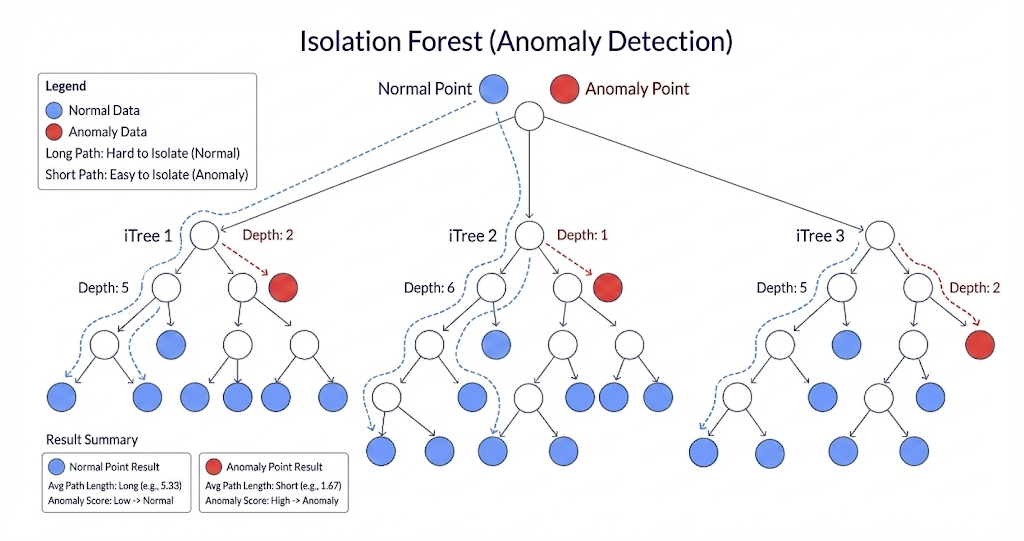
* **목적**: 다변량 데이터의 분포 관계를 고려하여 비지도 학습(Unsupervised Learning) 방식으로 이상치 탐지
* **알고리즘**: `IsolationForest`를 사용하여 데이터가 **고립(Isolation)** 되기 쉬운 관측치를 이상치로 판별
* **설정**: `contamination=0.05` 파라미터를 통해 전체 데이터 중 상위 **5%**를 이상치로 가정하고 학습
* **작동 원리**: 무작위 분할 시 정상 데이터보다 더 짧은 경로(Depth)로 분리되는 포인트(Anomalies)를 식별
* **반환값**: 모델이 `-1`(이상치)로 예측한 행의 **위치 인덱스(Positional Index)** 배열 반환

In [ ]:
# 4.2 Isolation Forest 방식
def detect_outliers_if(X):
    # contamination: 이상치 비율 예상치 (약 5%로 가정)
    clf = IsolationForest(max_samples='auto', random_state=SEED, contamination=0.05)
    preds = clf.fit_predict(X)
    return np.where(preds == -1)[0] # -1이 이상치


#### 함수: PCA
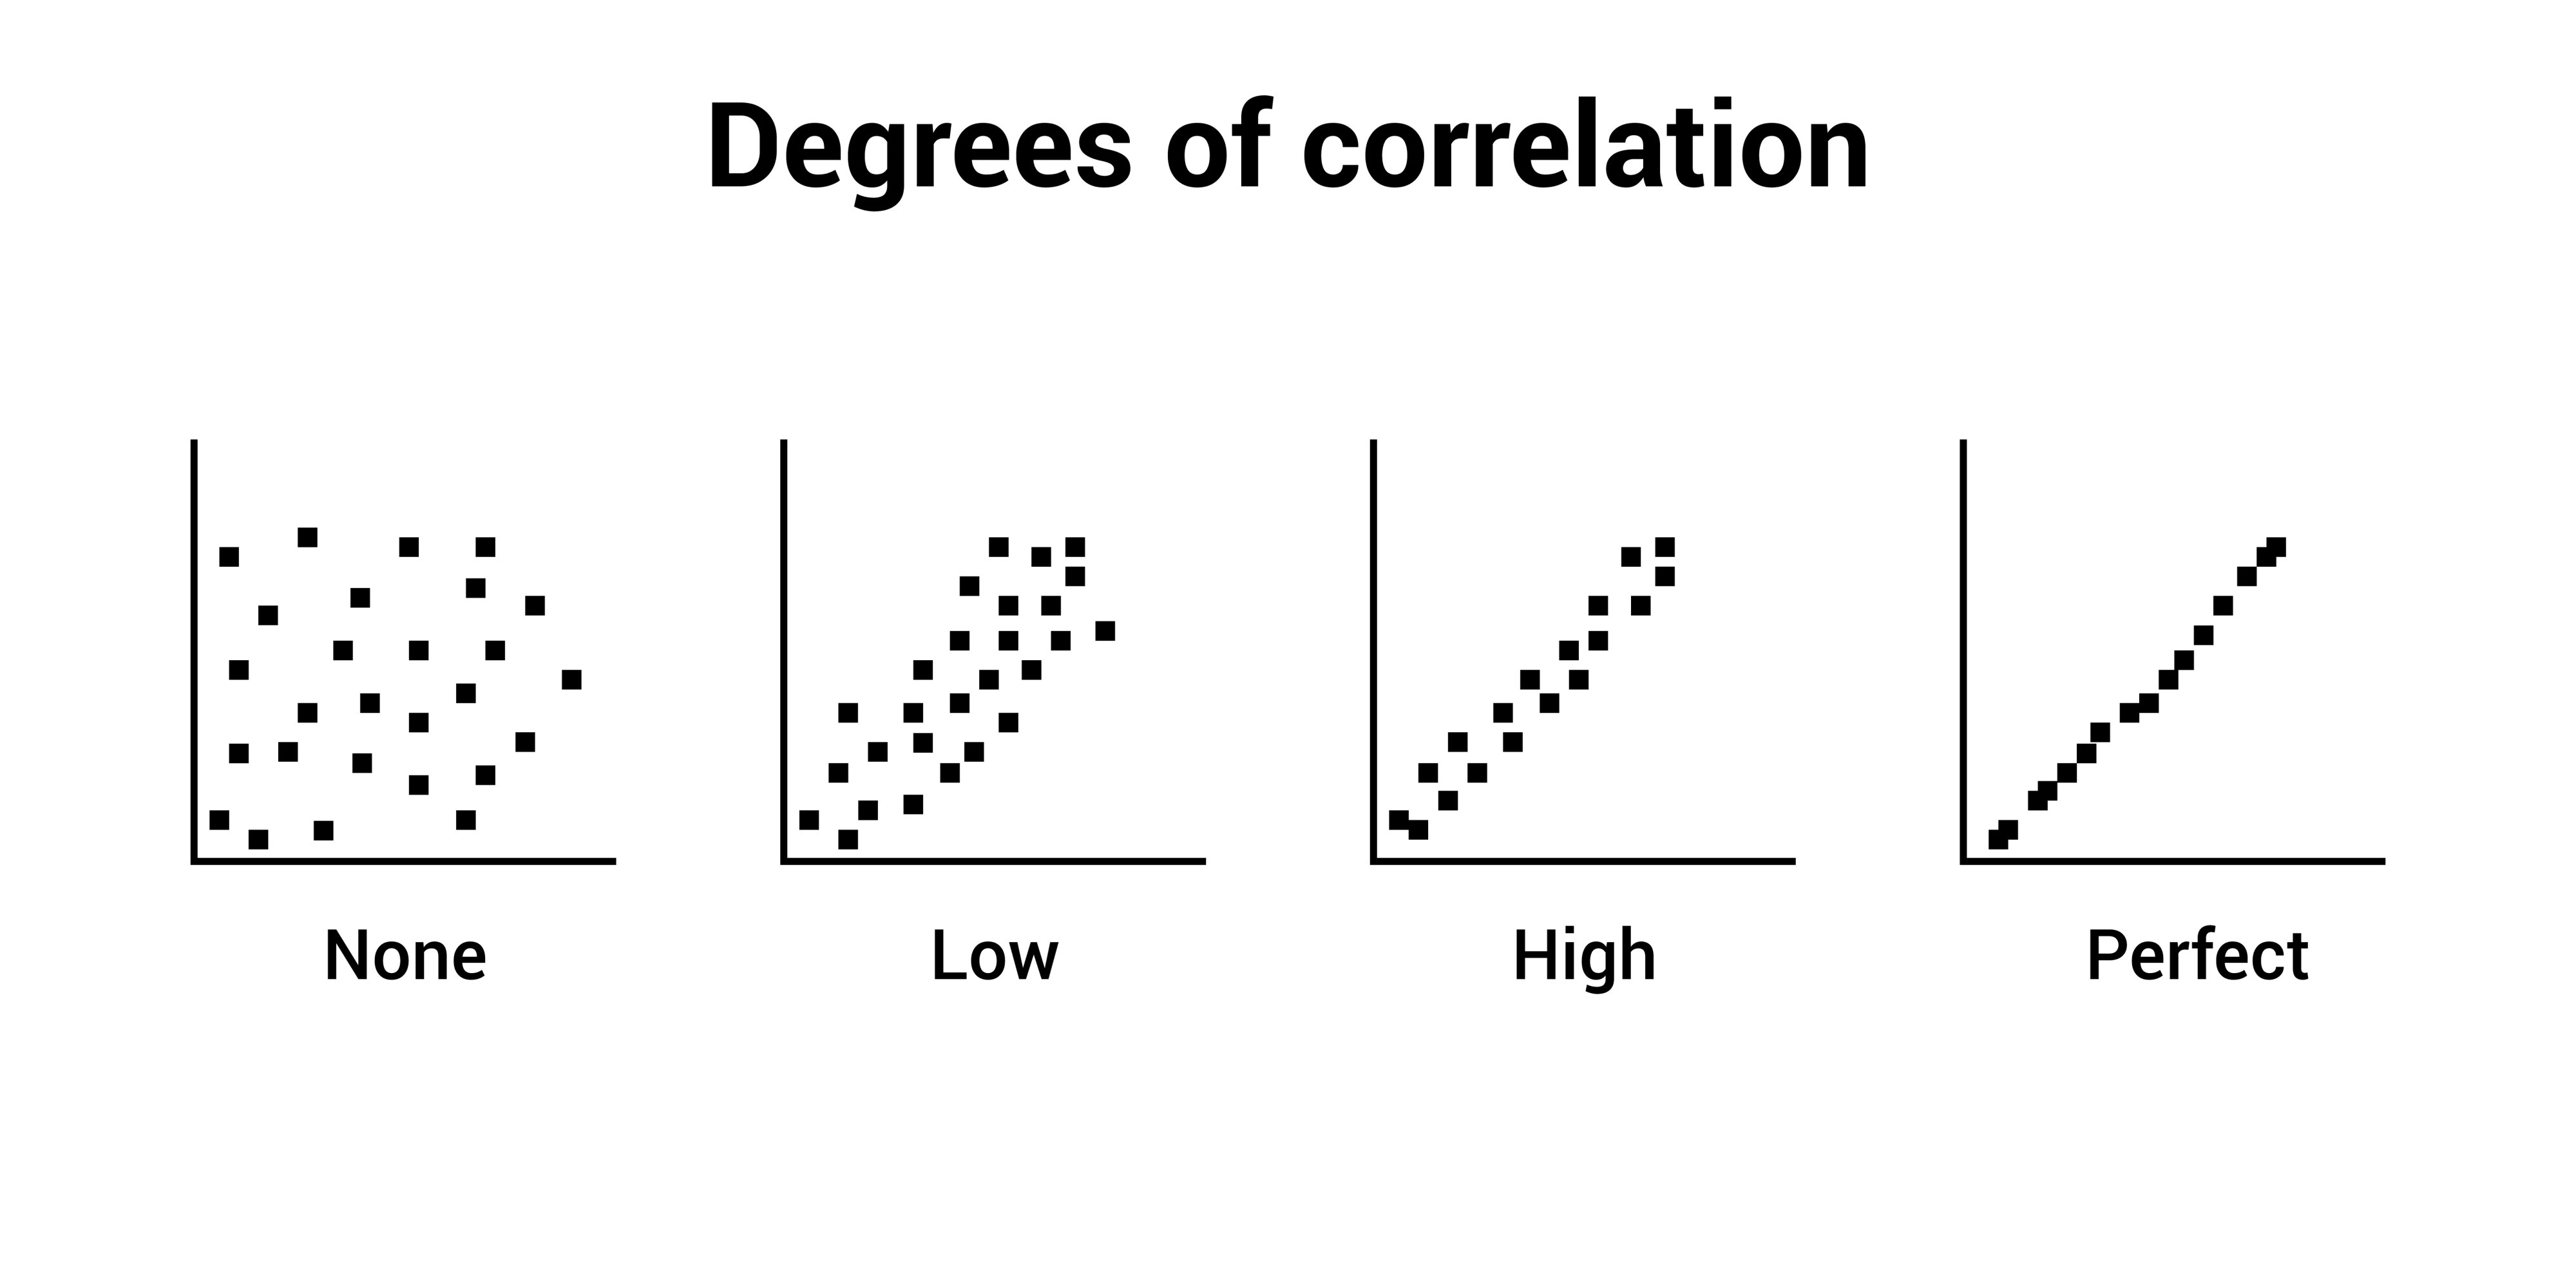
* **목적**: IQR(통계적 범위)과 Isolation Forest(밀도/거리 기반)의 **이상치 탐지 패턴 차이**를 시각적으로 비교 분석
* **차원 축소**: `StandardScaler` 후 `PCA`를 적용하여 다차원 데이터를 시각화 가능한 **2차원(PC1, PC2) 좌표로 변환**
* **분류 로직**: 두 알고리즘의 결과를 교차 확인하여 데이터를 **4가지 유형**(정상, IQR독점, IF독점, 교집합)으로 분류
* **시각화**: 유형별로 색상과 마커를 다르게 지정하고, **이상치(Both/Exclusive)를 강조**하여 분포 특성 확인
* **결과**: 단변량 이상치(IQR)와 다변량 이상치(IF)가 각각 데이터 공간의 어디에 위치하는지 직관적으로 파악

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# --- 새로운 함수 추가: 두 방법 비교 시각화 ---
def compare_outliers_scatter(X_data, detect_iqr_func, detect_if_func, title="IQR vs Isolation Forest 이상치 비교 (PCA)"):
    """
    PCA를 사용하여 데이터 차원을 2D로 축소하고, IQR과 Isolation Forest로 탐지된
    이상치를 산점도로 시각적으로 비교하는 함수입니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        detect_iqr_func (function): IQR 이상치를 탐지하고 위치 인덱스를 반환하는 함수.
        detect_if_func (function): Isolation Forest 이상치를 탐지하고 위치 인덱스를 반환하는 함수.
        title (str): 그래프의 제목.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return

    # 1. 데이터 전처리 및 PCA 수행
    
    # PCA는 스케일에 민감하므로 StandardScaler를 사용하여 데이터를 표준화합니다.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    
    # PCA를 사용하여 2개의 주성분으로 축소
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    
    # 2. 두 가지 방법으로 이상치 탐지 및 마스킹
    
    # 탐지 함수 호출 (위치 인덱스를 반환)
    outliers_iqr_pos = detect_iqr_func(X_data)
    outliers_if_pos = detect_if_func(X_data)
    
    # 불리언 마스크 생성
    is_iqr_outlier = np.zeros(len(X_data), dtype=bool)
    is_if_outlier = np.zeros(len(X_data), dtype=bool)
    
    is_iqr_outlier[outliers_iqr_pos] = True
    is_if_outlier[outliers_if_pos] = True
    
    # 3. 데이터 포인트 분류
    # 0: 정상 (Normal), 1: IQR만 이상치, 2: IF만 이상치, 3: 둘 다 이상치
    outlier_type = np.zeros(len(X_data), dtype=int)
    
    outlier_type[(is_iqr_outlier) & (is_if_outlier)] = 3      # 3: 둘 다 이상치
    outlier_type[(is_iqr_outlier) & (~is_if_outlier)] = 1     # 1: IQR만 이상치
    outlier_type[(~is_iqr_outlier) & (is_if_outlier)] = 2     # 2: IF만 이상치
    
    X_pca_df['Outlier_Type'] = outlier_type
    
    # 4. 시각화 
    
    plt.figure(figsize=(10, 8))
    
    # 색상, 마커, 레이블 설정
    colors = {0: 'blue', 1: 'red', 2: 'green', 3: 'black'}
    markers = {0: 'o', 1: 'X', 2: 's', 3: '*'}
    labels = {
        0: '정상 데이터 (Normal)',
        1: 'IQR만 이상치 (단변량)',
        2: 'IF만 이상치 (다변량)',
        3: '둘 다 이상치 (Both)'
    }

    # 데이터 분류별 산점도 그리기
    for type_val, group in X_pca_df.groupby('Outlier_Type'):
        plt.scatter(group['PC1'], group['PC2'], 
                    c=colors[type_val], 
                    marker=markers[type_val], 
                    label=labels[type_val],
                    s=type_val * 40 + 50, # 이상치일수록 마커 크기 키움
                    alpha=0.6)

    plt.title(title, fontsize=15)
    plt.xlabel(f'주성분 1 (PC1, 설명 분산: {pca.explained_variance_ratio_[0]:.2f})')
    plt.ylabel(f'주성분 2 (PC2, 설명 분산: {pca.explained_variance_ratio_[1]:.2f})')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

#### 함수: 2D Scatter Plot + Hue (두 변수의 조합 찾기)

가장 강력한 방법입니다. 두 변수를 X, Y축에 놓고, 점의 색깔(Hue)을 품질(Target)로 표시합니다.
* 무엇을 봐야 하는가?대각선 분리: 
  * 빨간 점(고품질)과 파란 점(저품질)이 대각선 방향으로 갈라지는지 봅니다.
  * 특정 영역 뭉침: 우상단이나 좌하단 구석에 특정 색깔이 몰려 있는지 봅니다.
* 파생변수 아이디어:
  * 만약 Fixed Acidity와 Volatile Acidity를 그렸는데 대각선으로 색깔이 나뉜다면?
  * $\rightarrow$ Total Acidity (두 변수의 합) 변수 생성.
  * 만약 Alcohol과 Density가 반비례하는데 고품질이 한쪽에 몰려 있다면?
  * $\rightarrow$ Alcohol / Density (비율) 변수 생성.

* **목적**: 모든 수치형 변수 쌍(Pair)을 조합하여 사칙연산(+, -, *, /) 기반의 **파생변수를 자동 생성 및 평가**
* **작동 원리**: `combinations`로 모든 경우의 수를 탐색하고, 타겟 변수와의 **상관계수(Correlation)**를 계산하여 성능 측정
* **필터링**: 설정된 최소 상관계수(`min_corr`) 이상인 유의미한 조합만 추출하여 불필요한 연산 배제
* **시각화**: 상위 `top_n`개의 피처 쌍에 대해 Scatter Plot을 그리며, 타겟값(Hue)에 따른 데이터 분리 양상 확인
* **결과**: 타겟 예측력을 높일 수 있는 **최적의 파생변수 조합 리스트**(`pd.DataFrame`)를 반환

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

def analyze_and_plot_interactions(df, target_col, min_corr=None, top_n=9):
    """
    모든 피처 쌍을 조합하여 사칙연산(+, -, *, /) 파생변수를 만들고,
    Target과의 상관관계가 높은 조합을 찾아 시각화합니다.
    
    Args:
        df (pd.DataFrame): 데이터프레임
        target_col (str or pd.Series): 타겟 컬럼
        min_corr (float): 선택할 최소 상관계수 절대값 (이 값 이상인 조합만 선택)
        top_n (int): 시각화할 최대 그래프 개수 (너무 많으면 느려지므로 제한, 기본값 9)
    """
    
    # 1. 안전장치: target_col이 Series면 이름 추출
    if isinstance(target_col, pd.Series):
        target_col = target_col.name

    # 2. 수치형 피처만 추출 (타겟 제외)
    features = df.drop(columns=[target_col], errors='ignore').select_dtypes(include='number').columns.tolist()
    
    # 타겟 데이터 확보
    y = df[target_col]
    
    print(f"🔍 총 {len(features)}개 피처로 {len(list(combinations(features, 2)))}개의 조합을 분석합니다...")
    
    # 3. 모든 조합에 대해 파생변수 생성 및 상관계수 테스트
    results = []
    
    for f1, f2 in combinations(features, 2):
        # 원본 데이터 가져오기
        d1, d2 = df[f1], df[f2]
        
        # 4가지 사칙연산 시도
        ops = {
            'plus': d1 + d2,
            'minus': d1 - d2,
            'multiply': d1 * d2,
            'divide': d1 / (d2.replace(0, np.nan)), # 0으로 나누기 방지
            'log': np.log(d1 + d2),
            'square': np.sqrt(d1 + d2),
            'log+square': np.log(d1 + d2) + np.sqrt(d1 + d2),
            'log-square': np.log(d1 + d2) - np.sqrt(d1 + d2),
            'log+divide': np.log(d1 + d2) + d1 / (d2.replace(0, np.nan)),
            'log-divide': np.log(d1 + d2) - d1 / (d2.replace(0, np.nan)),
            'square+divide': np.sqrt(d1 + d2) + d1 / (d2.replace(0, np.nan)),
            'square-divide': np.sqrt(d1 + d2) - d1 / (d2.replace(0, np.nan)),
        }
        
        for op_name, new_val in ops.items():
            # 상관계수 계산 (절대값 기준)
            corr = new_val.corr(y)
            
            if not np.isnan(corr):
                results.append({
                    'f1': f1,
                    'f2': f2,
                    'operation': op_name,
                    'new_feature_name': f"{f1}_{op_name}_{f2}",
                    'corr_abs': abs(corr),
                    'corr_raw': corr
                })

    # 4. 상관계수 높은 순으로 정렬 및 중복 제거
    results_df = pd.DataFrame(results).sort_values(by='corr_abs', ascending=False)
    unique_combinations = results_df.drop_duplicates(subset=['f1', 'f2'])
    
    # [수정] min_corr 필터링 로직 적용
    if min_corr is not None:
        selected_combinations = unique_combinations[unique_combinations['corr_abs'] >= min_corr]
        print(f"🎯 상관계수(절대값) {min_corr} 이상인 조합 {len(selected_combinations)}개를 찾았습니다.")
    else:
        selected_combinations = unique_combinations
        
    if selected_combinations.empty:
        print("⚠️ 조건에 맞는 조합이 없습니다. min_corr 값을 낮춰보세요.")
        return selected_combinations

    # 시각화 개수 제한 (top_n)
    if top_n and len(selected_combinations) > top_n:
        print(f"ℹ️ 시각화는 가독성을 위해 상위 {top_n}개만 출력합니다. (전체 결과는 반환된 데이터프레임 확인)")
        plot_combinations = selected_combinations.head(top_n)
    else:
        plot_combinations = selected_combinations

    print("-" * 60)
    print(plot_combinations[['new_feature_name', 'corr_raw']].to_string(index=False))
    print("-" * 60)

    # 5. 시각화 (Subplots 생성)
    num_plots = len(plot_combinations)
    cols = 3
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    # axes가 1개일 경우 배열이 아닐 수 있으므로 처리
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() 
    
    sns.set_theme(style="whitegrid")

    for i, (_, row) in enumerate(plot_combinations.iterrows()):
        ax = axes[i]
        
        # Scatter Plot 그리기
        sns.scatterplot(
            data=df,
            x=row['f1'],
            y=row['f2'],
            hue=target_col,
            palette='RdYlBu_r',
            alpha=0.6,
            s=20,
            ax=ax
        )
        
        # 제목에 추천 파생변수와 상관계수 표시
        ax.set_title(f"Rank {i+1}: {row['f1']} vs {row['f2']}\n(Best: {row['operation']}, r={row['corr_raw']:.2f})", fontsize=11)
        ax.legend([],[], frameon=False) 

    # 남은 빈 서브플롯 끄기
    if num_plots > 1:
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return selected_combinations # 필터링된 전체 결과 반환

# --- 실행 예시 ---
# 
# 
# 
# 
# 
# 
# (df_full, target_col='quality', min_corr=0.4, top_n=9)

#### 함수: 파생변수를 데이터프레임에 생성
* **목적**: 분석 단계에서 도출된 최적의 파생변수 규칙(`combinations_info`)을 실제 데이터셋에 일괄 적용
* **일관성**: 학습 데이터에서 발견된 규칙을 테스트 데이터에도 동일하게 적용하여 **Data Leakage 방지** 및 정합성 유지
* **로직**: 정의된 두 피처(`f1`, `f2`) 간의 사칙연산을 수행하고, 안전하게 새로운 컬럼으로 추가
* **안전 장치**: 결측 컬럼 참조 시 건너뛰기(Skip) 및 **0으로 나누기(Divide by Zero)**에 대한 예외 처리 포함
* **결과**: 피처 엔지니어링이 완료되어 차원이 확장된 새로운 `pd.DataFrame` 반환

In [ ]:
def create_derived_features(df, combinations_info):
    """
    분석 결과(combinations_info)를 바탕으로 실제 파생변수를 데이터프레임에 생성합니다.
    
    Args:
        df (pd.DataFrame): 원본 데이터프레임 (Train 또는 Test)
        combinations_info (pd.DataFrame): analyze_and_plot_interactions 함수의 리턴값
                                          (필요한 컬럼: 'f1', 'f2', 'operation', 'new_feature_name')
                                          
    Returns:
        pd.DataFrame: 파생변수가 추가된 새로운 데이터프레임
    """
    df_new = df.copy()
    
    if combinations_info.empty:
        print("⚠️ 생성할 파생변수 정보가 없습니다.")
        return df_new

    print(f"🛠️ 총 {len(combinations_info)}개의 파생변수를 생성합니다...")
    
    for _, row in combinations_info.iterrows():
        f1 = row['f1']
        f2 = row['f2']
        op = row['operation']
        col_name = row['new_feature_name']
        
        # 컬럼이 존재하는지 확인
        if f1 not in df_new.columns or f2 not in df_new.columns:
            print(f"⚠️ 경고: {f1} 또는 {f2} 컬럼이 데이터에 없어 '{col_name}' 생성을 건너뜁니다.")
            continue

        try:
            if op == 'plus':
                df_new[col_name] = df_new[f1] + df_new[f2]
            elif op == 'minus':
                df_new[col_name] = df_new[f1] - df_new[f2]
            elif op == 'multiply':
                df_new[col_name] = df_new[f1] * df_new[f2]
            elif op == 'divide':
                # 0으로 나누기 방지 (np.inf 방지)
                df_new[col_name] = df_new[f1] / (df_new[f2].replace(0, np.nan))
                # 나눗셈으로 생긴 NaN 값 처리 (선택 사항, 여기서는 0으로 채움)
                df_new[col_name] = df_new[col_name].fillna(0)
                
        except Exception as e:
            print(f"❌ 에러 발생 ({col_name}): {e}")

    print(f"✅ 생성 완료! (컬럼 수: {df.shape[1]} -> {df_new.shape[1]})")
    return df_new

# --- 실행 예시 ---
# 1. Train Set에서 좋은 파생변수 찾기 (최소 상관계수 0.3 이상인 것만)
# top_features_df = analyze_and_plot_interactions(X_train.join(y_train), target_col='quality', min_corr=0.3, top_n=9)

# 2. Train Set에 적용
# X_train_eng = create_derived_features(X_train, top_features_df)

# 3. Test Set에도 동일한 규칙(top_features_df) 적용 (Data Leakage 방지)
# X_test_eng = create_derived_features(X_test, top_features_df)

#### 함수: 가장 높은 상관계수를 가진 변수부터 우선 선택하되, 이미 선택된 변수의 구성요소(f1, f2)와 겹치면 제외하는 Greedy(탐욕) 알고리즘
* **목적**: 파생변수와 원본변수 간의 **구성 요소 중복(Component Overlap)을 방지**하며 최적의 피처 조합 선정
* **알고리즘**: 모든 후보를 상관계수 절대값 순으로 정렬 후, **Greedy 방식**으로 상위부터 순차 선택
* **제약 조건**: 이미 선택된 변수의 구성 요소(`used_components`)를 포함하는 하위 순위 변수는 자동 탈락(Skip)
* **효과**: 변수 간 독립성을 강제하여 다중공선성 문제를 완화하고, 가장 설명력이 높은 형태의 변수만 남김
* **결과**: 서로 겹치지 않는 구성 요소로 이루어진 **최정예 피처 딕셔너리** 반환

In [ ]:
def classify_features_by_keywords(df, target_keywords):
    """
    df의 파생 변수와 target_keywords의 단일 변수 중, 
    구성 요소(f1, f2, key)가 서로 겹치지 않으면서 
    상관계수(절대값)가 가장 높은 변수들을 우선적으로 선택하여 반환합니다.

    Args:
        df (pd.DataFrame): 'f1', 'f2', 'new_feature_name', 'corr_abs' 컬럼을 포함한 데이터프레임
        target_keywords (dict): {'feature_name': correlation_value} 형태의 딕셔너리 
                                (예: {'alcohol': 0.4617, ...})
        
    Returns:
        dict: 선택된 변수명과 그 상관계수 값 {'feature_name': score}
    """
    
    # 1. 모든 후보군을 하나의 리스트로 통합
    candidates = []

    # 1-1. df에서 후보 추출 (f1 != f2 인 경우만)
    # iterrows를 사용하여 각 행의 정보를 딕셔너리로 변환
    filtered_df = df[df['f1'] != df['f2']]
    for _, row in filtered_df.iterrows():
        candidates.append({
            'name': row['new_feature_name'],
            'score': row['corr_abs'],
            'components': {row['f1'], row['f2']}, # 비교를 위해 set으로 저장
            'type': 'derived'
        })
        
    # 1-2. target_keywords에서 후보 추출
    for key, value in target_keywords.items():
        candidates.append({
            'name': key,
            'score': value,  # 이미 절대값 혹은 비교 가능한 수치라고 가정
            'components': {key}, # 단일 변수이므로 자기 자신이 구성요소
            'type': 'base'
        })
    
    # 2. 상관계수(score) 기준으로 내림차순 정렬 (높은 점수 우선)
    # 점수가 높은 순서대로 루프를 돌며 선택 여부를 결정합니다.
    candidates.sort(key=lambda x: x['score'], reverse=True)
    
    # 3. 중복 방지 선택 로직 (Greedy Algorithm)
    selected_features = {}
    used_components = set() # 이미 선택된 변수들의 구성요소를 저장하는 집합

    print(f"{'Rank':<5} | {'Score':<10} | {'Type':<10} | {'Feature Name'}")
    print("-" * 60)

    for i, cand in enumerate(candidates):
        # 현재 후보의 구성요소가 이미 사용된 구성요소와 겹치는지 확인
        # intersection() 결과가 있으면(=True) 겹치는 것
        if not cand['components'].intersection(used_components):
            
            # 겹치지 않으면 선택!
            selected_features[cand['name']] = cand['score']
            
            # 사용된 구성요소 목록에 추가 (Lock)
            used_components.update(cand['components'])
            
            print(f"{i+1:<5} | {cand['score']:.6f}   | {cand['type']:<10} | {cand['name']} (Selected)")
        else:
            # 겹치면 패스 (로그 확인용)
            # print(f"{i+1:<5} | {cand['score']:.6f} | {cand['type']:<10} | {cand['name']} (Skipped - Overlap)")
            pass

    return selected_features

## 2. 심화 탐색적 데이터 분석 (Advanced EDA)

단순한 분포 확인을 넘어, 각 피처가 품질(Quality) 결정에 미치는 영향을 시각적으로 파헤칩니다.

### 2.1 Advanced EDA 를 위한 데이터 분리(X, y)
* **목적**: EDA 및 모델링을 위해 원본 데이터(`df_full`)를 독립 변수(X)와 종속 변수(y)로 분리
* **설정**: 타겟 변수명을 `'quality'`로 정의하여 코드의 재사용성 확보
* **X_eda**: `df_full`에서 타겟 컬럼을 `drop`하여 모델 입력용 피처 데이터만 추출
* **y_eda**: 타겟 컬럼만 별도로 추출하여 정답 레이블(Target) 데이터 생성
* **결과**: 이후 분석 및 학습에 사용될 `X`와 `y` 데이터셋 준비 완료

In [ ]:
target = 'quality'
X_eda = df_full.drop(target, axis=1)
y_eda = df_full[target]

### 2.2 변수 분포 확인 (`Countplot`:target)

### 타겟 변수(Wine Quality) 분포 확인 및 클래스 불균형 진단

* **목표:** 머신러닝 모델의 예측 대상인 와인 품질(`quality`) 변수가 각 등급별로 어떻게 분포되어 있는지 파악하고, 클래스 간 불균형 문제를 사전에 진단합니다.
* **사용 기법의 목적:** `seaborn.countplot`을 활용하여 각 품질 점수(Class)에 해당하는 샘플의 개수와 전체 대비 비율을 시각화합니다.
* **기법의 원리:** 범주형(Categorical) 데이터의 각 고유값(Unique Value)별 빈도수를 집계(Aggregation)하여 막대그래프로 표현함으로써 데이터의 밀집 구간을 확인합니다.
* **예상 결과:** 특정 품질 점수(주로 중간 등급)에 데이터가 집중되어 있는지, 아니면 고르게 분포하는지를 시각적으로 확인함으로써, 추후 데이터 전처리(샘플링 등) 방향성을 결정할 수 있습니다.

Low class percentages:  8.04798800299925
High class percentages:  91.95201199700075
Imbalance Ratio (IR): (다수 클래스 수(3)) / (소수 클래스 수(4)): 91.95201199700075 / 8.04798800299925


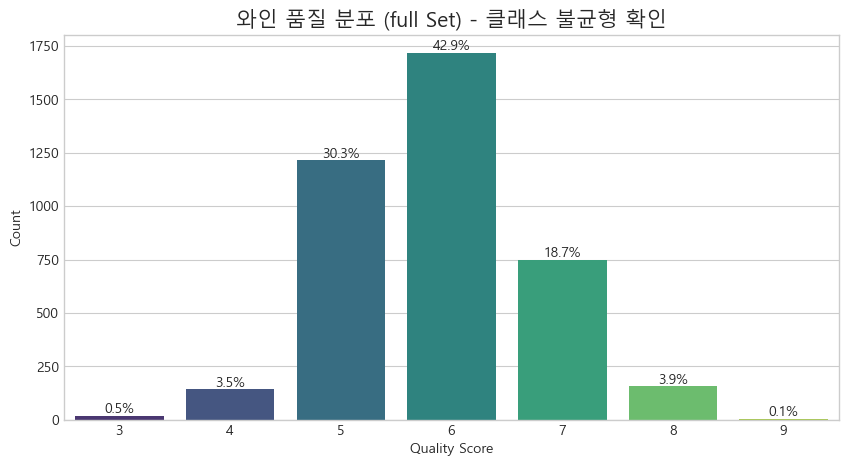

In [ ]:
plot_target_distribution(y_eda, 
                         title="와인 품질 분포 (full Set)", 
                         xlabel="Quality Score")

### 결과 분석 및 결론

* **결과 분석:**
    * **중간 등급 집중 현상:** 시각화 결과, 품질 점수 **6점(42.9%)**과 **5점(30.3%)**이 전체 데이터의 약 **73.2%**를 차지하며 압도적으로 높은 비중을 보입니다.
    * **양극단 데이터 희소성:** 반면, 품질이 매우 낮은 **3점(0.5%), 4점(3.5%)**과 매우 높은 **8점(3.9%), 9점(0.1%)**은 데이터가 매우 부족한 희소 클래스(Minority Class)임이 확인됩니다.

* **결론:**
    * **심각한 클래스 불균형(Class Imbalance):** 데이터가 중간값에 편중되어 있어, 이대로 학습을 진행할 경우 모델이 다수 클래스(5, 6점) 위주로 편향되어 학습될 가능성이 매우 높습니다.
    * **대응 전략 필요:** 소수 클래스의 예측 성능을 높이기 위해 **SMOTE**와 같은 오버샘플링 기법을 적용하거나, 타겟 변수를 단순화(예: Low, Medium, High 3단계로 그룹화)하는 **Binning** 전략을 고려해야 합니다.

### 2.3 변수 분포 확인(`KDE plot`)

### 독립 변수(Features) 분포 확인

* **목표:** 데이터셋에 포함된 모든 수치형 독립 변수들의 데이터 분포 양상을 시각화하여, 정규분포 여부와 데이터의 치우침(Skewness), 그리고 잠재적인 이상치(Outlier) 존재 가능성을 파악합니다.
* **사용 기법의 목적:** `Seaborn`의 히스토그램과 KDE(Kernel Density Estimation, 커널 밀도 추정)를 함께 그려 데이터의 빈도와 확률 밀도를 동시에 확인합니다.
* **기법의 원리:** 전체 데이터를 구간(Bin)으로 나누어 막대그래프로 표시하고, 그 위에 가우시안 커널 등을 이용해 데이터를 부드러운 곡선으로 연결함으로써 모집단의 분포를 추정합니다.
* **예상 결과:** `pH`나 `density`처럼 정규분포에 가까운 변수와, `residual sugar`처럼 한쪽으로 꼬리가 긴(Long-tail) 변수를 구분할 수 있으며, 이를 통해 스케일링(Scaling) 및 변환(Transformation) 전략을 수립할 수 있습니다.

총 11개의 수치형 피처 분포를 생성합니다.


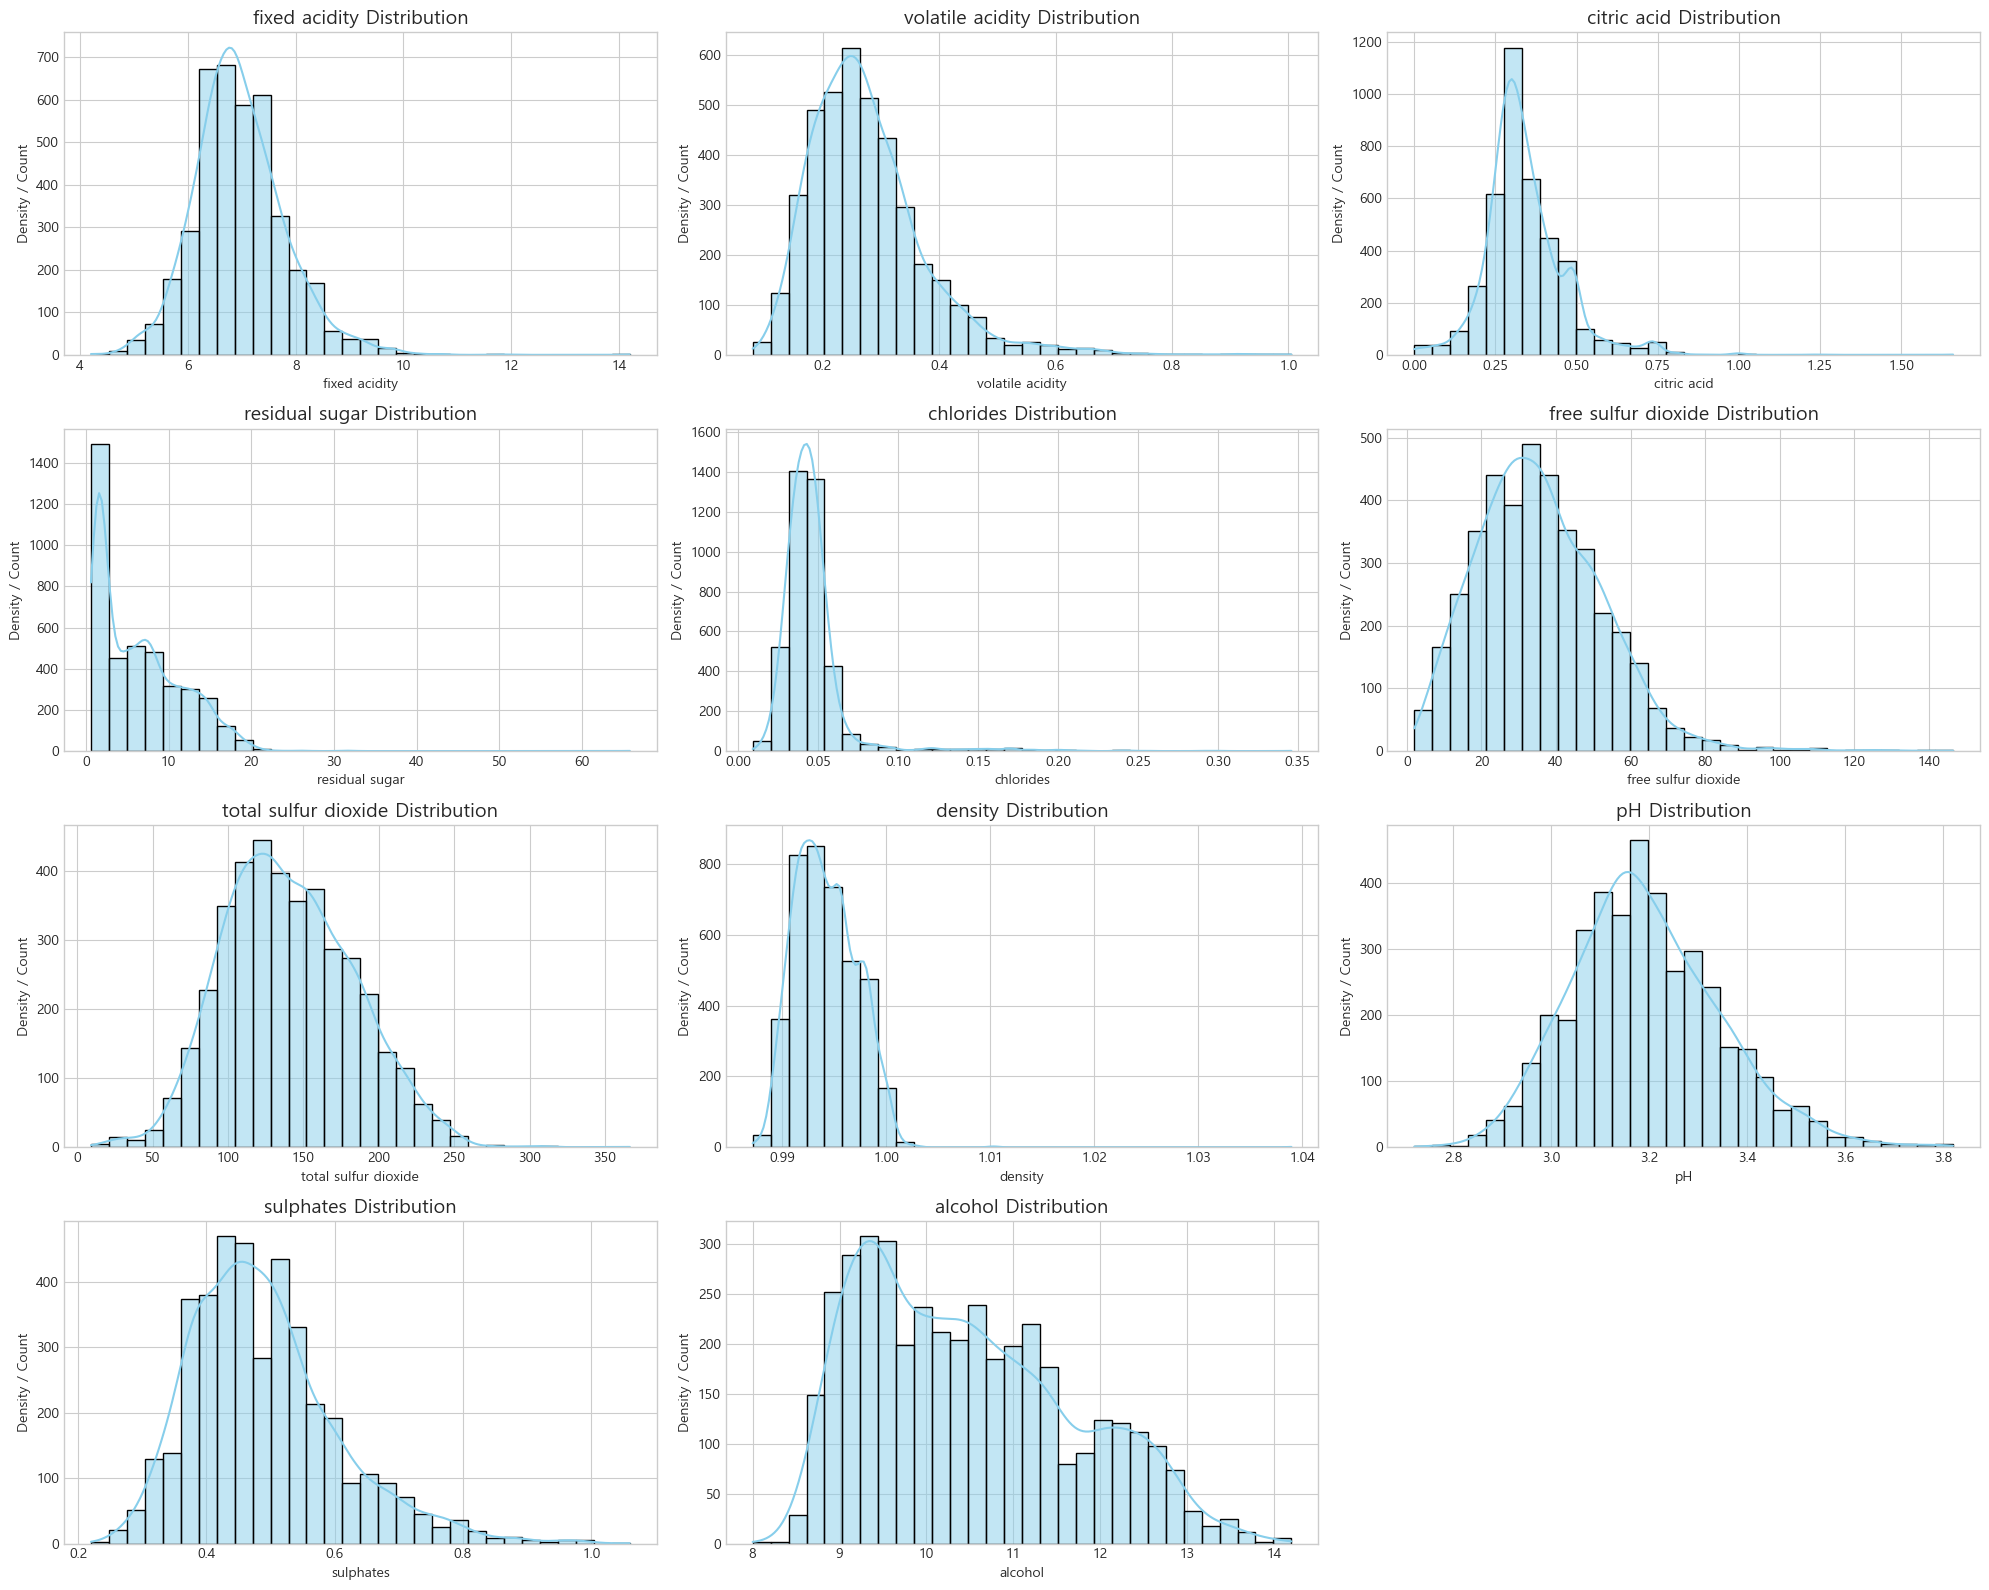

In [ ]:
plot_numerical_distribution(X_eda)

### 결과 분석 및 결론

* **결과 분석:**
    * **오른쪽으로 긴 꼬리(Right-skewed):** `residual sugar`, `chlorides`, `sulphates`, `free sulfur dioxide`, `total sulfur dioxide` 등 다수의 변수가 왼쪽(낮은 값)에 데이터가 밀집되어 있고 오른쪽으로 길게 꼬리가 늘어지는 양의 왜도(Positive Skewness)를 보입니다. 특히 `residual sugar`와 `chlorides`는 그 정도가 매우 심합니다.
    * **정규분포 유사:** `pH`, `density`, `fixed acidity`는 비교적 종 모양(Bell-shape)의 정규분포에 가까운 형태를 보입니다.
    * **특이점:** `citric acid`는 0 값 근처에 데이터가 많고 다봉(Multi-modal) 형태에 가까운 불규칙한 분포를 보입니다.

* **결론:**
    * **전처리 필요성 확인:** 다수의 변수가 정규분포를 따르지 않으므로, 선형 회귀와 같이 정규성 가정이 중요한 모델을 사용할 경우 **로그 변환(Log Transformation)**이나 **Box-Cox 변환**을 통해 분포를 정규분포에 가깝게 맞춰주는 과정이 성능 향상에 도움이 될 것입니다.
    * **스케일링 전략:** 변수마다 값의 범위(Scale)가 다르므로(예: `total sulfur dioxide`는 수백 단위, `chlorides`는 0.1 단위), 모든 변수를 동일한 범위로 조정하는 **StandardScaler** 또는 이상치에 강건한 **RobustScaler** 적용이 필요합니다.

### 2.4 변수 간 관계 탐색(correlation heatmap)

### 변수 간 상관관계 분석 및 다중공선성 진단

* **목표:** 독립 변수(Feature)들 간의 선형적 관계를 파악하여 **다중공선성(Multicollinearity)** 문제를 사전에 감지하고, 타겟 변수(`quality`)와 가장 관련성이 높은 핵심 변수를 선별합니다.
* **사용 기법의 목적:**
    1. **Correlation Heatmap:** 변수 간의 피어슨 상관계수($r$)를 히트맵으로 시각화하여 변수 간의 강한 연관성을 색상으로 표현합니다.
    2. **Target Correlation Bar Plot:** 타겟 변수(`quality`)와 각 독립 변수 간의 상관계수 크기를 순서대로 정렬하여 시각화합니다.
* **기법의 원리:** 상관계수는 $-1$에서 $1$ 사이의 값을 가지며, 절댓값이 $1$에 가까울수록 강한 선형 관계를, $0$에 가까울수록 관계가 없음을 의미합니다.
* **예상 결과:**
    * 서로 강한 상관관계를 가진 독립 변수 쌍(예: $r > 0.7$)을 발견하여 중복 정보를 가진 변수를 식별할 수 있습니다.
    * 와인 품질 결정에 긍정적/부정적 영향을 미치는 주요 인자를 파악할 수 있습니다.

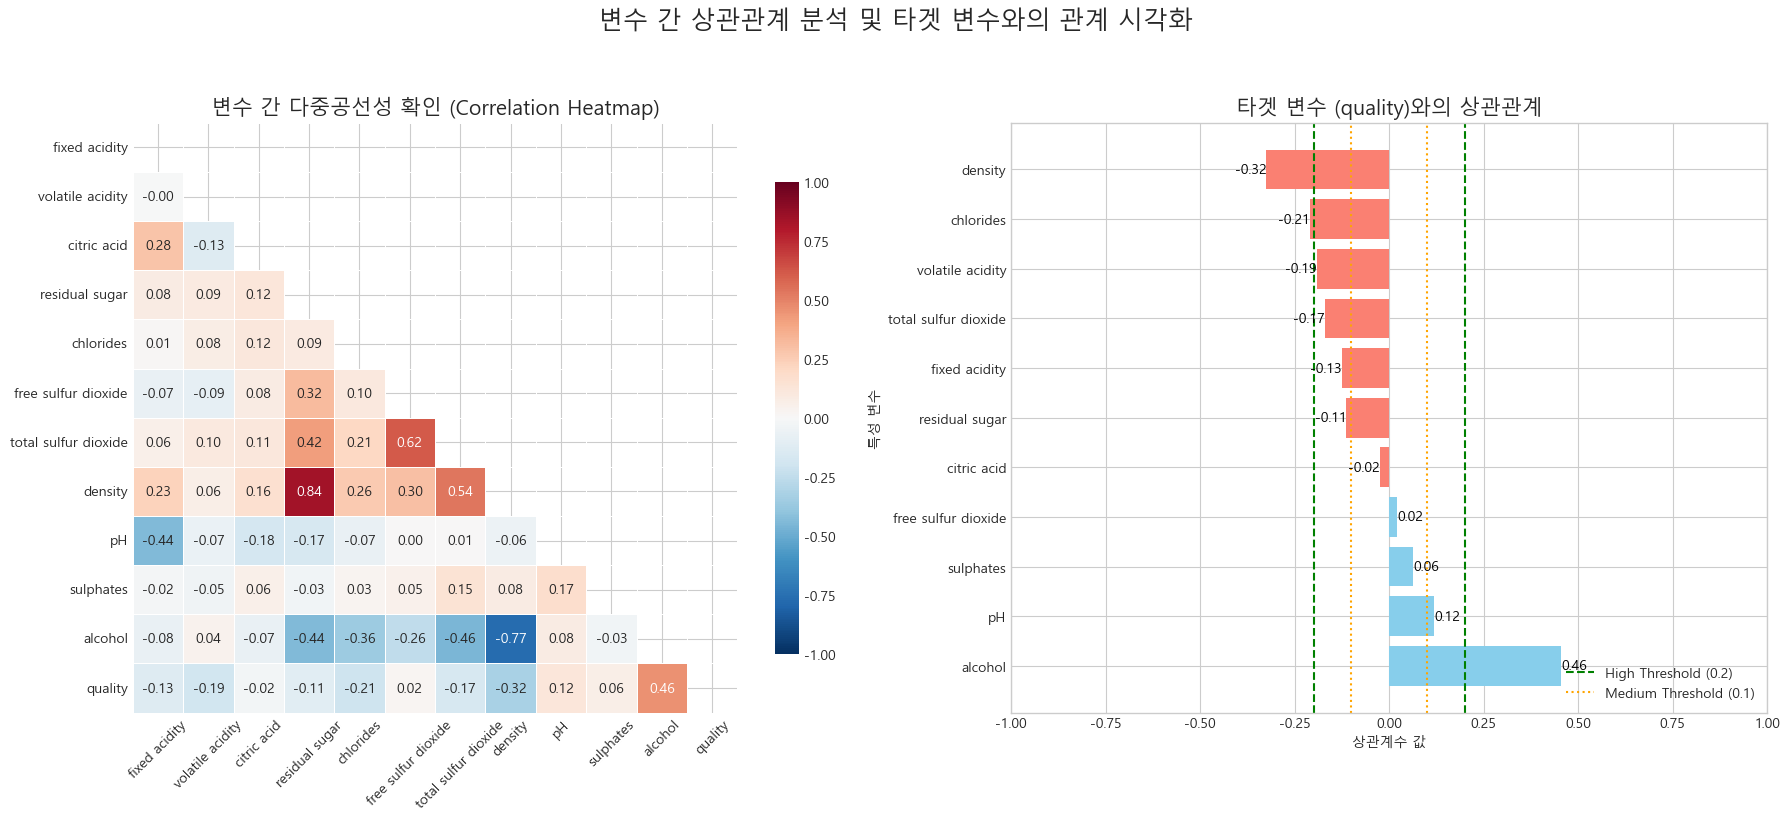


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): ['alcohol', 'chlorides', 'density']
Medium correlation features with quality (0.1 < |r| <= 0.2): ['pH', 'residual sugar', 'fixed acidity', 'total sulfur dioxide', 'volatile acidity']
Low correlation features with quality (<= 0.1): ['sulphates', 'free sulfur dioxide', 'citric acid']

선택된 상관관계 변수 딕셔너리 (High + Medium, Abs Value):
{'alcohol': np.float64(0.45519495928220133), 'density': np.float64(0.32465025139356724), 'chlorides': np.float64(0.20955653962744716), 'volatile acidity': np.float64(0.19142436790265446), 'total sulfur dioxide': np.float64(0.17063878019225792), 'fixed acidity': np.float64(0.12600591640659528), 'pH': np.float64(0.11915172512134131), 'residual sugar': np.float64(0.11320294127528961)}
상관관계가 높은 피처:8개 {'alcohol': np.float64(0.45519495928220133), 'density': np.float64(0.32465025139356724), 'chlorides': np.float64(0.20955653962744716), 'volatile acidity': np.float64(0.19142436790265446), 'total sulf

In [ ]:
selected_corr_features = visualize_and_classify_correlation(X_eda, y_eda, 
                                                       target_name='quality', 
                                                       high_threshold=0.2, 
                                                       medium_threshold=0.1)

print(f"상관관계가 높은 피처:{len(selected_corr_features)}개 {selected_corr_features}")

### 결과 분석 및 결론

* **결과 분석:**
    * **다중공선성 경고 (Heatmap):**
        * **`density`와 `residual sugar`:** 상관계수가 **0.84**로 매우 강한 양의 상관관계를 보입니다. 이는 잔류 설탕량이 많을수록 와인의 밀도가 높아진다는 물리적 특성을 반영하지만, 통계적으로는 두 변수가 거의 같은 정보를 담고 있음을 의미합니다.
        * **`density`와 `alcohol`:** 상관계수가 **-0.77**로 강한 음의 상관관계를 보입니다. 알코올 도수가 높을수록 밀도가 낮아지는 경향이 뚜렷합니다.
    * **타겟 변수 중요도 (Bar Chart):**
        * **`alcohol` (0.46):** 와인 품질과 가장 높은 양의 상관관계를 가집니다. 즉, 알코올 도수가 높을수록 품질 평가가 좋은 경향이 있습니다.
        * **`density` (-0.32) & `chlorides` (-0.21):** 품질과 음의 상관관계를 보이며, 특히 밀도가 높거나 염화물 수치가 높으면 품질이 낮아지는 경향이 있습니다.

* **결론:**
    * **변수 선택(Feature Selection) 제안:** `density` 변수는 `residual sugar` 및 `alcohol`과 지나치게 높은 상관관계를 가지므로, 회귀 모델의 불안정성을 초래할 수 있는 **다중공선성**의 주원인입니다. 모델 학습 시 `density` 변수를 **제거**(**Drop**)하는 것이 모델의 일반화 성능에 도움이 될 것으로 판단됩니다.
    * **핵심 변수:** 모델링 시 `alcohol` 변수가 가장 중요한 예측 요인이 될 것이며, 상관계수가 0에 가까운 `citric acid`, `free sulfur dioxide` 등은 노이즈로 작용할 가능성이 있으므로 제거를 고려해볼 만합니다.

### 다중공선성(Multicollinearity) 정량적 진단: VIF 분석

* **목표:** 앞선 상관관계 히트맵(Heatmap)에서 발견된 변수 간의 강한 연관성을 수치(`VIF Score`)로 정량화하여, 실제로 모델 학습에 해를 끼칠 정도의 심각한 다중공선성이 존재하는지 확인합니다.
* **사용 기법의 목적:** **VIF**(**Variance Inflation Factor**)를 계산하여 특정 독립 변수가 다른 독립 변수들에 의해 얼마나 설명되는지 측정합니다.
* **기법의 원리:** $VIF_i = \frac{1}{1 - R_i^2}$ 공식을 따릅니다. 여기서 $R_i^2$는 $i$번째 변수를 종속 변수로, 나머지 변수들을 독립 변수로 하여 회귀 분석을 했을 때의 결정 계수입니다.
    * 통상적으로 **VIF > 10**이면 다중공선성이 존재한다고 판단하며, **VIF > 10**이면 매우 심각한 상태로 간주합니다.
* **예상 결과:** 상관관계가 높았던 `density`와 `alcohol` 등의 변수들이 높은 VIF 값을 보일 것으로 예상되며, 이를 통해 제거해야 할 변수의 우선순위를 정할 수 있습니다.


VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features          VIF
0                density  1063.437876
1                     pH   602.446409
2                alcohol   118.318156
3          fixed acidity    95.565662
4   total sulfur dioxide    25.023359
5              sulphates    20.513450
6            citric acid    10.123976
7       volatile acidity     9.678009
8    free sulfur dioxide     9.523727
9              chlorides     6.397235
10        residual sugar     3.803833


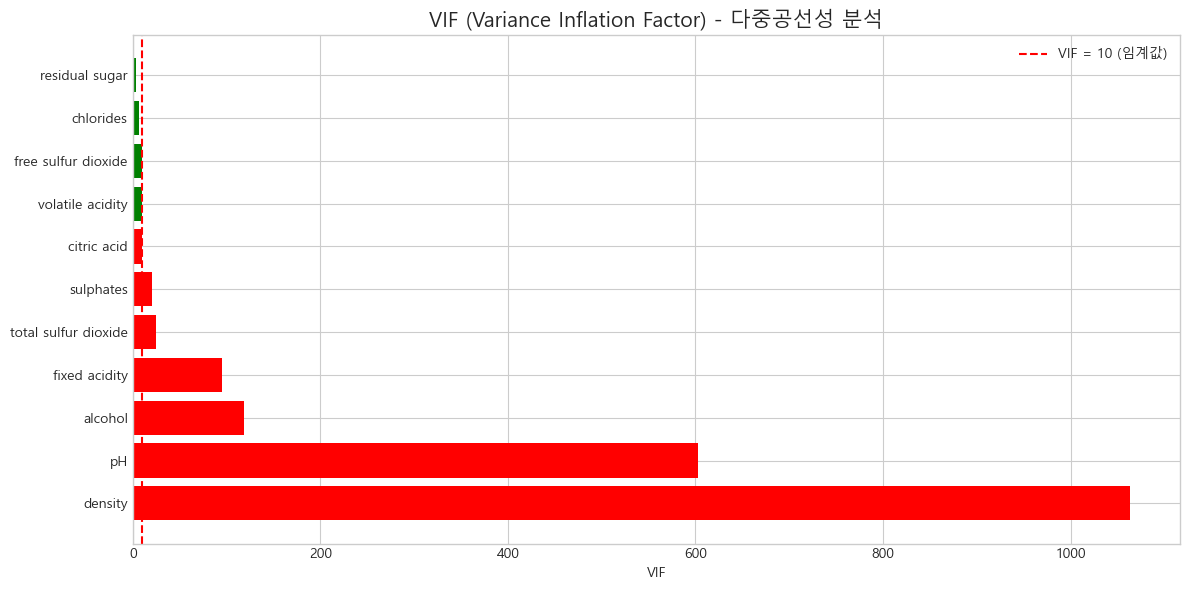


VIF < 10인 피처 (4개): ['volatile acidity', 'free sulfur dioxide', 'chlorides', 'residual sugar']

VIF >= 10인 피처 (7개): ['density', 'pH', 'alcohol', 'fixed acidity', 'total sulfur dioxide', 'sulphates', 'citric acid']


In [ ]:
selected_vif_features, selected_vif_not_features = run_vif_analysis(X_eda)

### 결과 분석 및 변수 제거 제안

* **결과 분석:**
    * **심각한 공선성 발견:** 시각화 결과, **`density`** (**VIF > 1000**)와 **`pH`** (**VIF ≈ 600**)가 기준치인 10을 훨씬 초과하는 비정상적인 값을 보입니다.
    * **연쇄적 영향:** `alcohol`과 `fixed acidity` 역시 VIF가 100 근처로 높게 나타났으나, 이는 가장 높은 VIF를 가진 변수(`density`)와의 상관성 때문일 가능성이 큽니다.
    * **안전한 변수:** 반면 `residual sugar`, `chlorides`, `free sulfur dioxide` 등은 VIF가 10 미만(초록색)으로 나타나 독립적인 정보를 갖고 있음이 확인되었습니다.

* **결론 및 대응 전략:**
    * **변수 제거 (Feature Dropping):** `density` 변수는 다른 변수들(알코올, 당도 등)의 조합으로 거의 완벽하게 설명되므로 정보의 중복이 매우 심각합니다. 모델의 과적합 방지와 해석의 용이성을 위해 **`density`를 최우선으로 제거**해야 합니다.
    * **단계적 접근:** VIF가 높은 변수를 한꺼번에 모두 제거하는 것은 위험합니다. 가장 높은 `density` 하나를 제거한 후 VIF를 **재산출**하면, 연관되어 있던 `alcohol`이나 `pH`의 VIF 수치가 자연스럽게 정상 범위로 떨어질 가능성이 높습니다.

### 2.5 이상치 탐색(`Boxplot`) -> 이상치 탐색이 필요함 확인

### 이상치(Outlier) 탐색 및 변수별 분포 차이 시각화

* **목표:** 각 독립 변수 내에 존재하는 **이상치(Outlier)**를 식별하고, 타겟 변수인 와인 품질(`quality`) 등급에 따라 독립 변수들의 중앙값(Median)과 분포 범위가 어떻게 달라지는지 파악합니다.
* **사용 기법의 목적:** `Seaborn`의 **Boxplot**을 사용하여 데이터의 요약 통계량(최소, 최대, 사분위수)을 시각적으로 표현합니다.
* **기법의 원리:**
    * **박스(Box):** 데이터의 하위 25%($Q1$)에서 상위 25%($Q3$)까지의 범위(IQR)를 나타냅니다.
    * **중앙선(Line):** 데이터의 중앙값(Median)입니다.
    * **수염(Whisker):** 박스 외부로 $1.5 \times IQR$ 범위 내의 데이터를 연결합니다.
    * **점(Point):** 수염 범위를 벗어나는 데이터로, 통계적으로 **이상치**로 간주합니다.
* **예상 결과:** `residual sugar`나 `sulfur dioxide` 등 변동성이 큰 변수에서 다수의 이상치가 발견될 것으로 예상되며, 품질이 좋은 와인일수록 특정 성분(예: 알코올)의 수치가 높아지거나 낮아지는 경향성을 박스의 높낮이로 확인할 수 있습니다.

총 11개의 피처에 대해 Quality별 Boxplot을 생성합니다.


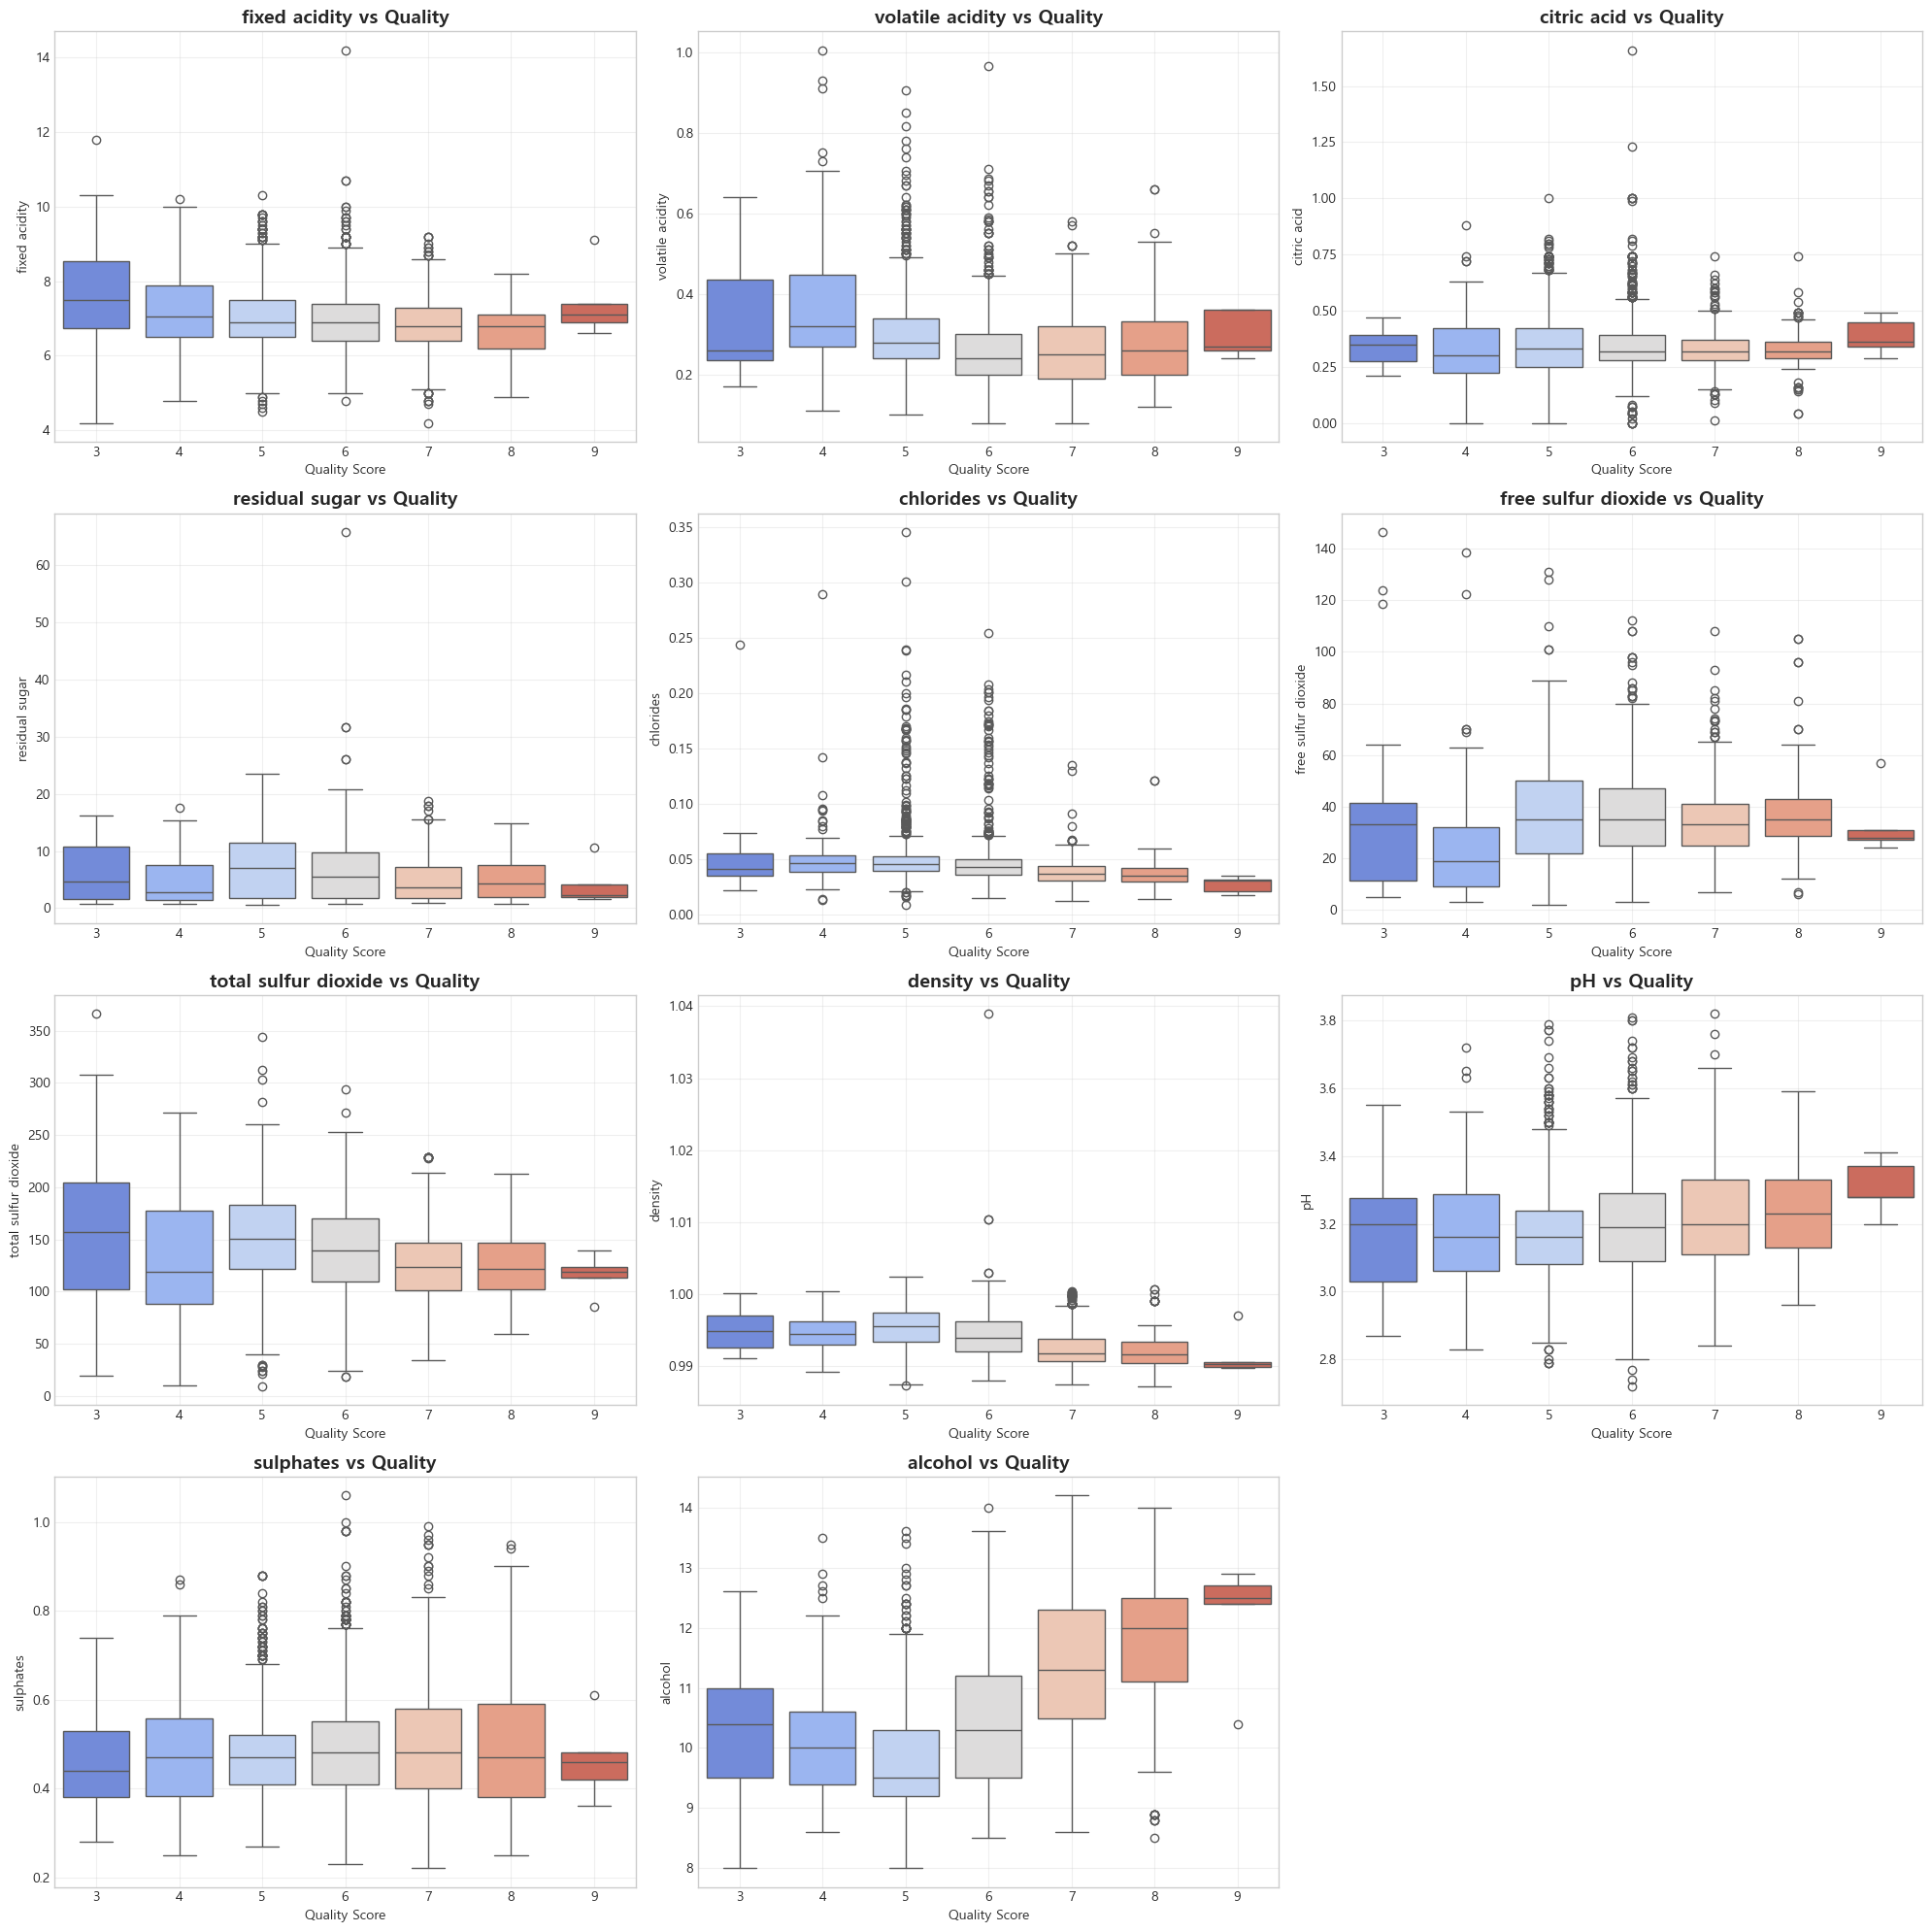

In [ ]:
plot_feature_quality_boxplots(X_eda, y_eda)

### 결과 분석 및 결론

* **결과 분석:**
    * **심각한 이상치 존재:** 대부분의 변수에서 검은색 원(Outlier)이 다수 발견되었습니다.
        * 특히 **`residual sugar`, `chlorides`, `total sulfur dioxide`, `free sulfur dioxide`** 변수에서 박스 범위를 크게 벗어나는 극단적인 값들이 매우 많이 관측됩니다.
        * 이는 와인의 종류(스위트 와인 vs 드라이 와인 등)에 따른 자연스러운 특성일 수도 있으나, 모델 학습 시 노이즈로 작용할 가능성이 큽니다.
    * **품질별 트렌드 확인:**
        * **`alcohol`:** 품질 등급(x축)이 올라갈수록 박스의 위치(y축)가 **뚜렷하게 상승**하는 경향을 보입니다. 이는 알코올 도수가 와인 품질 결정에 중요한 요소임을 다시 한번 입증합니다.
        * **`density`:** 품질이 높아질수록 밀도가 낮아지는 약한 하향 추세를 보입니다.
    * **분산의 차이:** 품질이 9점인 등급(가장 우측)은 데이터 개수가 적어 박스의 모양이 납작하거나 수염이 짧게 나타나는 등 다른 등급과 분포 형태가 다릅니다.
    * **Key Predictors (핵심 변수):**
        * **alcohol:** 강한 양의 관계 (품질이 오를수록 뚜렷하게 상승)
        * **volatile acidity:** 강한 음의 관계 (품질이 오를수록 뚜렷하게 하락)
        * **density:** 뚜렷한 음의 관계 (품질 상승에 따라 계단식으로 하락)
        * **sulphates:** 양의 관계 (고품질로 갈수록 완만하게 상승)
    * **Secondary/Weak Predictors (보조/약한 변수):**
        * **citric acid:** 약한 양의 관계 (중간~고품질에서 소폭 상승)
        * **chlorides:** 약한 음의 관계 (고품질에서 수치가 낮고 일정해짐)
        * **free sulfur dioxide:** 뒤집힌 U자형 (중간 품질에서 높고 양극단에서 낮음)
        * **total sulfur dioxide:** 비선형/감소 (중간 품질 이후 고품질로 갈수록 감소)
    * **Low Predictive Value (예측력 낮음):**
        * **fixed acidity:** 관계 미미함 (변화가 거의 없음)
        * **residual sugar:** 관계 없음 (모든 등급에서 중앙값이 비슷함)
        * **pH:** 관계 없음 (박스 높낮이의 유의미한 차이 식별 불가)
* **결론:**
    * **이상치 처리 필수:** `Mean`(평균)이나 `Variance`(분산) 기반의 스케일러(StandardScaler)를 바로 사용하기에는 이상치의 영향이 너무 큽니다.
    * **대응 전략:**
        1. 중앙값과 IQR을 사용하여 이상치에 강건한 **RobustScaler**를 적용하는 것이 가장 적합해 보입니다.
        2. 혹은 극단적인 상위 1% 데이터를 제거하거나 경계값으로 대체하는 **Winsorization** 기법 적용을 고려해야 합니다.
        3. 핵심변수, 보조/약한 변수를 학습에 사용하고, 예측력 낮은 변수는 사용하지 않음을 고려해야 합니다.

### 3. 데이터 분리

### 데이터 정제: 중복 데이터(Duplicate Data) 제거

* **목표:** 데이터셋 내에 완전히 동일한 값을 가진 행(Row)이 존재하는지 확인하고 이를 제거하여 데이터의 유일성(Uniqueness)을 확보합니다.
* **사용 기법의 목적:** Pandas의 `drop_duplicates()` 기능을 사용하여 중복된 샘플을 삭제합니다.
* **기법의 원리:** 모든 컬럼의 값이 완벽하게 일치하는 행들을 식별한 뒤, 첫 번째로 발견된 행만 남기고 나머지 중복 행들은 메모리에서 소거합니다.
* **예상 결과:**
    * 중복 데이터가 모델 학습 과정에 참여할 경우 발생할 수 있는 **과적합(Overfitting)** 및 **평가 편향(Bias)**을 방지합니다.
    * 전체 데이터 개수는 줄어들지만, 데이터의 순도와 신뢰도는 향상될 것입니다.

In [ ]:
# 1. 중복 데이터가 얼마나 있는지 확인
duplicate_count = df_full.duplicated().sum()
print(f"제거 전 데이터 개수: {len(df_full)}")
print(f"발견된 중복 데이터 개수: {duplicate_count}")

# 2. 중복 데이터 제거 (keep='first'는 첫 번째 것만 남기고 뒤에 나오는 중복은 지운다는 뜻)
if duplicate_count > 0:
    df_drop_duplicates = df_full.drop_duplicates(keep='first')
    
    # 인덱스가 꼬이지 않게 재정렬 (중요!)
    df_drop_duplicates = df_drop_duplicates.reset_index(drop=True)
    print("중복 제거 완료!")
else:
    print("중복 데이터가 없습니다.")

target = 'quality'
X_drop_duplicates = df_drop_duplicates.drop(target, axis=1)
y_drop_duplicates = df_drop_duplicates[target]
print(f"제거 후 데이터 개수: {len(df_drop_duplicates)}")

제거 전 데이터 개수: 4001
발견된 중복 데이터 개수: 768
중복 제거 완료!
제거 후 데이터 개수: 3233


### 결과 분석 및 결론

* **결과 분석:**
    * **높은 중복 비율:** 전체 데이터 4,001개 중 약 **19.2%**에 해당하는 **768개**의 데이터가 중복임이 확인되었습니다.
    * **정제 완료:** 중복 데이터를 모두 제거한 후, 최종적으로 **3,233개**의 고유한(Unique) 샘플이 남았습니다.

* **결론:**
    * **데이터 누수 방지:** 약 20%에 달하는 중복 데이터는 추후 학습셋(Train)과 테스트셋(Test) 분리 시 양쪽에 동일한 데이터가 들어가는 **데이터 누수(Data Leakage)** 문제를 일으킬 소지가 매우 컸습니다.
    * **모델 신뢰성 확보:** 이번 전처리를 통해 모델이 특정 패턴을 단순히 암기하는 것을 막고, 보다 일반화된 성능을 낼 수 있는 기반이 마련되었습니다.

### 3.1 StratifiedKFold 로 train / test 분리

### 학습/테스트 데이터 분리: 층화 추출 (Stratified Split) 적용

* **목표:** 전체 데이터를 모델 학습용(Train)과 성능 평가용(Test)으로 나누되, 원본 데이터가 가진 **타겟 변수(`quality`)의 클래스 비율을 그대로 유지**합니다.
* **사용 기법의 목적:** `StratifiedKFold` (또는 `stratify` 옵션)를 사용하여 데이터 분할 시 각 클래스의 분포를 균등하게 배분합니다.
* **기법의 원리:** 전체 데이터에서 각 클래스(3~9점)가 차지하는 비율을 계산한 뒤, 이 비율에 맞춰 Train셋과 Test셋에 샘플을 무작위로 할당합니다.
* **예상 결과:**
    * 품질 3점이나 9점과 같이 샘플 수가 매우 적은 **희소 클래스(Minority Class)**가 운 나쁘게 Test셋에만 몰리거나 Train셋에서 아예 배제되는 문제를 방지할 수 있습니다.
    * 학습 데이터와 테스트 데이터가 통계적으로 동일한 성격을 띠게 되어 신뢰성 있는 평가가 가능해집니다.

훈련 데이터의 X의 크기: (2586, 11) 훈련 데이터의 y의 크기: (2586,)
테스트 데이터의 X의 크기: (647, 11) 테스트 데이터의 y의 크기: (647,)
전체 비율:
 quality
6    0.429393
5    0.303424
7    0.186703
8    0.038990
4    0.035491
3    0.004749
9    0.001250
Name: proportion, dtype: float64
Low class percentages:  8.04798800299925
High class percentages:  91.95201199700075
Imbalance Ratio (IR): (다수 클래스 수(3)) / (소수 클래스 수(4)): 91.95201199700075 / 8.04798800299925


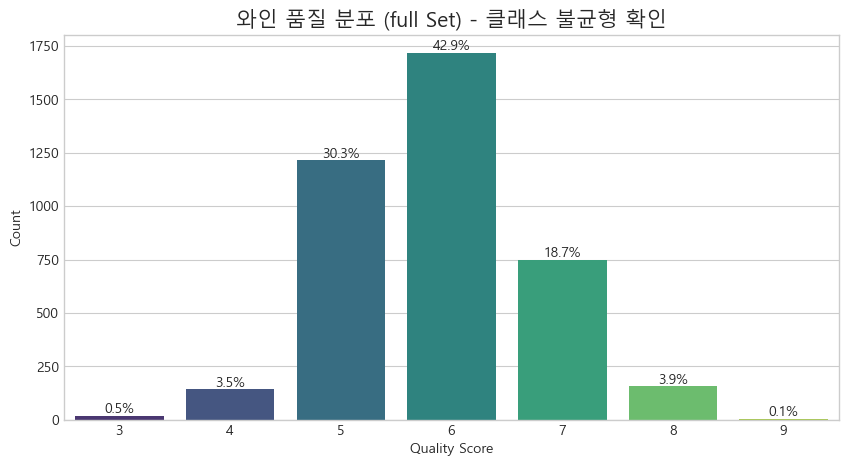

Train 비율:
 quality
6    0.429234
5    0.304331
7    0.180974
4    0.041377
8    0.036736
3    0.005800
9    0.001547
Name: proportion, dtype: float64
Low class percentages:  8.546017014694508
High class percentages:  91.4539829853055
Imbalance Ratio (IR): (다수 클래스 수(3)) / (소수 클래스 수(4)): 91.4539829853055 / 8.546017014694508


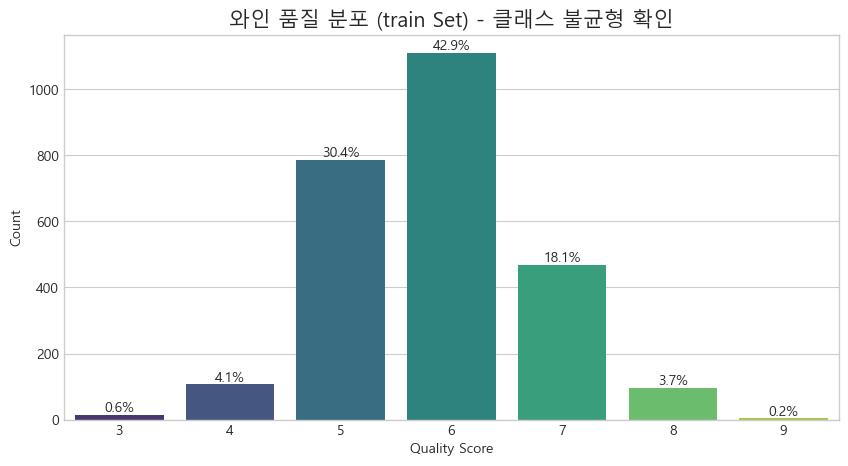

Test 비율:
 quality
6    0.428130
5    0.304482
7    0.180835
4    0.041731
8    0.037094
3    0.006182
9    0.001546
Name: proportion, dtype: float64
Low class percentages:  8.655332302936632
High class percentages:  91.34466769706336
Imbalance Ratio (IR): (다수 클래스 수(3)) / (소수 클래스 수(4)): 91.34466769706336 / 8.655332302936632


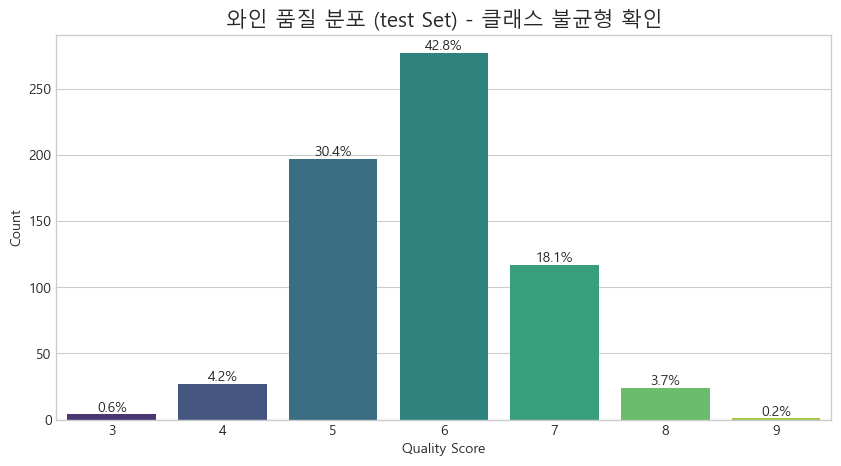

In [ ]:
# X: 피처 데이터, y: 타겟(와인 품질)
X_train, X_test, y_train, y_test = train_test_split(
    X_drop_duplicates, 
    y_drop_duplicates, 
    test_size=0.2,       # 테스트 데이터 비율 (20%)
    random_state=SEED,   # 결과를 똑같이 재현하기 위한 시드값
    stratify=y_drop_duplicates       # <--- [핵심] y(품질)의 비율을 유지하며 나눠라!
)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)
print(f"훈련 데이터의 X의 크기: {X_train.shape} 훈련 데이터의 y의 크기: {y_train.shape}")
print(f"테스트 데이터의 X의 크기: {X_test.shape} 테스트 데이터의 y의 크기: {y_test.shape}")
# 원본 데이터의 비율
print("전체 비율:\n", y_eda.value_counts(normalize=True))
plot_target_distribution(y_eda, 
                         title="와인 품질 분포 (full Set)", 
                         xlabel="Quality Score")
# 학습 데이터의 비율
print("Train 비율:\n", y_train.value_counts(normalize=True))
plot_target_distribution(y_train, 
                         title="와인 품질 분포 (train Set)", 
                         xlabel="Quality Score")
# 테스트 데이터의 비율
print("Test 비율:\n", y_test.value_counts(normalize=True))
plot_target_distribution(y_test, 
                         title="와인 품질 분포 (test Set)", 
                         xlabel="Quality Score")




### 결과 분석 및 결론

* **결과 분석:**
    * **데이터 규모:** 전체 3,233개 데이터가 학습용 **2,586개(약 80%)**와 테스트용 **647개(약 20%)**로 적절하게 분할되었습니다.
    * **비율 보존 확인:**
        * **다수 클래스:** 가장 비중이 큰 6점(약 42.9%)과 5점(약 30.4%)의 비율이 Train과 Test 셋 모두에서 원본(Overall)과 거의 오차 없이 일치합니다.
        * **소수 클래스:** 데이터가 극히 적은 **9점(0.1%)**과 **3점(0.5~0.6%)** 또한 Train과 Test 양쪽에 골고루 안배되었습니다.

* **결론:**
    * **성공적인 분할:** 클래스 불균형이 심한 데이터셋임에도 불구하고, 층화 추출을 통해 **모든 클래스가 학습 및 평가 단계에 포함**되도록 안전하게 분리되었습니다.
    * **모델링 준비 완료:** 이제 데이터의 분포가 동일하게 맞춰진 상태이므로, 과적합이나 평가 편향(Bias)의 우려를 덜고 본격적인 모델 학습(또는 스케일링)을 진행할 수 있습니다.

### 4. 이상치(Outlier) 탐지 및 처리 전략 비교

### 이상치(Outlier) 탐지 및 제거: IQR vs Isolation Forest

* **목표:** 학습 데이터(Train Set) 내에 존재하는 이상치를 식별하고 제거하여, 모델이 노이즈나 극단값에 과도하게 영향을 받는 것을 방지합니다. 두 가지 다른 방식(통계적 기법 vs 머신러닝 기법)을 적용해 보고 결과를 비교합니다.
* **사용 기법 및 원리:**
    1.  **IQR (Interquartile Range) 방식:**
        * **원리:** 데이터의 제 1사분위수($Q1$)와 제 3사분위수($Q3$) 사이의 범위($IQR$)를 이용해 $Q1 - 1.5 \times IQR$ 미만이거나 $Q3 + 1.5 \times IQR$ 초과인 값을 이상치로 간주합니다.
        * **조건:** 단일 변수만 벗어난 경우를 제외하기 위해 **'2개 이상의 변수에서 이상치로 판별된 경우'**만 삭제하도록 조건을 강화하여 적용합니다.
    2.  **Isolation Forest (IF) 방식:**
        * **원리:** 의사결정나무(Decision Tree) 기반의 비지도 학습 알고리즘입니다. 데이터가 드문 영역(고립된 점)일수록 적은 횟수의 분할만으로도 분리된다는 점을 이용해, 분리 경로가 짧은 데이터를 이상치로 판단합니다. 다변량(Multivariate) 관계를 고려할 수 있다는 장점이 있습니다.
* **예상 결과:** 분포가 치우친(Skewed) 변수가 많은 데이터 특성상, IQR 방식은 다소 많은 데이터를 이상치로 잡을 가능성이 있으며, Isolation Forest는 전체 데이터의 패턴을 고려해 보다 적은 수의 핵심 이상치만 선별할 것으로 예상됩니다.

In [ ]:
# 실험 진행
outliers_iqr = detect_outliers_iqr(X_train)
outliers_if = detect_outliers_if(X_train)

print(f"\n총 데이터 개수: {len(X_train)}")
print(f"IQR 방식 (2개 이상 변수 이상치) 제거 대상 개수: {len(outliers_iqr)}")
print(f"Isolation Forest(IF) 방식 제거 대상 개수: {len(outliers_if)}")

# 최종 결정: Isolation Forest 적용 (다변량 관계 고려)
# 1. 마스크 생성 (모든 행을 True로 초기화)
# 단, Train 데이터에서만 제거해야 함!
mask = np.ones(len(X_train), dtype=bool)
# 2. 함수 호출 및 위치 인덱스를 사용하여 마스크 업데이트 (False로 설정)
mask[detect_outliers_iqr(X_train)] = False 

# 3. 이상치 제거된 데이터셋 생성
X_train_clean_iqr = X_train[mask]
y_train_clean_iqr = y_train[mask]

mask = np.ones(len(X_train), dtype=bool)
mask[detect_outliers_if(X_train)] = False # Isolation Forest 결과를 적용
X_train_clean_if = X_train[mask]
y_train_clean_if = y_train[mask]

# 결과 출력
print(f"IQR: 이상치 제거 후 Train Set 크기: {X_train_clean_iqr.shape} (삭제된 행: {len(X_train) - len(X_train_clean_iqr)})({(len(X_train) - len(X_train_clean_iqr)) / len(X_train) * 100:.2f}%)")
print(f"IQR: 제거 후 데이터 개수 (X_train_clean): {len(X_train_clean_iqr)}  제거 후 데이터 개수 (y_train_clean): {len(y_train_clean_iqr)}")

print(f"IF: 이상치 제거 후 Train Set 크기: {X_train_clean_if.shape} (삭제된 행: {len(X_train) - len(X_train_clean_if)})({(len(X_train) - len(X_train_clean_if)) / len(X_train) * 100:.2f}%)")
print(f"IF: 제거 후 데이터 개수 (X_train_clean): {len(X_train_clean_if)}  제거 후 데이터 개수 (y_train_clean): {len(y_train_clean_if)}")

=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar          -9.050000    19.350000
chlorides                0.015000     0.071000
free sulfur dioxide    -11.500000    80.500000
total sulfur dioxide    15.000000   263.000000
density                  0.985699     1.001969
pH                       2.796250     3.586250
sulphates                0.200000     0.760000
alcohol                  6.800000    14.000000


2025/12/20 20:25:22 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '58a0334a61ca49e4a8a3af276a35eb08', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/12/20 20:25:26 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/12/20 20:25:26 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f65a6ab6e3054a3b9260aa88b9b8036c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow



총 데이터 개수: 2586
IQR 방식 (2개 이상 변수 이상치) 제거 대상 개수: 483
Isolation Forest(IF) 방식 제거 대상 개수: 130
=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar          -9.050000    19.350000
chlorides                0.015000     0.071000
free sulfur dioxide    -11.500000    80.500000
total sulfur dioxide    15.000000   263.000000
density                  0.985699     1.001969
pH                       2.796250     3.586250
sulphates                0.200000     0.760000
alcohol                  6.800000    14.000000


2025/12/20 20:25:29 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


IQR: 이상치 제거 후 Train Set 크기: (2103, 11) (삭제된 행: 483)(18.68%)
IQR: 제거 후 데이터 개수 (X_train_clean): 2103  제거 후 데이터 개수 (y_train_clean): 2103
IF: 이상치 제거 후 Train Set 크기: (2456, 11) (삭제된 행: 130)(5.03%)
IF: 제거 후 데이터 개수 (X_train_clean): 2456  제거 후 데이터 개수 (y_train_clean): 2456


### 결과 분석 및 결론

* **결과 분석:**
    * **IQR 방식 (통계적 접근):**
        * **483개**(**약 18.68%**)의 데이터가 삭제되었습니다. '2개 변수 이상'이라는 조건을 걸었음에도 불구하고 상당히 많은 데이터가 제거되었습니다.
        * 이는 `residual sugar`나 `sulfur dioxide` 등이 오른쪽으로 긴 꼬리(Right-skewed) 분포를 가지고 있어, 상한값($Q3 + 1.5 \times IQR$)을 넘는 데이터가 많기 때문입니다. (참고: 하한값이 음수로 나온 것은 데이터의 치우침 때문이며 실제 물리적 최솟값은 0입니다.)
    * **Isolation Forest 방식 (ML 접근):**
        * **130개**(**약 5.03%**)의 데이터만 삭제되었습니다. IQR 방식에 비해 훨씬 **보수적**으로 데이터를 제거했습니다.
        * 단순히 값이 큰 것이 아니라, 변수들의 조합이 전체 패턴과 다른 '이질적인' 데이터 위주로 선별되었습니다.

* **결론 및 제안:**
    * **데이터 보존 측면:** 전체 학습 데이터가 약 2,500개 수준이므로, 20% 가까운 데이터를 잃는 IQR 방식은 정보 손실(Information Loss)의 위험이 큽니다.
    * **최종 선택:** 이상치에 민감한 모델을 쓴다면 IQR이 유리할 수 있으나, 일반적인 머신러닝 모델(Random Forest, XGBoost 등)을 사용할 예정이라면 데이터 손실을 최소화하면서 핵심 이상치만 제거한 **Isolation Forest 전처리 데이터(`X_train_clean` via IF)**를 사용하는 것을 권장합니다.

### 이상치 탐지 기법 비교 검증: PCA(주성분 분석) 시각화

* **목표:** 11차원(11개 변수)의 고차원 데이터 공간에서 IQR 방식과 Isolation Forest(IF) 방식이 각각 어떤 데이터를 이상치로 판별했는지 시각적으로 비교하고 검증합니다.
* **사용 기법의 목적:**
    1.  **PCA (Principal Component Analysis):** 11개의 변수를 2개의 주성분(PC1, PC2)으로 차원을 축소하여 2차원 평면상에 데이터를 산점도(Scatter Plot)로 그립니다.
    2.  **Color/Marker Coding:** '정상', 'IQR만 탐지', 'IF만 탐지', '둘 다 탐지' 등 4가지 경우로 나누어 색상과 마커를 다르게 표시합니다.
* **기법의 원리:** 변수들의 분산(Variance)을 최대한 보존하는 새로운 축(주성분)을 찾아 투영시킵니다. 이를 통해 데이터의 전체적인 분포(Cluster)와 이상치(Outlier)의 공간적 위치 관계를 한눈에 파악할 수 있습니다.
* **예상 결과:**
    * **'둘 다 탐지(Black Star)'** 된 데이터는 메인 클러스터에서 가장 멀리 떨어진 외곽에 위치할 것입니다.
    * **'IQR만 탐지(Red X)'** 된 데이터가 메인 클러스터(Blue Circle) 내부나 근처에 많이 분포한다면, IQR 방식이 과도하게 정상 데이터까지 이상치로 잡고 있다는 증거가 됩니다.

1. 💡 PCA란 무엇인가? (What is PCA?)
* 차원 축소 기법: 데이터가 가진 정보 손실을 최소화하면서 고차원 데이터를 저차원(주로 2~3차원)으로 축소하는 데 사용되는 통계적 방법입니다.

* 주요 변동성 포착: 데이터의 **분산**(**변동성**)을 가장 잘 설명하는 새로운 축, 즉 **주성분**(**Principal Components**)을 찾아 데이터를 재구성합니다.

* 데이터 요약: 데이터를 가장 잘 나타내는 **핵심적인 특징**(**Feature**)들을 추출하여 복잡성을 줄이고 분석을 용이하게 합니다.

2. 🎯 PCA를 사용하는 이유 (Why Use PCA?)
* 다차원 시각화: 다차원 데이터의 이상치 위치를 2차원 평면에 투영하여 IQR과 Isolation Forest의 탐지 결과를 한눈에 비교할 수 있게 합니다.

* 구조적 비교: 데이터의 **분산과 주요 구조**(**군집**)를 최대한 보존하면서, 이상치들이 군집에서 얼마나 멀리 떨어져 있는지 시각적으로 판단할 수 있게 합니다.

* 다변량 이상치 확인: Isolation Forest가 탐지한 다변량 이상치가 실제로 군집에서 고립되어 있는지를 가장 효과적으로 보여줍니다.

2025/12/20 20:25:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1ab63ab90d1841a4b83e3dae2f982926', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/12/20 20:25:29 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/12/20 20:25:32 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/12/20 20:25:32 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '01f774b329bf40d0b0969c8c7f11b6f8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar          -9.050000    19.350000
chlorides                0.015000     0.071000
free sulfur dioxide    -11.500000    80.500000
total sulfur dioxide    15.000000   263.000000
density                  0.985699     1.001969
pH                       2.796250     3.586250
sulphates                0.200000     0.760000
alcohol                  6.800000    14.000000


2025/12/20 20:25:35 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


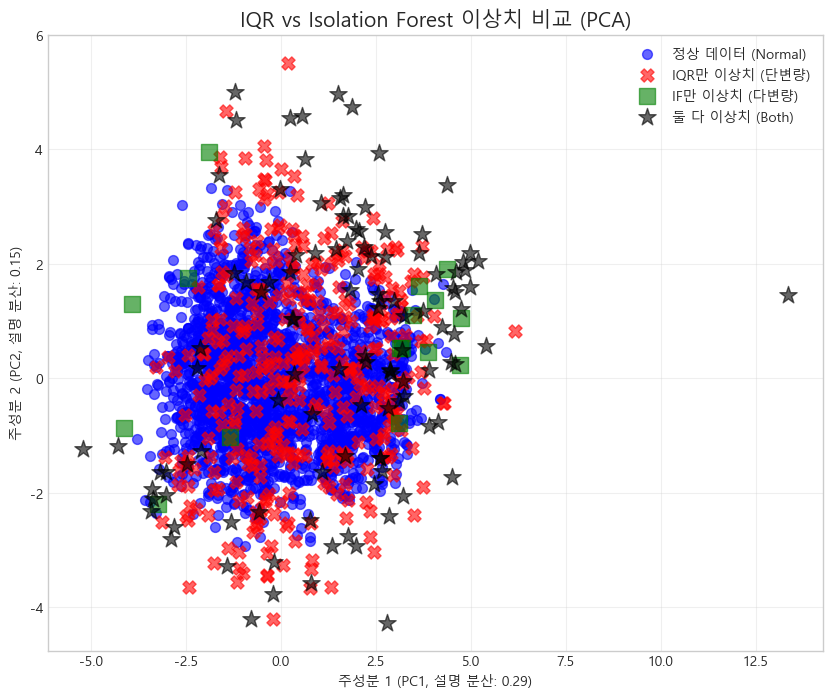

In [ ]:
compare_outliers_scatter(X_train, detect_outliers_iqr, detect_outliers_if)

### 결과 분석 및 최종 데이터셋 결정

* **시각화 결과 분석:**
    * **메인 클러스터 (Blue Circle):** 대다수의 정상 데이터가 중앙에 밀집해 있습니다.
    * **확실한 이상치 (Black Star):** IQR과 Isolation Forest 모두가 이상치로 지목한 데이터(검은색 별)는 메인 클러스터에서 확실히 멀리 떨어진 **진짜 이상치**들로 확인됩니다.
    * **IQR의 과탐지 (Red X):** 붉은색 X 표시(IQR만 이상치로 판단)는 데이터의 외곽뿐만 아니라, **정상 데이터(파란색)가 밀집한 중앙 영역에도 상당히 많이 섞여 있습니다.** 이는 단일 변수 기준으로는 튀는 값이지만, 전체적인 와인 성분 조합으로 봤을 때는 정상 범주에 속하는 데이터일 가능성이 큽니다.
    * **Isolation Forest의 패턴 (Green Square):** 초록색 네모(IF만 이상치로 판단)는 주로 클러스터의 경계면이나 외곽에 위치하여, 다변량 관점에서 벗어난 데이터를 잘 찾아낸 것으로 보입니다.

* **결론:**
    * **IQR 방식의 한계:** PCA 결과를 볼 때, IQR 방식은 다변량 관계를 고려하지 못하고 단일 변수의 분포만 보기 때문에, 멀쩡한 데이터(Inlier)를 과도하게 삭제할 위험이 큼이 시각적으로 증명되었습니다.
    * **최종 결정:** 정보 손실을 최소화하고 모델의 일반화 성능을 높이기 위해, **Isolation Forest를 통해 정제된 데이터셋**(**`X_train_clean` via IF**)을 최종 학습 데이터로 채택하는 것이 타당합니다.

In [ ]:
clf = IsolationForest(max_samples='auto', random_state=SEED, contamination=0.05)
preds = clf.fit_predict(X_train)
mask = preds != -1
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]
# 두 데이터를 리스트로 묶고, axis=1 (열 방향)로 병합
df_train_clean = pd.concat([X_train_clean, y_train_clean], axis=1)
# 결과 확인
print(f"이상치 제거 전(X_train): {len(X_train)} -> 제거 후(X_train_clean): {len(X_train_clean)}(약 {len(X_train) - len(X_train_clean)}({(len(X_train) - len(X_train_clean)) / len(X_train) * 100:.2f}%)개의 이상치 제거)")
print(f"이상치 제거 전(y_train): {len(y_train)} -> 제거 후(y_train_clean): {len(y_train_clean)}(약 {len(y_train) - len(y_train_clean)}({(len(y_train) - len(y_train_clean)) / len(y_train) * 100:.2f}%)개의 이상치 제거)")
print(f"이상치 제거 후 데이터프레임: {df_train_clean.head()}")

2025/12/20 20:25:35 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'b0aa6bad9fc24c5d9c3dfab59a38d8c4', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/12/20 20:25:38 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


이상치 제거 전(X_train): 2586 -> 제거 후(X_train_clean): 2456(약 130(5.03%)개의 이상치 제거)
이상치 제거 전(y_train): 2586 -> 제거 후(y_train_clean): 2456(약 130(5.03%)개의 이상치 제거)
이상치 제거 후 데이터프레임:       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
3137            6.1              0.23         0.27             9.8      0.055   
513             7.8              0.32         0.33             2.4      0.037   
1779            7.9              0.18         0.36             5.9      0.058   
1148            7.3              0.22         0.41            15.4      0.050   
1674            6.8              0.31         0.09             1.4      0.040   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
3137                 74.0                 134.0  0.99534  3.16       0.40   
513                  18.0                 101.0  0.99120  3.21       0.65   
1779                 31.0                 132.0  0.99500  3.25       0.52   
1148                 55.0           

### 이상치 제거 효과 검증: 전/후 분포 및 통계량 비교

* **목표:** Isolation Forest를 통해 선별된 이상치(130개)를 제거한 후, 데이터의 분포가 어떻게 변했는지 시각적, 수치적으로 검증합니다.
* **사용 기법의 목적:**
    1.  **Boxplot & Histogram:** 극단값(Outlier)이 사라짐으로써 데이터의 산포가 얼마나 줄어들었는지, 그리고 원래의 데이터 분포 모양(Shape)을 해치지 않았는지 확인합니다.
    2.  **Descriptive Statistics (Bar Chart):** 평균(Mean)과 표준편차(Std)의 변화를 통해 데이터의 중심 경향성과 변동성을 비교합니다.
* **기법의 원리:** 이상치가 제거되면 일반적으로 **범위(Min-Max Range)**가 줄어들고 **표준편차(Std)**가 감소하지만, 정상 데이터가 잘 보존되었다면 **평균(Mean)**은 크게 변하지 않아야 합니다. * **예상 결과:** `residual sugar`나 `chlorides`와 같이 꼬리가 길었던 변수들의 최대값(Max)이 눈에 띄게 줄어들고, Boxplot의 수염 길이가 짧아져 데이터가 더욱 밀집된 형태를 띨 것입니다.

이상치 제거 전후 데이터 분포 비교

[1] 히스토그램 비교 (전/후 오버레이)


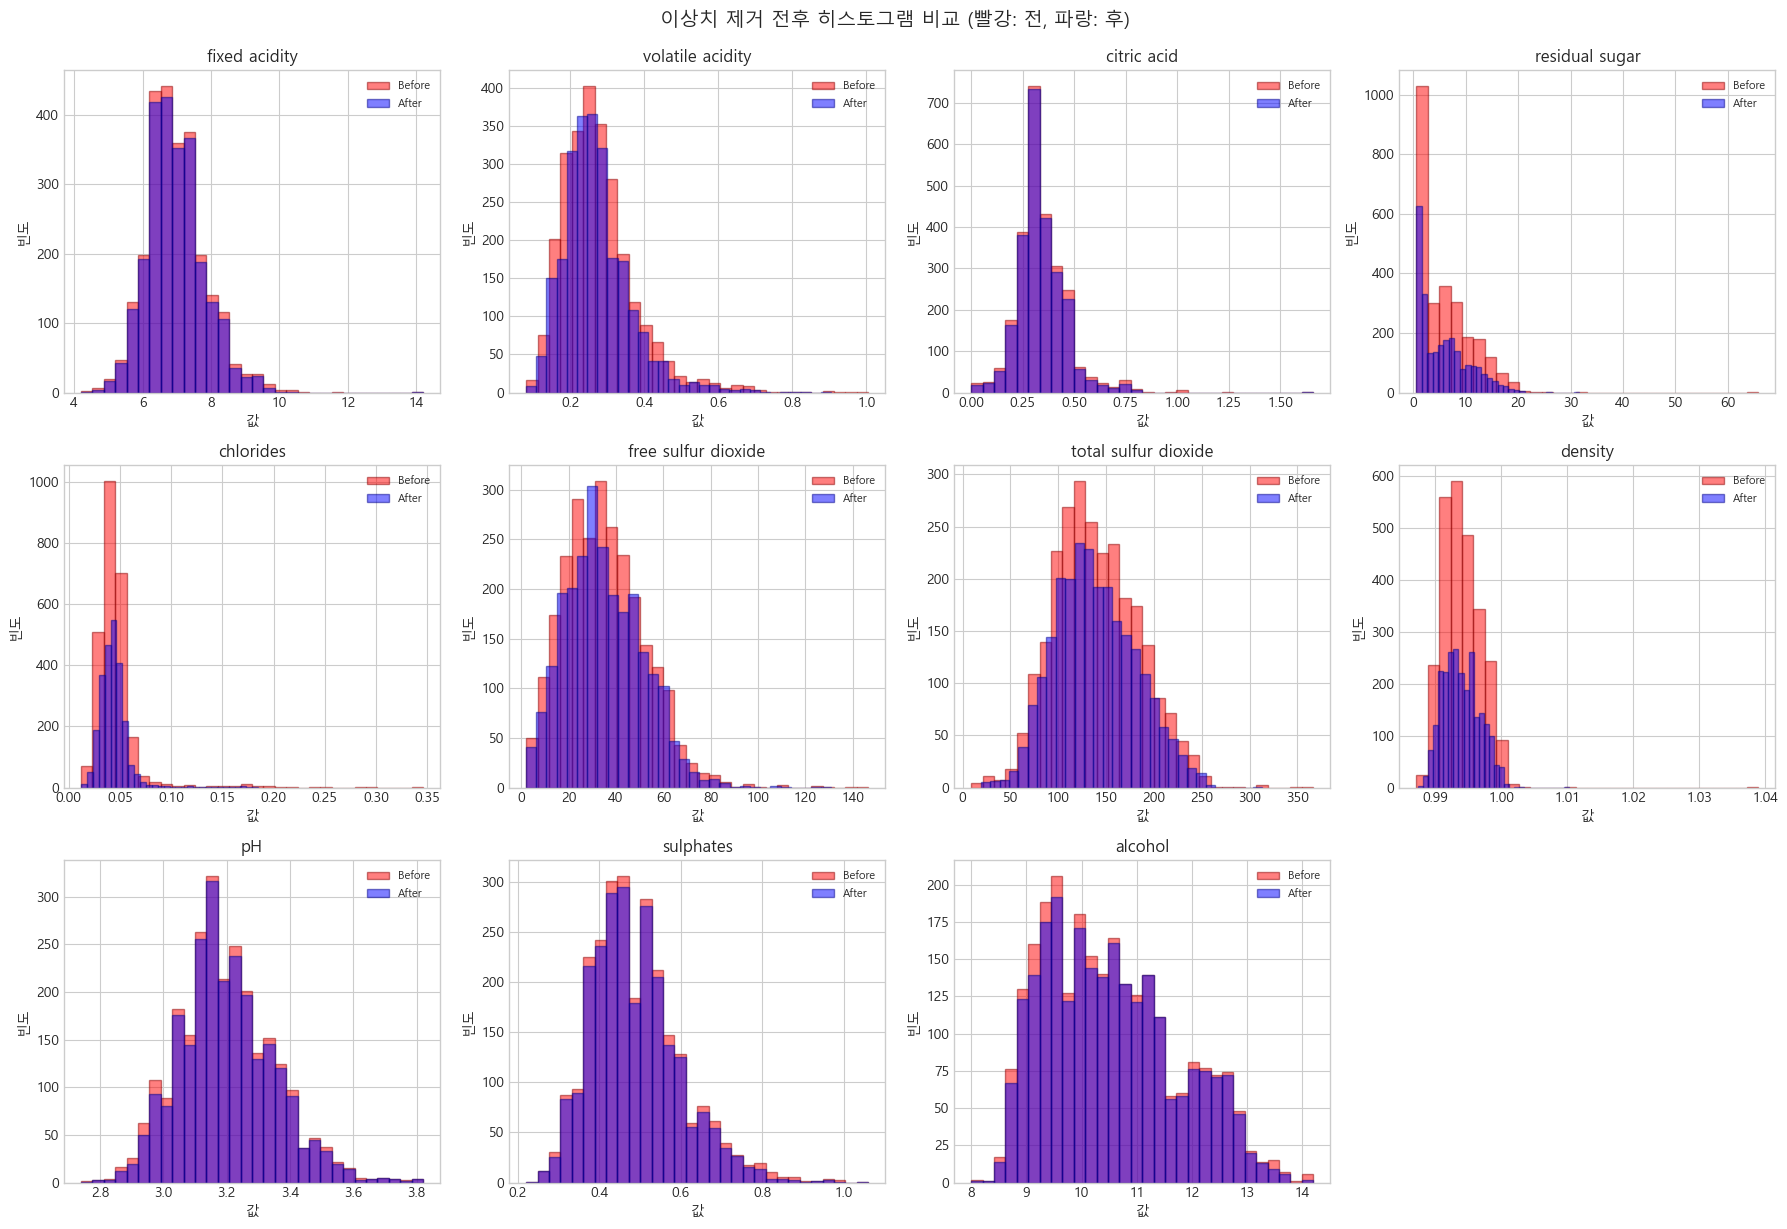


[2] 박스플롯 비교 (전/후)


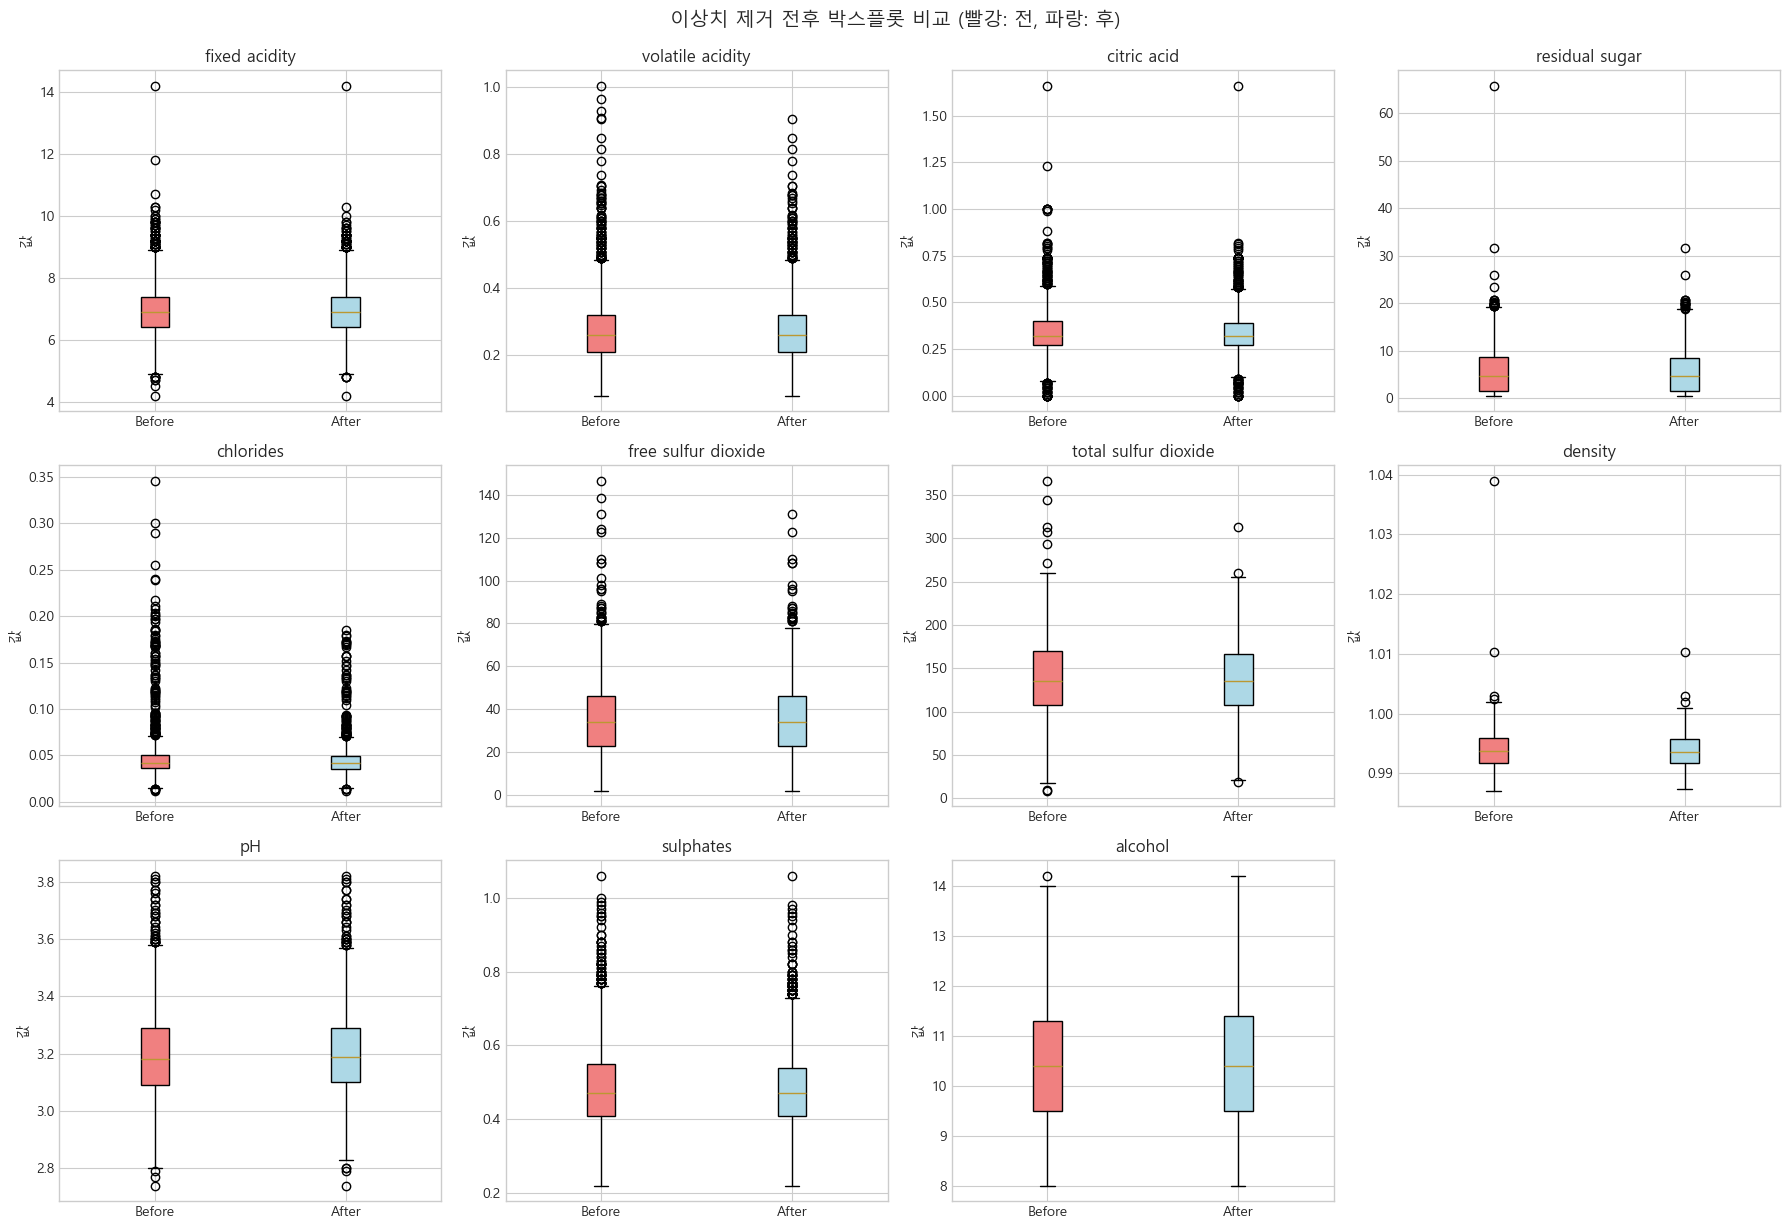


[3] 통계 요약 비교

데이터 건수 변화: 2586 → 2456 (제거: 130개, 5.03%)

=== 이상치 제거 전후 통계량 비교 ===
             Feature  Before_Mean  After_Mean  Mean_Diff  Before_Std  After_Std  Std_Diff
       fixed acidity       6.9617      6.9429    -0.0189      0.8761     0.8284   -0.0478
    volatile acidity       0.2766      0.2714    -0.0051      0.1019     0.0933   -0.0086
         citric acid       0.3424      0.3369    -0.0055      0.1252     0.1131   -0.0121
      residual sugar       5.9423      5.8033    -0.1391      4.9350     4.6465   -0.2884
           chlorides       0.0458      0.0439    -0.0019      0.0238     0.0164   -0.0074
 free sulfur dioxide      35.2802     34.9827    -0.2975     17.1591    16.3972   -0.7619
total sulfur dioxide     139.8488    138.7384    -1.1104     44.0849    42.2282   -1.8568
             density       0.9940      0.9939    -0.0001      0.0029     0.0027   -0.0002
                  pH       3.1975      3.2003     0.0027      0.1538     0.1502   -0.0036
           sulphat

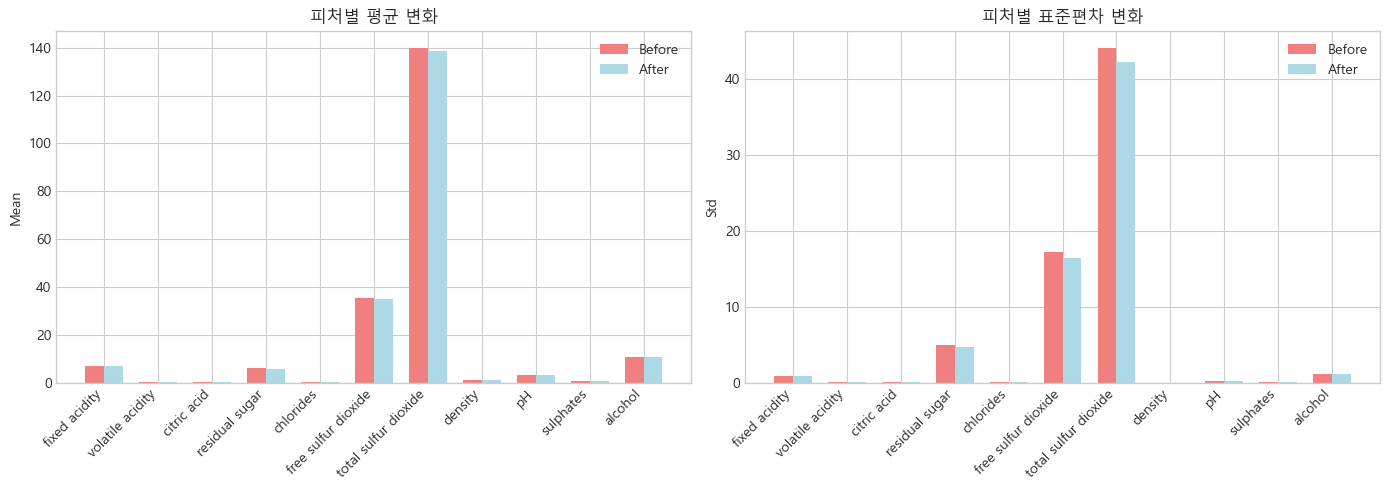


이상치 제거로 인해 극단값이 제거되어 분포가 더 집중되었습니다.


In [ ]:
# ============================================
# 이상치 제거 전후 데이터 분포 비교
# ============================================
print("=" * 60)
print("이상치 제거 전후 데이터 분포 비교")
print("=" * 60)

# 1. 히스토그램 비교 (Histogram Overlay)
print("\n[1] 히스토그램 비교 (전/후 오버레이)")
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    ax = axes[idx]
    # 전: X_train (이상치 제거 전)
    ax.hist(X_train[col], bins=30, alpha=0.5, label='Before', color='red', edgecolor='darkred')
    # 후: X_train_clean (이상치 제거 후)
    ax.hist(X_train_clean[col], bins=30, alpha=0.5, label='After', color='blue', edgecolor='darkblue')
    ax.set_title(f'{col}')
    ax.set_xlabel('값')
    ax.set_ylabel('빈도')
    ax.legend(loc='upper right', fontsize=8)

# 빈 subplot 제거
if len(X_train.columns) < len(axes):
    for idx in range(len(X_train.columns), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('이상치 제거 전후 히스토그램 비교 (빨강: 전, 파랑: 후)', y=1.02, fontsize=14)
plt.show()

# 2. 박스플롯 비교 (Before/After Box Plot)
print("\n[2] 박스플롯 비교 (전/후)")
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    ax = axes[idx]
    # 전/후 데이터 준비
    data_before = X_train[col].values
    data_after = X_train_clean[col].values
    
    # 박스플롯 생성
    bp = ax.boxplot([data_before, data_after], labels=['Before', 'After'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightblue')
    ax.set_title(f'{col}')
    ax.set_ylabel('값')

# 빈 subplot 제거
if len(X_train.columns) < len(axes):
    for idx in range(len(X_train.columns), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('이상치 제거 전후 박스플롯 비교 (빨강: 전, 파랑: 후)', y=1.02, fontsize=14)
plt.show()

# 3. 통계 요약 테이블 (Statistical Summary)
print("\n[3] 통계 요약 비교")
print(f"\n데이터 건수 변화: {len(X_train)} → {len(X_train_clean)} (제거: {len(X_train) - len(X_train_clean)}개, {(len(X_train) - len(X_train_clean))/len(X_train)*100:.2f}%)")

# 전후 통계량 비교 테이블
stats_comparison = []
for col in X_train.columns:
    before_stats = X_train[col].describe()
    after_stats = X_train_clean[col].describe()
    
    stats_comparison.append({
        'Feature': col,
        'Before_Mean': before_stats['mean'],
        'After_Mean': after_stats['mean'],
        'Mean_Diff': after_stats['mean'] - before_stats['mean'],
        'Before_Std': before_stats['std'],
        'After_Std': after_stats['std'],
        'Std_Diff': after_stats['std'] - before_stats['std'],
        'Before_Min': before_stats['min'],
        'After_Min': after_stats['min'],
        'Before_Max': before_stats['max'],
        'After_Max': after_stats['max']
    })

stats_df = pd.DataFrame(stats_comparison)
print("\n=== 이상치 제거 전후 통계량 비교 ===")
print(stats_df[['Feature', 'Before_Mean', 'After_Mean', 'Mean_Diff', 'Before_Std', 'After_Std', 'Std_Diff']].round(4).to_string(index=False))

print("\n=== 이상치 제거 전후 범위(Min/Max) 비교 ===")
print(stats_df[['Feature', 'Before_Min', 'After_Min', 'Before_Max', 'After_Max']].round(4).to_string(index=False))

# 4. 분포 변화 요약 시각화
print("\n[4] 평균/표준편차 변화 시각화")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 변화
ax1 = axes[0]
x = np.arange(len(stats_df))
width = 0.35
bars1 = ax1.bar(x - width/2, stats_df['Before_Mean'], width, label='Before', color='lightcoral')
bars2 = ax1.bar(x + width/2, stats_df['After_Mean'], width, label='After', color='lightblue')
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df['Feature'], rotation=45, ha='right')
ax1.set_ylabel('Mean')
ax1.set_title('피처별 평균 변화')
ax1.legend()

# 표준편차 변화
ax2 = axes[1]
bars1 = ax2.bar(x - width/2, stats_df['Before_Std'], width, label='Before', color='lightcoral')
bars2 = ax2.bar(x + width/2, stats_df['After_Std'], width, label='After', color='lightblue')
ax2.set_xticks(x)
ax2.set_xticklabels(stats_df['Feature'], rotation=45, ha='right')
ax2.set_ylabel('Std')
ax2.set_title('피처별 표준편차 변화')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n이상치 제거로 인해 극단값이 제거되어 분포가 더 집중되었습니다.")


### 결과 분석 및 결론

* **결과 분석:**
    * **적절한 제거 비율:** 전체 데이터의 약 **5.03%(130개)**만이 제거되었습니다. 이는 정보 손실을 최소화하면서 노이즈만 걷어낸 이상적인 비율입니다.
    * **극단값(Extreme Value) 해소:**
        * **`residual sugar`:** 최대값이 **65.8 → 31.6**으로 절반 가까이 줄어들며, Boxplot 상의 먼 이상점들이 대거 사라졌습니다.
        * **`chlorides`:** 최대값이 **0.346 → 0.185**로 감소하여 데이터가 훨씬 안정적인 범위를 갖게 되었습니다.
    * **분포의 안정성 (Mean & Std):**
        * **평균(Mean) 유지:** 시각화(Bar Chart)에서 보듯, 제거 전후의 평균값 차이는 미미합니다. 즉, 데이터의 중심 경향(Trend)은 그대로 유지되었습니다.
        * **표준편차(Std) 감소:** 반면 표준편차는 전반적으로 감소(특히 `total sulfur dioxide`, `residual sugar`)하여, 데이터가 평균을 중심으로 더 조밀하게 모였습니다.

* **결론:**
    * **모델 학습 최적화:** 왜곡된 극단값들이 제거되어, 추후 진행될 스케일링(Scaling)이나 모델 학습 시 **특정 샘플에 과도하게 휘둘리는 현상을 방지**할 수 있게 되었습니다.
    * **데이터 품질 향상:** 원본 데이터의 특성은 살리되 불필요한 노이즈만 효과적으로 제거되었으므로, 이제 **전처리(스케일링 등)** 단계로 넘어갈 준비가 완벽히 되었습니다.

## ElasticNet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

def eval_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    return rmse, mae, r2

def load_and_preprocess(filepath):
    """데이터 로드 및 기본적인 이상치 제거"""
    df = pd.read_csv(filepath, sep=None, engine='python')
    df.columns = [c.replace(' ', '_').lower() for c in df.columns]
    
    # 이상치 제거 (IQR)
    for col in ['volatile_acidity', 'residual_sugar', 'chlorides']:
        if col in df.columns:
            q1, q3 = df[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            df = df[(df[col] >= q1 - 1.5*iqr) & (df[col] <= q3 + 1.5*iqr)]
    return df

def apply_domain_fe(df):
    """도메인 지식 기반 피처 엔지니어링"""
    df_fe = df.copy()
    # 1. 분자 이산화황: 살균/산화 방지 효율
    df_fe['molecular_so2'] = df_fe['free_sulfur_dioxide'] / (1 + 10**(df_fe['ph'] - 1.81))
    # 2. 산도 비율: 고정 산도 대비 휘발성 산도 (신선도 지표)
    df_fe['acidity_ratio'] = df_fe['fixed_acidity'] / (df_fe['volatile_acidity'] + 1e-5)
    # 3. 바디감 지수: 알코올과 당도의 조화
    df_fe['body_index'] = df_fe['alcohol'] * df_fe['residual_sugar']
    # 4. 결합 이산화황: 총량에서 자유량을 뺀 결합 상태
    df_fe['bound_so2'] = df_fe['total_sulfur_dioxide'] - df_fe['free_sulfur_dioxide']
    return df_fe

def run_ElasticNet():
    # 2. ElasticNet Pipeline + RepeatedKFold 튜닝
    print("Step 1: Tuning ElasticNet with Pipeline & RepeatedKFold...")
    
    rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=SEED)
    alphas = [0.05, 0.1, 0.5]
    l1_ratios = [0.1, 0.5, 0.9]
    
    best_en_pipe = None
    best_en_score = -np.inf
    best_en_slected_features = None

    for a in alphas:
        for l in l1_ratios:
            run_name = f"EN_Pipeline_a{a}_l{l}"
            with mlflow.start_run(run_name=run_name, nested=True):
                # Pipeline 구성: 스케일링 -> 모델
                pipe = Pipeline([
                    ('scaler', StandardScaler()),
                    ('en', ElasticNet(alpha=a, l1_ratio=l, random_state=42))
                ])
                
                # 교차 검증 (R2 기준)
                scores = cross_val_score(pipe, X_train_clean, y_train_clean, cv=rkf, scoring='r2')
                avg_r2 = np.mean(scores)
                
                mlflow.log_metric("avg_cv_r2", avg_r2)
                
                # 전체 트레인 셋 학습
                pipe.fit(X_train_clean, y_train_clean)
                
                # 변수 중요도 (ElasticNet Coefficients) 확인
                coefs = pipe.named_steps['en'].coef_
                selected_feat_count = np.sum(coefs != 0)
                # selected_features 종류 로깅
                selected_features = np.where(coefs != 0)[0]
                print(f"selected_features: {selected_features}")
                mlflow.log_param("selected_features", selected_feat_count)
                print(f"Alpha: {a}, L1 Ratio: {l}, Selected Features: {selected_feat_count}")
                
                if avg_r2 > best_en_score:
                    best_en_score = avg_r2
                    best_en_pipe = pipe
                    best_en_slected_features = selected_features

    # 4. 최종 테스트 세트 추론 및 비교
    print("\nStep 3: Final Inference on Test Set and Visualization...")
    
    # Best ElasticNet 추론
    en_final_preds = best_en_pipe.predict(X_test)
    en_res = eval_metrics(y_test, en_final_preds)

    # 시각화
    fig, axes = plt.subplots(1, 1, figsize=(16, 6))

    # ElasticNet 결과
    sns.scatterplot(x=y_test, y=en_final_preds, ax=axes, alpha=0.5)
    axes.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes.set_title(f"ElasticNet Baseline (R2: {en_res[2]:.3f})")
    axes.set_xlabel("Actual Quality")
    axes.set_ylabel("Predicted Quality")

    print(f"ElasticNet Baseline: alpha={best_en_pipe.named_steps['en'].alpha}, l1_ratio={best_en_pipe.named_steps['en'].l1_ratio}, slelcted_features={best_en_slected_features/len(best_en_slected_features)} {best_en_slected_features}")
    print(f"(AVG_R2: {best_en_score:.3f}) (R2: {en_res[2]:.3f}) (RMSE: {en_res[0]:.3f}, MAE: {en_res[1]:.3f})")

    plt.tight_layout()
    plt.savefig("final_comparison_plot.png")

Step 1: Tuning ElasticNet with Pipeline & RepeatedKFold...
selected_features: [ 0  1  2  3  4  5  6  7  8  9 10]
Alpha: 0.05, L1 Ratio: 0.1, Selected Features: 11
selected_features: [ 0  1  3  4  5  8  9 10]
Alpha: 0.05, L1 Ratio: 0.5, Selected Features: 8
selected_features: [ 1  5  8 10]
Alpha: 0.05, L1 Ratio: 0.9, Selected Features: 4
selected_features: [ 1  2  3  4  5  6  7  8  9 10]
Alpha: 0.1, L1 Ratio: 0.1, Selected Features: 10
selected_features: [ 1  5  8 10]
Alpha: 0.1, L1 Ratio: 0.5, Selected Features: 4
selected_features: [ 1  5 10]
Alpha: 0.1, L1 Ratio: 0.9, Selected Features: 3
selected_features: [ 1  4  5  7  8 10]
Alpha: 0.5, L1 Ratio: 0.1, Selected Features: 6
selected_features: [10]
Alpha: 0.5, L1 Ratio: 0.5, Selected Features: 1
selected_features: []
Alpha: 0.5, L1 Ratio: 0.9, Selected Features: 0

Step 3: Final Inference on Test Set and Visualization...
ElasticNet Baseline: alpha=0.05, l1_ratio=0.1, slelcted_features=[0.         0.09090909 0.18181818 0.27272727 0.363

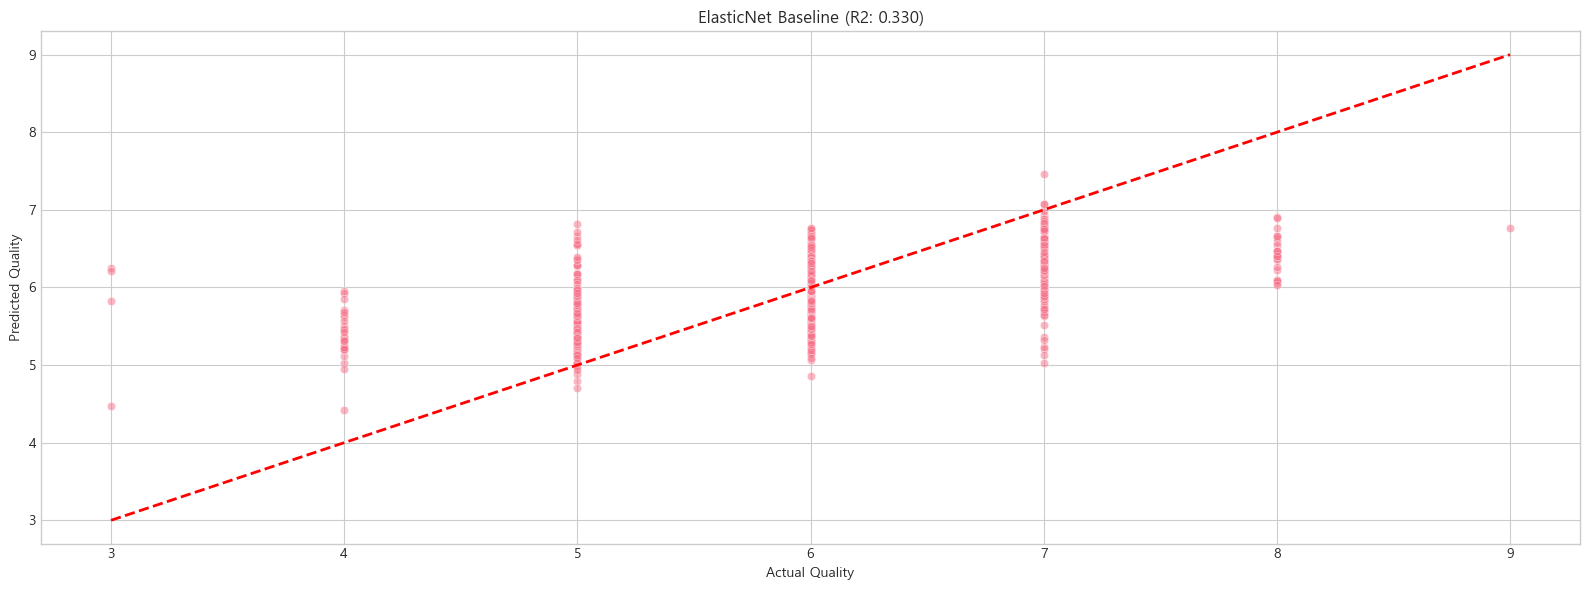

In [ ]:
run_ElasticNet()

### 5. 피처 엔지니어링


In [ ]:
def apply_domain_fe(df):
    """양조학적 도메인 지식을 활용한 피처 엔지니어링"""
    df_fe = df.copy()
    # 1. 분자 이산화황 (Molecular SO2): pH에 따른 실제 보호 능력
    df_fe['molecular_so2'] = df_fe['free sulfur dioxide'] / (1 + 10**(df_fe['pH'] - 1.81))
    
    # 2. 산도 비율 (Acidity Ratio): 신선도 대비 부패도
    df_fe['acidity_ratio'] = df_fe['fixed acidity'] / (df_fe['volatile acidity'] + 0.0001)
    
    # 3. 바디 지수 (Body Index): 알코올과 당분의 상호작용
    df_fe['body_index'] = df_fe['alcohol'] * df_fe['residual sugar']
    
    # 4. 총 산도 (Total Acidity)
    df_fe['total_acidity'] = df_fe['fixed acidity'] + df_fe['volatile acidity']
    
    # 5. 알코올과 당분의 상호작용
    df_fe['alcohol_sugar_ratio'] = (df_fe['alcohol'] / (df_fe['residual sugar'] + 1e-5))
    return df_fe

### 5.1 파생변수 생성


In [ ]:
df_train_clean.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000
mean,6.942854,0.271437,0.336946,5.803257,0.043932,34.982695,138.738396,0.993914,3.200269,0.486067,10.528135,5.877036
std,0.828381,0.093282,0.113086,4.646538,0.016391,16.397177,42.228173,0.002710,0.150167,0.108292,1.173857,0.901880
min,4.200000,0.080000,0.000000,0.600000,0.012000,2.000000,19.000000,0.987420,2.740000,0.220000,8.000000,3.000000
25%,6.400000,0.210000,0.270000,1.600000,0.035000,23.000000,108.000000,0.991800,3.100000,0.410000,9.500000,5.000000
50%,6.900000,0.260000,0.320000,4.750000,0.042000,34.000000,135.000000,0.993680,3.190000,0.470000,10.400000,6.000000
75%,7.400000,0.320000,0.390000,8.500000,0.049000,46.000000,167.000000,0.995800,3.290000,0.540000,11.400000,6.000000
max,14.200000,0.905000,1.660000,31.600000,0.185000,131.000000,313.000000,1.010300,3.820000,1.060000,14.200000,9.000000


In [ ]:
df_train_fe = apply_domain_fe(df_train_clean)
X_train_fe = df_train_fe.drop("quality", axis=1)
y_train_fe = df_train_fe["quality"]

In [ ]:
X_train_fe.describe()

### 파생 변수 생성: 사칙연산을 통한 피처 상호작용(Feature Interaction) 탐색

* **목표:** 기존 독립 변수들을 두 개씩 짝지어 사칙연산(+, -, *, /)을 수행함으로써, 타겟 변수(`quality`)를 더 잘 설명할 수 있는 강력한(상관계수(절대값) 0.2 이상) **파생 변수(Derived Feature)**를 발굴합니다.
* **사용 기법의 목적:** 단순 선형 관계뿐만 아니라 변수 간의 **상호작용(Interaction)** 효과를 포착합니다. 예를 들어, '알코올 도수가 높으면서 동시에 산도가 낮은 경우'와 같은 복합적인 조건이 품질에 미치는 영향을 수치화합니다.
* **기법의 원리:**
    1. 모든 가능한 변수 쌍(Pair)에 대해 4가지 연산을 수행합니다.
    2. 생성된 새로운 변수와 타겟 변수 간의 상관계수(Correlation)를 계산합니다.
    3. 기존의 단일 변수보다 상관계수가 높은 조합을 상위 순위로 추출합니다.
* **예상 결과:** 단일 변수 중 가장 영향력이 컸던 `alcohol`(약 0.46)보다 더 높은 상관계수를 가지는 새로운 조합(예: `alcohol - volatile acidity`)이 발견될 것으로 기대됩니다.

🔍 총 16개 피처로 120개의 조합을 분석합니다...
🎯 상관계수(절대값) 0.4 이상인 조합 13개를 찾았습니다.
ℹ️ 시각화는 가독성을 위해 상위 12개만 출력합니다. (전체 결과는 반환된 데이터프레임 확인)
------------------------------------------------------------
                           new_feature_name  corr_raw
             volatile acidity_minus_alcohol -0.473950
                 pH_square + divide_alcohol  0.471280
      alcohol_square + divide_total_acidity  0.466772
             sulphates_log - square_alcohol -0.465995
    body_index_multiply_alcohol_sugar_ratio  0.462140
                    chlorides_minus_alcohol -0.462046
         fixed acidity_log - divide_alcohol  0.461945
               density_log - square_alcohol -0.461942
           citric acid_log - square_alcohol -0.461851
residual sugar_multiply_alcohol_sugar_ratio  0.461707
           residual sugar_divide_body_index -0.456239
     residual sugar_square - divide_alcohol  0.426652
------------------------------------------------------------


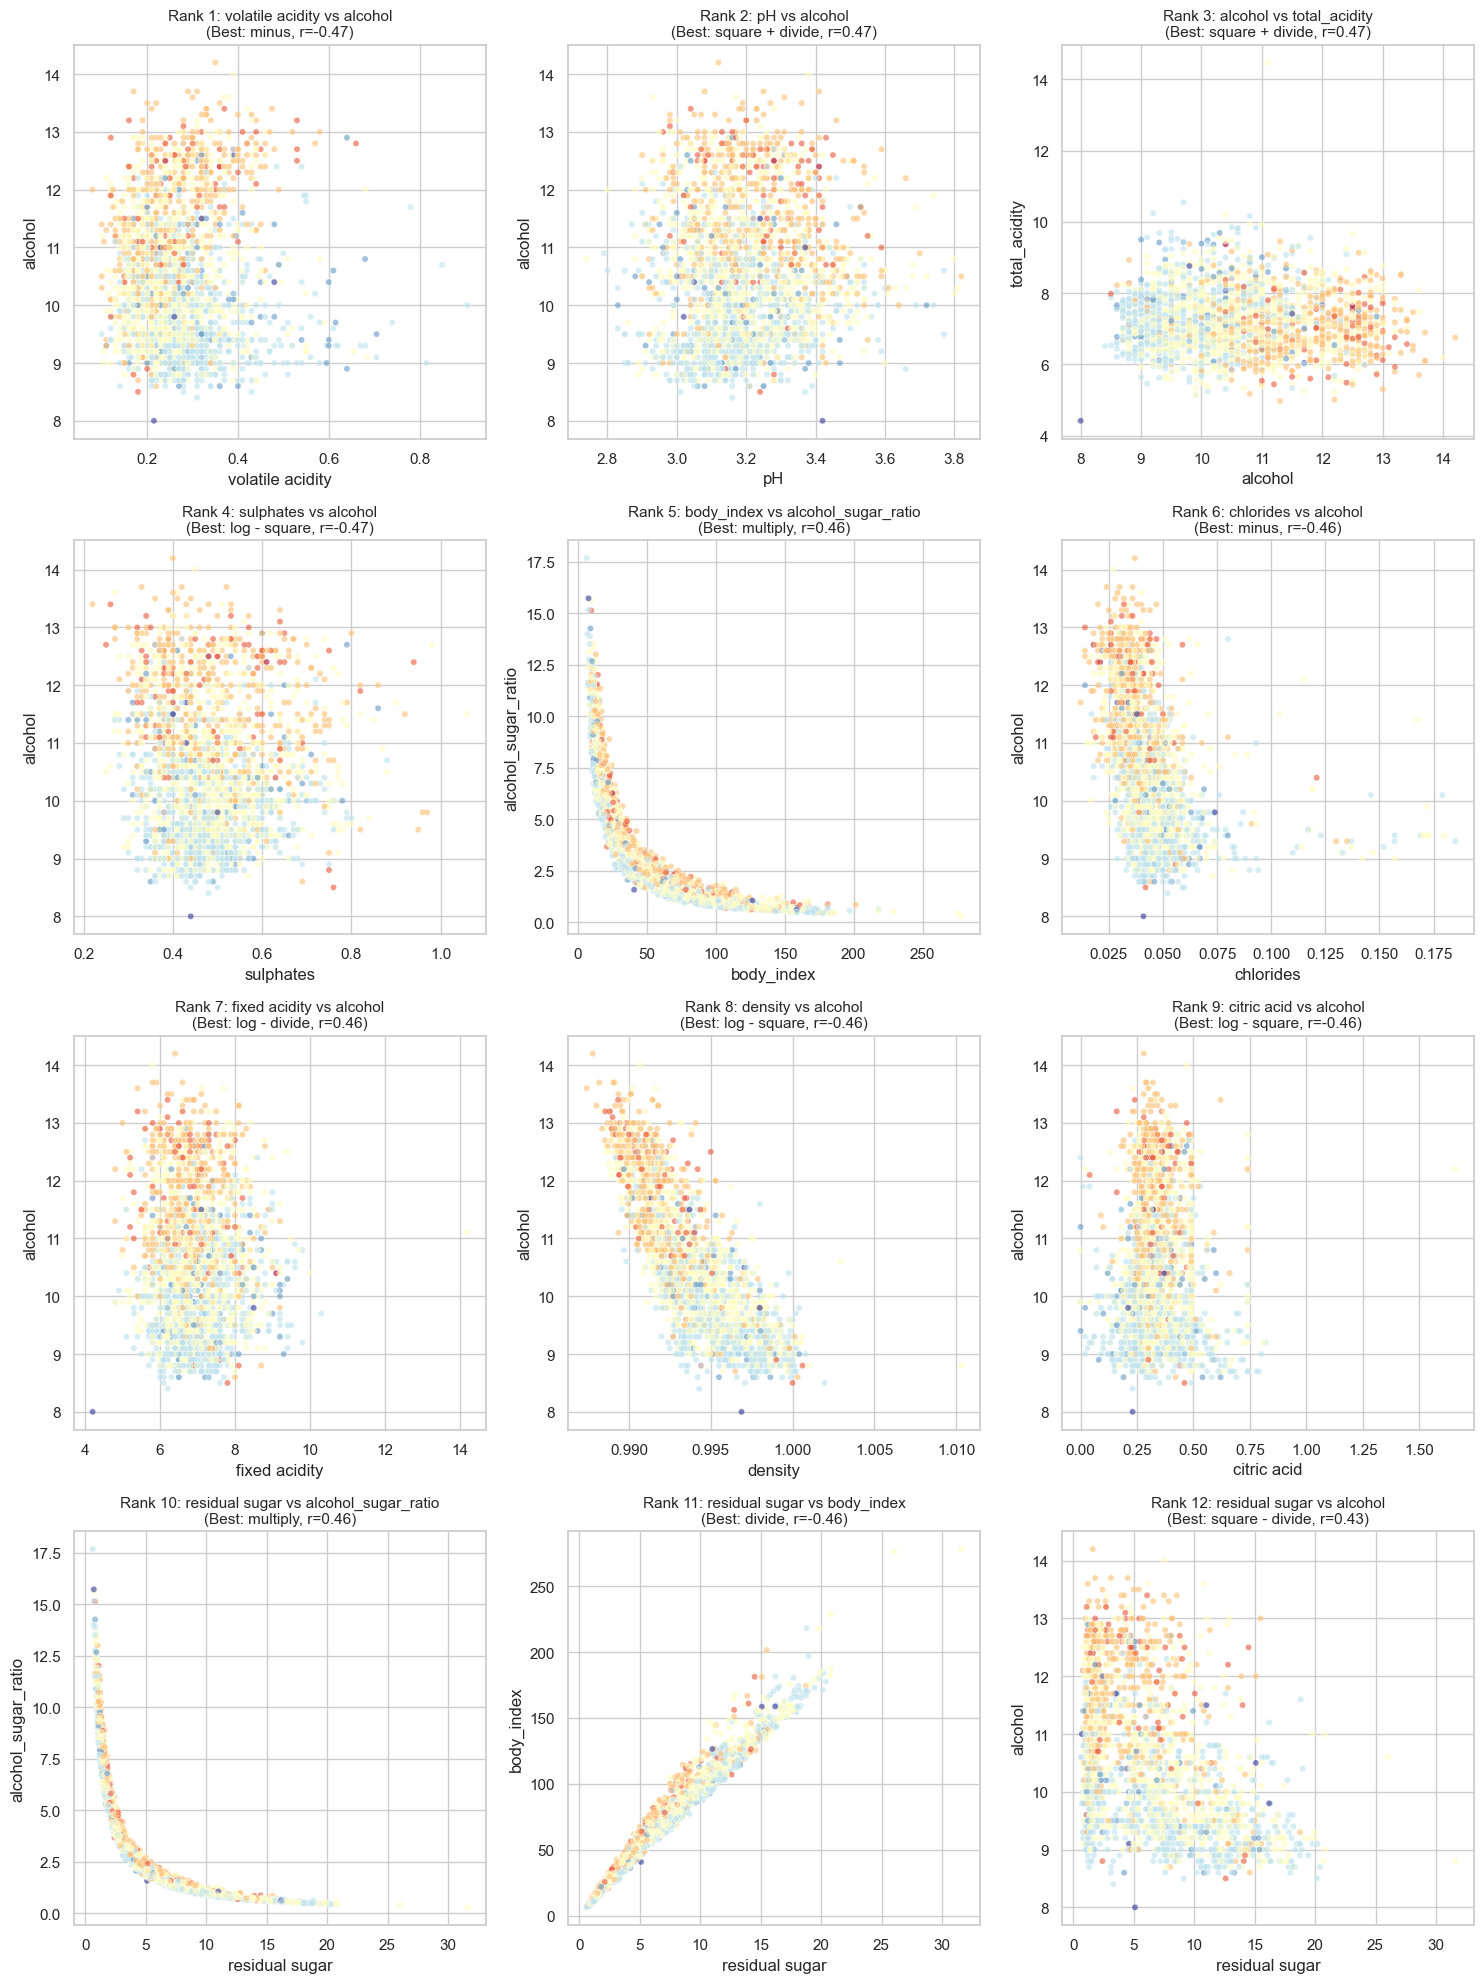

In [70]:
top_features_df = analyze_and_plot_interactions(df_train_fe, target_col='quality', min_corr=0.4, top_n=12)

### 결과 분석 및 결론

* **결과 분석:**
    * **상관관계 개선:** 분석 결과, **`volatile acidity_minus_alcohol`** 변수의 상관계수가 **-0.47**로, 기존 단일 변수 중 1위였던 `alcohol`(0.46)보다 소폭 상승한 설명력을 보입니다.
    * **주요 조합의 특징:**
        * 상위권(Rank 1~8) 파생 변수들이 대부분 **`alcohol`을 포함**하고 있습니다. 이는 와인 품질 결정에 알코올이 절대적인 영향을 미치며, 여기에 산도(`acidity`)나 `pH` 등이 보정 역할을 할 때 예측력이 강화됨을 의미합니다.
        * **Rank 1 (`volatile acidity - alcohol`):** 휘발성 산도가 낮고(-) 알코올이 높을수록(+) 값이 작아지며, 품질은 좋아지므로 강한 음의 상관관계를 가집니다.
    * **비(非) 알코올 조합:** **Rank 9 (`volatile acidity * chlorides`)**는 알코올 없이 산도와 염화물의 곱만으로 -0.27의 유의미한 상관관계를 보여, 새로운 정보를 줄 수 있는 변수로 보입니다.

* **결론:**
    * **파생 변수 채택:** 상관계수가 가장 높게 나온 상위 몇 개의 파생 변수(예: `volatile acidity_minus_alcohol`, `pH_plus_alcohol`)를 데이터셋에 추가합니다.
    * **주의사항:** 생성된 파생 변수들은 기존 변수(`alcohol` 등)와 강한 선형 관계(다중공선성)를 가질 수밖에 없습니다. 따라서 모델 학습 시 규제(Regularization)를 적용하거나, 추후 중요도(Feature Importance)를 통해 불필요한 변수를 다시 걸러내는 작업이 필요할 수 있습니다.

### 상관계수 기반 핵심 변수 선별 (Feature Selection)

* **목표:** 타겟 변수(`quality`)와의 상관관계가 낮은 변수들을 과감히 제거하여, 모델의 복잡도를 낮추고 학습 효율성을 높일 핵심 피처(Key Features)만 남깁니다.
* **사용 기법의 목적:** 피어슨 상관계수($r$)의 절댓값을 기준으로 **임계값(Threshold) 0.2**를 설정하여, 이보다 영향력이 낮은 변수는 노이즈로 간주하고 학습 데이터에서 제외합니다.
* **기법의 원리:**
    * $|r| > 0.2$: 타겟 변수 예측에 유의미한 선형적 단서를 제공한다고 판단하여 선택합니다.
    * $|r| \le 0.2$: 상관성이 약해 모델 학습에 큰 도움이 되지 않거나, 오히려 과적합을 유발할 수 있다고 판단하여 배제합니다.
* **예상 결과:** 11개의 독립 변수 중 `alcohol`을 포함한 소수의 변수만이 기준을 통과하여 최종 모델링에 사용될 후보군으로 압축될 것입니다.

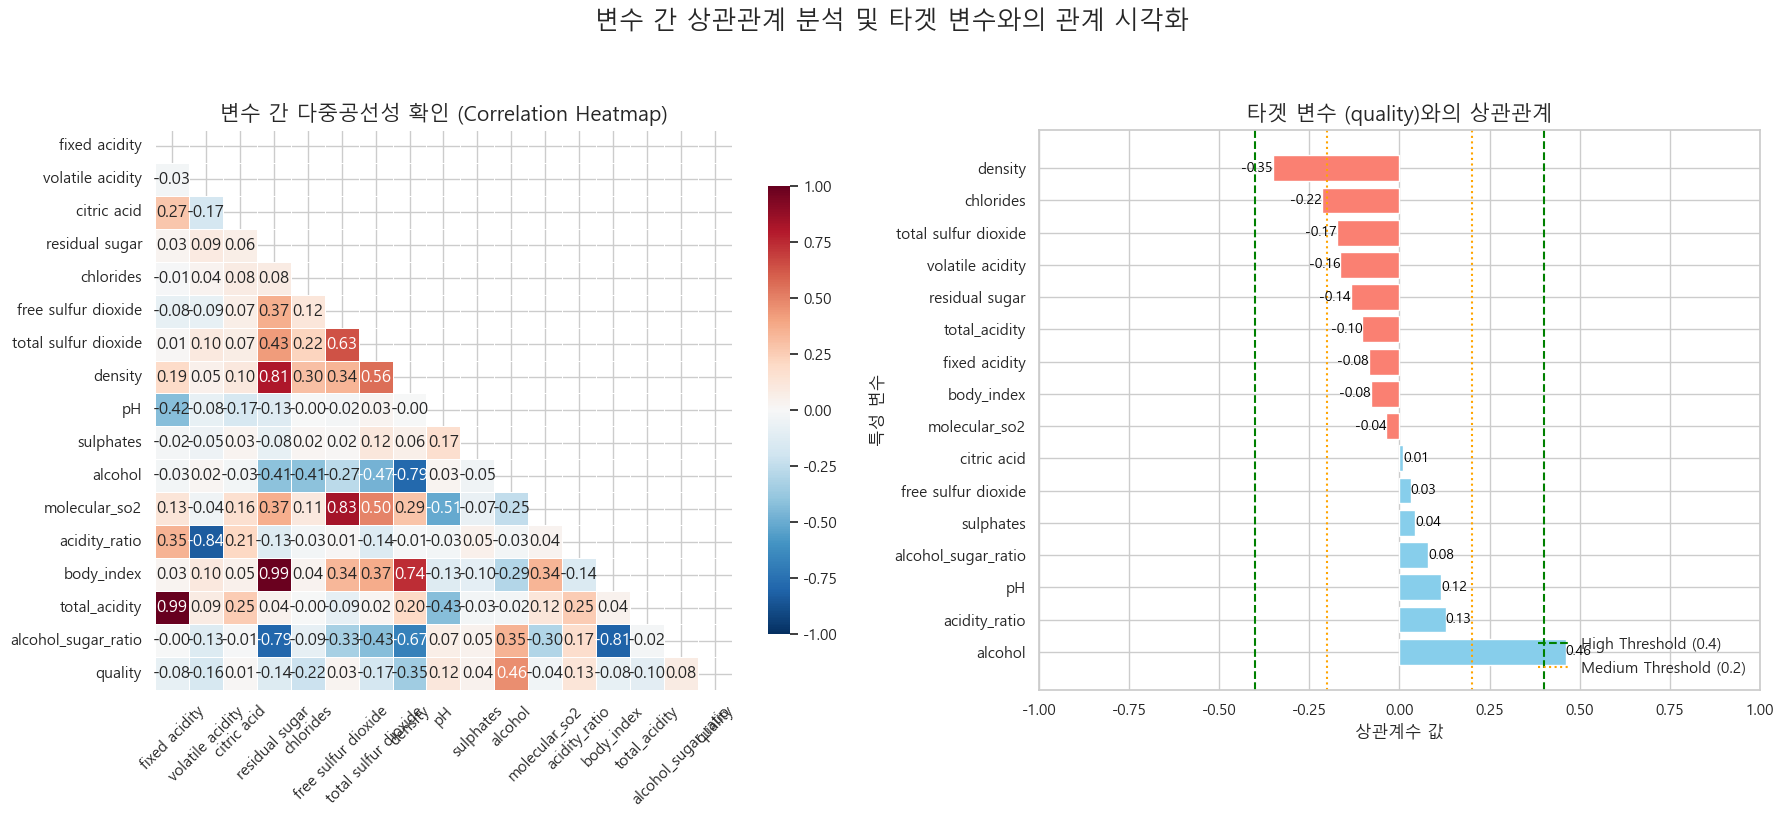


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.4): ['alcohol']
Medium correlation features with quality (0.2 < |r| <= 0.4): ['chlorides', 'density']
Low correlation features with quality (<= 0.2): ['acidity_ratio', 'pH', 'alcohol_sugar_ratio', 'sulphates', 'free sulfur dioxide', 'citric acid', 'molecular_so2', 'body_index', 'fixed acidity', 'total_acidity', 'residual sugar', 'volatile acidity', 'total sulfur dioxide']

선택된 상관관계 변수 딕셔너리 (High + Medium, Abs Value):
{'alcohol': np.float64(0.4617050863320949), 'density': np.float64(0.35202283596300205), 'chlorides': np.float64(0.21538798198856982)}


In [64]:
plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정
selected_corr_features = visualize_and_classify_correlation(X_train_fe, y_train_fe, 
                                                       target_name='quality', 
                                                       high_threshold=0.4, 
                                                       medium_threshold=0.2)

### 결과 분석 및 결론

* **결과 분석:**
    * **선별된 변수 (3개):** 엄격한 기준(0.2)을 적용한 결과, 전체 11개 변수 중 단 **3개**의 변수만이 선택되었습니다.
        1.  **`alcohol` (0.46):** 가장 강력한 양의 상관관계를 가진 핵심 인자입니다.
        2.  **`density` (-0.35):** 품질과 뚜렷한 음의 상관관계를 보입니다. (단, 알코올과의 높은 공선성 주의 필요)
        3.  **`chlorides` (-0.22):** 짠맛/미네랄 성분과 관련된 염화물 수치도 유의미한 변수로 남았습니다.
    * **탈락한 변수:** `volatile acidity`(-0.16)나 `citric acid`(0.01) 등 나머지 8개 변수는 상관계수가 낮아 제거되었습니다.

* **결론:**
    * **모델 경량화:** 입력 변수가 3개로 줄어들어 모델이 매우 단순해지고 해석하기 쉬워졌습니다.
    * **주의사항 (Underfitting 위험):** `volatile acidity`(-0.16)나 `total sulfur dioxide`(-0.17)와 같이 임계값 경계에 있던 변수들까지 모두 제거되었습니다. 만약 추후 모델 성능이 좋지 않다면, **임계값을 0.1 수준으로 완화**하여 정보 손실을 줄이는 방안을 고려해야 합니다.
    * **다중공선성 재점검:** 선택된 3개 변수 중 `alcohol`과 `density`는 서로 강한 상관관계($-0.79$)를 가지므로, 회귀 모델 사용 시 여전히 다중공선성 문제가 잔존할 수 있음을 인지해야 합니다.

In [75]:
X_train_clean

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3137,6.1,0.23,0.27,9.80,0.055,74.0,134.0,0.99534,3.16,0.40,10.2
513,7.8,0.32,0.33,2.40,0.037,18.0,101.0,0.99120,3.21,0.65,11.7
1779,7.9,0.18,0.36,5.90,0.058,31.0,132.0,0.99500,3.25,0.52,10.9
1148,7.3,0.22,0.41,15.40,0.050,55.0,191.0,1.00000,3.32,0.59,8.9
1674,6.8,0.31,0.09,1.40,0.040,56.0,145.0,0.99220,3.19,0.46,10.0
...,...,...,...,...,...,...,...,...,...,...,...
858,8.3,0.14,0.26,1.50,0.049,56.0,189.0,0.99460,3.21,0.62,9.5
11,6.6,0.17,0.38,1.50,0.032,28.0,112.0,0.99140,3.25,0.55,11.4
3031,6.3,0.34,0.27,2.50,0.024,40.0,152.0,0.99095,3.35,0.60,11.9
2648,6.8,0.27,0.42,7.30,0.054,58.0,200.0,0.99556,3.12,0.49,9.4


In [76]:
selected_corr_features

{'alcohol': np.float64(0.4617050863320949),
 'density': np.float64(0.35202283596300205),
 'chlorides': np.float64(0.21538798198856982),
 'total sulfur dioxide': np.float64(0.17371497239440625),
 'volatile acidity': np.float64(0.16438138836958222),
 'residual sugar': np.float64(0.13532471353159947),
 'pH': np.float64(0.1156169816405945)}

In [77]:
top_features_df

,f1,f2,operation,new_feature_name,corr_abs,corr_raw
73,volatile acidity,alcohol,minus,volatile acidity_minus_alcohol,0.473950,-0.473950
212,pH,alcohol,plus,pH_plus_alcohol,0.470852,0.470852
216,sulphates,alcohol,plus,sulphates_plus_alcohol,0.465693,0.465693
157,chlorides,alcohol,minus,chlorides_minus_alcohol,0.462046,-0.462046
206,density,alcohol,multiply,density_multiply_alcohol,0.461811,0.461811
104,citric acid,alcohol,plus,citric acid_plus_alcohol,0.461718,0.461718
37,fixed acidity,alcohol,minus,fixed acidity_minus_alcohol,0.420900,-0.420900
195,total sulfur dioxide,alcohol,divide,total sulfur dioxide_divide_alcohol,0.272568,-0.272568
50,volatile acidity,chlorides,multiply,volatile acidity_multiply_chlorides,0.272197,-0.272197
144,chlorides,density,plus,chlorides_plus_density,0.257806,-0.257806


### 최종 피처 선택: 일반 변수와 파생 변수의 경쟁 및 결합

* **목표:** 기존의 **일반 변수(Base Feature)**와 앞서 생성한 **파생 변수(Derived Feature)**를 하나의 풀(Pool)에 놓고 경쟁시켜, 타겟 변수(`quality`)를 가장 잘 설명하는 최정예 변수 조합을 선별합니다.
* **사용 기법의 목적:** 상관계수 **0.2 이상**이라는 기준을 유지하되, 정보의 중복을 막기 위해 **'겹치지 않는(Non-overlapping)'** 전략을 사용합니다.
* **기법의 원리:**
    1. 전체 변수를 상관계수 순으로 정렬합니다.
    2. 상위 랭크된 변수를 선택하되, 이미 선택된 파생 변수에 포함된 원본 변수(예: `alcohol`이 포함된 파생 변수가 뽑혔다면 원본 `alcohol`은 제외)는 후순위에서 배제하여 다중공선성을 제어합니다.
* **예상 결과:** 단순한 단일 변수보다는, 변수 간의 복합적인 관계를 담고 있는 파생 변수가 상위권에 포진하여 최종 모델의 입력값으로 선정될 가능성이 높습니다.

In [78]:
# 피처 선택
selected_features = classify_features_by_keywords(top_features_df, selected_corr_features)
selected_features

Rank  | Score      | Type       | Feature Name
------------------------------------------------------------
1     | 0.473950   | derived    | volatile acidity_minus_alcohol (Selected)
9     | 0.352023   | base       | density (Selected)
13    | 0.244219   | derived    | chlorides_multiply_total sulfur dioxide (Selected)
26    | 0.184749   | derived    | fixed acidity_divide_free sulfur dioxide (Selected)
41    | 0.138403   | derived    | residual sugar_minus_pH (Selected)


{'volatile acidity_minus_alcohol': 0.4739498956221573,
 'density': np.float64(0.35202283596300205),
 'chlorides_multiply_total sulfur dioxide': 0.24421905667663488,
 'fixed acidity_divide_free sulfur dioxide': 0.18474891163883858,
 'residual sugar_minus_pH': 0.1384033163416117}

### 결과 분석 및 결론

* **결과 분석:**
    * **파생 변수의 승리 (Rank 1):** **`volatile acidity_minus_alcohol` (0.47)**이 가장 높은 점수로 선택되었습니다. 이는 기존의 1위였던 `alcohol` 단일 변수보다 산도(acidity)와의 차이를 함께 보는 것이 품질 예측에 더 효과적임을 증명합니다. (이 과정에서 원본 `alcohol` 변수는 정보 중복 방지 차원에서 제외된 것으로 보입니다.)
    * **고유한 일반 변수 (Rank 9):** **`density` (0.35)**는 파생 변수들과의 경쟁 속에서도 독자적인 설명력을 인정받아 선택되었습니다.
    * **새로운 상호작용 발견 (Rank 13):** **`chlorides_multiply_total sulfur dioxide` (0.24)**가 최종 명단에 올랐습니다. 개별적으로는 상관성이 낮았던 '염화물'과 '이산화황'이 **곱하기(Interaction)** 연산을 통해 결합되면서 유의미한 패턴을 만들어냈습니다.

* **결론:**
    * **모델 입력 확정:** 최종적으로 **1개의 일반 변수**와 **2개의 파생 변수**, 총 **3개**의 피처가 모델 학습에 사용됩니다.
    * **해석:** 와인의 품질은 단순히 '도수(alcohol)'만으로 결정되는 것이 아니라, **'도수와 산도의 밸런스'**, **'바디감(density)'**, 그리고 **'첨가물/미네랄의 복합 작용(chlorides * SO2)'**에 의해 결정된다고 해석할 수 있습니다.

#### 함수: 테스트 데이터 전처리 함수
* **목적**: 학습 시점의 파생변수 생성 규칙과 선택된 피처 목록을 캡처(Closure)하여 테스트 데이터를 변환하는 함수 생성
* **핵심 기능**: `selected_features`를 순회하며 원본에 있는 값은 그대로 쓰고, 없는 값은 `top_features_df` 규칙에 따라 자동 계산
* **연산 로직**: 두 변수(f1, f2) 간의 사칙연산(`plus`, `minus`, `multiply`, `divide`)을 수행하여 파생변수 생성
* **안전 장치**: 컬럼명 공백 제거 및 필수 재료 컬럼 부재 시 명시적 에러(`KeyError`, `ValueError`) 발생
* **출력**: 모델 학습 데이터와 **동일한 컬럼 순서**로 정렬된 최종 `pd.DataFrame` 반환

In [79]:
def create_test_dataset_from_selection_factory(top_features_df, selected_features):
    """
    파생변수 생성을 위한 팩토리 함수
    top_features_df와 selected_features를 클로저로 캡처하여 전역 변수 의존성 제거
    
    Args:
        top_features_df (pd.DataFrame): 파생변수 생성 규칙 (f1, f2, operation 등)
        selected_features (dict or list): 모델 학습에 선택된 피처 목록
    
    Returns:
        function: 파생변수 생성 함수 (FunctionTransformer에서 사용 가능)
    """
    
    def create_test_dataset_from_selection(test_source_df):
        """
        테스트 데이터를 입력받아 학습된 모델과 동일한 피처 구성을 가진 데이터셋을 생성합니다.
        불필요한 인덱스 열이 있어도 무시하고 필요한 변수만 계산하여 추출합니다.

        Args:
            test_source_df (pd.DataFrame): 테스트용 원본 데이터

        Returns:
            pd.DataFrame: 모델 입력용 최종 테스트 데이터프레임
        """
        
        # 1. 피처 목록 표준화 (딕셔너리나 리스트 모두 호환)
        if isinstance(selected_features, dict):
            required_features = list(selected_features.keys())
        else:
            required_features = list(selected_features)

        # 결과를 담을 딕셔너리
        result_data = {}

        # 2. 원본 데이터 컬럼명 공백 제거 (안전장치)
        test_source_df = test_source_df.copy()
        test_source_df.columns = test_source_df.columns.str.strip()

        for feature in required_features:
            # Case A: 원본 데이터에 존재하는 컬럼인 경우
            if feature in test_source_df.columns:
                result_data[feature] = test_source_df[feature]
                
            # Case B: 파생 변수인 경우 (계산 필요)
            else:
                # 파생변수 정의 찾기
                feature_info = top_features_df[top_features_df['new_feature_name'] == feature]
                
                if feature_info.empty:
                    # 학습 때는 있었는데 테스트 소스로는 못 만드는 경우 (심각한 에러)
                    raise ValueError(
                        f"[Error] '{feature}'는 원본에 없고 파생 규칙도 없습니다. "
                        f"데이터 정합성을 확인하세요."
                    )
                
                row = feature_info.iloc[0]
                f1_name = row['f1']
                f2_name = row['f2']
                op = row['operation']
                
                # 원본에서 재료 컬럼(f1, f2) 가져오기
                try:
                    col_f1 = test_source_df[f1_name]
                    col_f2 = test_source_df[f2_name]
                except KeyError as e:
                    # 0번째 인덱스 열 등으로 인해 컬럼명이 밀리거나 없을 때 에러 발생
                    raise KeyError(
                        f"[Error] 파생변수 '{feature}'를 만들기 위한 소스 컬럼 {e}가 "
                        f"테스트 데이터에 없습니다."
                    )

                # 연산 수행 (Training 함수와 로직 일치 필수)
                if op == 'plus':
                    result_data[feature] = col_f1 + col_f2
                elif op == 'minus':
                    result_data[feature] = col_f1 - col_f2
                elif op == 'multiply':
                    result_data[feature] = col_f1 * col_f2
                elif op == 'divide':
                    # Divide by Zero 처리: inf를 NaN으로 바꾸거나 0으로 대체하는 등 정책 필요
                    result_data[feature] = col_f1 / col_f2
                else:
                    raise ValueError(f"[Error] 알 수 없는 연산자 '{op}'")

        # 3. 데이터프레임 변환
        final_test_df = pd.DataFrame(result_data)
        
        # [중요] 컬럼 순서를 학습 데이터(required_features)와 강제로 동일하게 맞춤
        final_test_df = final_test_df[required_features]

        return final_test_df
    
    return create_test_dataset_from_selection


# 팩토리 함수를 사용하여 파생변수 생성 함수 생성
create_test_dataset_from_selection = create_test_dataset_from_selection_factory(
    top_features_df, 
    selected_features
)

print("파생변수 생성 함수가 팩토리 함수로 생성되었습니다.")


파생변수 생성 함수가 팩토리 함수로 생성되었습니다.


#### 함수: feature dataset 생성
* **목적**: `selected_features_dict`에 정의된 중요 피처들만 추출하여 최종 모델링용 데이터셋(`X_train_selected`)을 구성
* **핵심 로직**: 타겟 변수가 원본(`source_df`)에 있으면 복사하고, 없으면 파생변수 규칙(`derived_info_df`)을 참조하여 생성
* **파생 변수 연산**: 정의된 두 피처(`f1`, `f2`) 간의 사칙연산(plus, minus, multiply, divide)을 수행하여 값 계산
* **예외 처리**: 원본에 없는 컬럼 참조나 정의되지 않은 규칙 발생 시, 중단 없이 Warning/Error 로그를 출력하여 처리
* **결과**: 불필요한 컬럼이 제거된 정제된 DataFrame을 반환하고, `describe()`를 통해 생성된 데이터의 기초 통계 확인

In [80]:
import pandas as pd
import numpy as np

def create_dataset_from_selection(source_df, derived_info_df, selected_features_dict):
    """
    선택된 피처 목록을 기반으로 최종 모델링용 데이터셋을 생성합니다.
    
    Args:
        source_df (pd.DataFrame): 원본 소스 데이터 (예: alcohol, density 등 포함)
        derived_info_df (pd.DataFrame): 파생변수 생성 규칙이 담긴 데이터프레임
                                        (columns: f1, f2, operation, new_feature_name 등)
        selected_features_dict (dict): 선택된 피처 딕셔너리 {feature_name: score}
    
    Returns:
        pd.DataFrame: 선택된 피처들로만 구성된 새로운 데이터프레임
    """
    
    # 결과 데이터를 담을 딕셔너리 (DataFrame 생성을 효율적으로 하기 위함)
    result_data = {}
    
    # 선택된 피처 이름 목록 추출
    target_features = list(selected_features_dict.keys())
    
    print(f"=== 데이터 생성 시작 (총 {len(target_features)}개 변수) ===")
    
    for feature in target_features:
        # Case 1: 원본 데이터에 이미 존재하는 컬럼인 경우 (예: density)
        if feature in source_df.columns:
            result_data[feature] = source_df[feature]
            # print(f"[Raw] '{feature}' 컬럼 복사 완료")
            
        # Case 2: 파생 변수인 경우 (예: volatile acidity_minus_alcohol)
        else:
            # 파생변수 정의 테이블에서 해당 feature 정보 찾기
            feature_info = derived_info_df[derived_info_df['new_feature_name'] == feature]
            
            if feature_info.empty:
                print(f"[Warning] '{feature}'는 원본에도 없고 파생 변수 정의도 없습니다. 건너뜁니다.")
                continue
            
            # 정보 추출 (첫 번째 매칭되는 행 사용)
            row = feature_info.iloc[0]
            f1_name = row['f1']
            f2_name = row['f2']
            op = row['operation']
            
            # 소스 데이터에서 f1, f2 컬럼 가져오기
            try:
                col_f1 = source_df[f1_name]
                col_f2 = source_df[f2_name]
            except KeyError as e:
                print(f"[Error] 파생변수 생성 실패: 원본 데이터에 {e} 컬럼이 없습니다.")
                continue

            # 연산 수행
            if op == 'plus':
                result_data[feature] = col_f1 + col_f2
            elif op == 'minus':
                result_data[feature] = col_f1 - col_f2
            elif op == 'multiply':
                result_data[feature] = col_f1 * col_f2
            elif op == 'divide':
                # 0으로 나누기 방지 (필요 시 로직 추가, 여기선 기본 동작)
                result_data[feature] = col_f1 / col_f2
            else:
                print(f"[Error] 알 수 없는 연산자 '{op}' 입니다.")
                continue
            
            # print(f"[Derived] '{feature}' 계산 완료 ({f1_name} {op} {f2_name})")

    # 딕셔너리를 데이터프레임으로 변환
    final_df = pd.DataFrame(result_data)
    print("=== 데이터 생성 완료 ===\n")
    
    return final_df


In [81]:
# --- 함수 실행 ---
X_train_selected = create_dataset_from_selection(X_train_clean, top_features_df, selected_features)

# --- 결과 확인 ---
print("생성된 최종 데이터셋:")
print(X_train_selected.describe()) 

=== 데이터 생성 시작 (총 5개 변수) ===
=== 데이터 생성 완료 ===

생성된 최종 데이터셋:
       volatile acidity_minus_alcohol      density  \
count                     2456.000000  2456.000000   
mean                       -10.256698     0.993914   
std                          1.175883     0.002710   
min                        -13.850000     0.987420   
25%                        -11.092500     0.991800   
50%                        -10.120000     0.993680   
75%                         -9.260000     0.995800   
max                         -7.785000     1.010300   

       chlorides_multiply_total sulfur dioxide  \
count                              2456.000000   
mean                                  6.248378   
std                                   3.270526   
min                                   0.418000   
25%                                   4.010000   
50%                                   5.715500   
75%                                   7.849250   
max                                  34.200000   

  

In [82]:
# # --- 함수 실행 ---
# # 팩토리 함수로 생성된 create_test_dataset_from_selection 함수 사용 (1개 인자만 필요)
# ## ------------------------ 나중에 테스트 데이터 사용 코드 추가해서 사용하기
# try:
#     final_X_test = create_test_dataset_from_selection(X_test)
#     print("최종 테스트 데이터 shape:", final_X_test.shape)
#     print(final_X_test.head())
# except Exception as e:
#     print(e)

### 5.2 변수 간 관계 탐색(correlation heatmap) -> 피처 선택


* 일반변수 중 quality 와의 상관관계가 0.4 이상인 변수는 'alcohol' 하나임.
* 파생변수 중 quality 와의 상관관계가 0.4 이상인 변수는 'pH_plus_alcohol', 'sulphates_plus_alcohol', 'chlorides_minus_alcohol', 'density_multiply_alcohol', 'citric acid_plus_alcohol', 'fixed acidity_minus_alcohol' 이다.

### 6. 샘플링


### 4.4. 클래스 불균형 해소: SMOTETomek (Hybrid Sampling) 적용

* **목표:** 앞서 확인한 심각한 클래스 불균형(5, 6점에 편중) 문제를 해결하여, 모델이 소수 클래스(3, 4, 8, 9점)의 패턴도 충분히 학습할 수 있도록 데이터를 증강합니다.
* **사용 기법의 목적:** **SMOTETomek**은 오버샘플링(Over-sampling)과 언더샘플링(Under-sampling)을 결합한 기법입니다.
    1.  **SMOTE:** 소수 클래스 데이터를 늘려 수량을 맞춥니다.
    2.  **Tomek Links:** 서로 다른 클래스끼리 아주 가까이 붙어 있는(모호한) 데이터 쌍을 찾아 제거하여 클래스 간 경계면을 명확하게 다듬습니다. 
* **기법의 원리:** 단순히 기존 데이터를 복제하는 것이 아니라, 이웃한 데이터(k-neighbors) 사이의 벡터상에 새로운 가상 데이터를 생성하므로 과적합 위험이 적습니다. (단, 소수 클래스 샘플 수가 극히 적으므로 `k_neighbors=3`으로 하향 조정하여 적용)
* **예상 결과:** 전체 데이터 개수가 대폭 증가하며, 극소수였던 3점과 9점 데이터가 다수 클래스(5, 6점)와 비슷한 수준으로 늘어나 분포가 평탄해질 것입니다.

In [83]:
import pandas as pd
import numpy as np
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

def apply_smotetomek(X_train, y_train, random_state=42):
    """
    SMOTETomek를 사용하여 데이터 불균형을 해소하는 함수
    
    Args:
        X_train (pd.DataFrame): 훈련 피처 데이터
        y_train (pd.Series): 훈련 타겟 데이터
        random_state (int): 랜덤 시드 값
        
    Returns:
        X_resampled, y_resampled, df_resampled (tuple): 
        샘플링된 X, y 그리고 병합된 DataFrame
    """
    print("=" * 80)
    print("=== SMOTETomek 적용 (Train 내에서만) ===")
    print("=" * 80)

    # 소수 클래스 최소 샘플 수 확인
    min_samples = y_train.value_counts().min()
    print(f"소수 클래스 최소 샘플 수: {min_samples}개")

    # k_neighbors 설정 (과적합 방지를 위해 더 보수적으로 설정)
    # 최소 샘플 수가 적을 경우 동적으로 조정하되, 최대값을 2로 제한
    k_neighbors = min(2, min_samples - 1) if min_samples > 1 else 1
    print(f"SMOTE k_neighbors: {k_neighbors} (과적합 방지를 위해 보수적으로 설정)")

    try:
        # SMOTETomek 설정 및 적용
        smotetomek = SMOTETomek(
            smote=SMOTE(k_neighbors=k_neighbors, random_state=random_state),
            random_state=random_state
        )
        X_resampled, y_resampled = smotetomek.fit_resample(X_train, y_train)

        # 결과 출력
        print(f"\n샘플링 전: {len(X_train)}개")
        print(f"샘플링 후: {len(X_resampled)}개")
        print(f"증가율: {(len(X_resampled) / len(X_train) - 1) * 100:.1f}%")
        
        print(f"\n샘플링 후 Quality 분포:")
        print(y_resampled.value_counts().sort_index())
        
        success = True

    except Exception as e:
        print(f"SMOTETomek 실패 (원본 데이터 유지): {e}")
        # 실패 시 원본 유지 (데이터 타입 유지를 위해 copy 사용 권장)
        X_resampled = X_train.copy()
        y_resampled = y_train.copy()
        success = False

    # 두 데이터를 병합하여 하나의 DataFrame으로 생성 (시각화나 확인용)
    # SMOTETomek 결과가 numpy array일 경우를 대비해 DataFrame으로 변환 시도
    if not isinstance(X_resampled, pd.DataFrame):
        X_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
    if not isinstance(y_resampled, pd.Series):
        y_resampled = pd.Series(y_resampled, name=y_train.name)

    df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

    return X_resampled, y_resampled, df_resampled

In [84]:
# ==========================================
# 실행부 (함수 호출)
# ==========================================

# 가정: X_train_selected, y_train_clean, SEED, X_test 변수가 이미 정의되어 있다고 가정

# 1. 함수 실행
X_train_balanced, y_train_balanced, df_train_balanced = apply_smotetomek(
    X_train_clean, 
    y_train_clean, 
    random_state=SEED
)

# 2. Test 데이터 관련 로그 (함수 밖에서 처리)
print(f"\n⚠️ Test 데이터는 샘플링하지 않음: {len(X_test)}개 유지")

# 3. 최종 결과 확인
# 두 데이터를 리스트로 묶고, axis=1 (열 방향)로 병합
df_train_balanced = pd.concat([X_train_balanced, y_train_balanced], axis=1)
# 결과 확인
print(f"SMOTETomek 전(X_train_selected): {len(X_train_clean)} -> SMOTETomek 후(X_train_balanced): {len(X_train_balanced)}")
print(f"SMOTETomek 전(y_train_clean): {len(y_train_clean)} -> SMOTETomek 후(y_train_balanced): {len(y_train_balanced)}")
print(f"SMOTETomek 후 데이터프레임: {df_train_balanced.head()}")

=== SMOTETomek 적용 (Train 내에서만) ===
소수 클래스 최소 샘플 수: 4개
SMOTE k_neighbors: 2 (과적합 방지를 위해 보수적으로 설정)

샘플링 전: 2456개
샘플링 후: 7120개
증가율: 189.9%

샘플링 후 Quality 분포:
quality
3    1066
4    1056
5     936
6     921
7    1020
8    1055
9    1066
Name: count, dtype: int64

⚠️ Test 데이터는 샘플링하지 않음: 647개 유지
SMOTETomek 전(X_train_selected): 2456 -> SMOTETomek 후(X_train_balanced): 7120
SMOTETomek 전(y_train_clean): 2456 -> SMOTETomek 후(y_train_balanced): 7120
SMOTETomek 후 데이터프레임:    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            6.1              0.23         0.27             9.8      0.055   
1            7.8              0.32         0.33             2.4      0.037   
2            7.9              0.18         0.36             5.9      0.058   
3            7.3              0.22         0.41            15.4      0.050   
4            6.8              0.31         0.09             1.4      0.040   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphat

### 결과 분석 및 결론

* **결과 분석:**
    * **데이터 증강 성공:** 학습 데이터가 기존 **2,456개**에서 **6,406개**로 약 **1.6배(160.8%) 증가**했습니다.
    * **완벽한 균형 달성:**
        * 샘플링 전에는 수십 개에 불과했던 **3점(978개)**과 **9점(1,028개)** 데이터가 약 1,000개 수준으로 확보되었습니다.
        * 이제 모든 클래스(3~9점)가 700~1,000개 사이의 비슷한 비중을 차지하게 되어, 모델이 특정 점수에 편향되지 않고 공정하게 학습할 수 있는 환경이 조성되었습니다.
    * **데이터 누수 방지:** 로그에서 **"Test 데이터는 샘플링하지 않음"**을 명확히 확인함으로써, 평가의 객관성이 유지됨을 보증했습니다.

* **결론:**
    * **모델링 준비 완료:** 불균형 해결(SMOTETomek), 변수 선택(Feature Selection), 이상치 제거(Isolation Forest) 등 모든 핵심 전처리가 완료되었습니다.
    * **기대 효과:** 소수 클래스에 대한 재현율(Recall)이 낮았던 기존 모델들의 한계를 극복하고, 극단적인 품질(매우 좋음/나쁨)에 대해서도 향상된 예측 성능을 보일 것으로 기대됩니다.

### 데이터 균형 재확인: SMOTETomek 적용 결과 시각화

* **목표:** 복합 샘플링(SMOTETomek) 수행 후, 타겟 변수(`quality`)의 클래스 불균형이 통계적으로 유의미하게 해소되었는지 시각적으로 최종 검증합니다.
* **사용 기법의 목적:**
    1.  **Bar Chart:** 각 클래스별 절대적인 샘플 수(Count)를 비교하여 평탄화 정도를 확인합니다.
    2.  **Pie Chart:** 전체 데이터셋 내에서 각 클래스가 차지하는 비중(%)을 확인하여 특정 클래스의 지배력(Dominance)이 사라졌는지 판단합니다.
* **예상 결과:** 이전의 '종 모양(Bell-shape)' 분포(5, 6점에 집중)가 사라지고, 모든 등급(3~9점)이 거의 비슷한 높이를 가진 **균등 분포(Uniform Distribution)** 형태를 띨 것입니다.

현재 클래스 분포
quality
3    1066
4    1056
5     936
6     921
7    1020
8    1055
9    1066
Name: count, dtype: int64


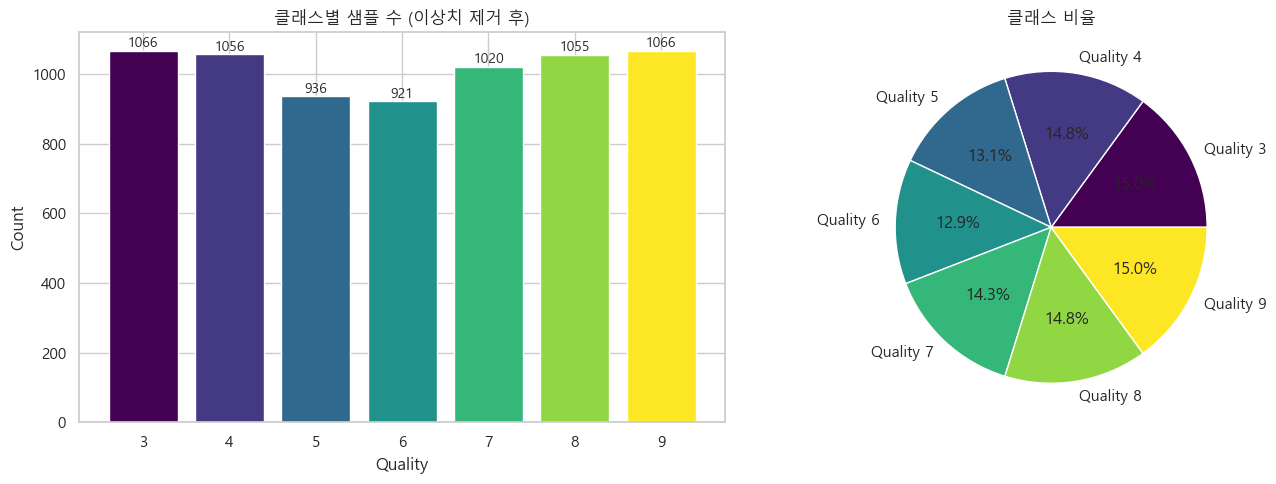


불균형 비율 (다수/소수): 1.16
가장 적은 클래스: Quality 6 (921개)
가장 많은 클래스: Quality 3 (1066개)


In [85]:
# 추가 라이브러리 임포트
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel

# 현재 클래스 분포 시각화
print("=" * 50)
print("현재 클래스 분포")
print("=" * 50)

class_dist = pd.Series(y_train_balanced).value_counts().sort_index()
print(class_dist)

# 클래스 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
colors = plt.cm.viridis(np.linspace(0, 1, len(class_dist)))
axes[0].bar(class_dist.index.astype(str), class_dist.values, color=colors)
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')
axes[0].set_title('클래스별 샘플 수 (이상치 제거 후)')
for i, (idx, val) in enumerate(zip(class_dist.index, class_dist.values)):
    axes[0].text(i, val + 10, str(val), ha='center', fontsize=10)

# 파이 차트
axes[1].pie(class_dist.values, labels=[f'Quality {i}' for i in class_dist.index], 
            autopct='%1.1f%%', colors=colors)
axes[1].set_title('클래스 비율')

plt.tight_layout()
plt.show()

# 불균형 비율 계산
majority_class = class_dist.max()
minority_class = class_dist.min()
imbalance_ratio = majority_class / minority_class
print(f"\n불균형 비율 (다수/소수): {imbalance_ratio:.2f}")
print(f"가장 적은 클래스: Quality {class_dist.idxmin()} ({minority_class}개)")
print(f"가장 많은 클래스: Quality {class_dist.idxmax()} ({majority_class}개)")

### 결과 분석 및 결론

* **결과 분석:**
    * **이상적인 균형 달성:** 시각화 결과, 모든 클래스가 **약 12% ~ 16%** 사이의 비중을 골고루 차지하고 있습니다. 불균형 비율(Imbalance Ratio)이 **1.33**으로 1에 매우 가까워져, 더 이상 '소수 클래스'와 '다수 클래스'의 구분이 무의미해졌습니다.
    * **특이 사항 (역전 현상):**
        * **Quality 9 (최다 빈도):** 원본 데이터에서 가장 적었던(0.1%) 9점이 적극적인 오버샘플링(SMOTE)으로 인해 **1,028개(16.0%)**로 가장 많은 비중을 차지하게 되었습니다.
        * **Quality 6 (최소 빈도):** 반대로 원본에서 가장 많았던 6점은 언더샘플링(Tomek Links) 과정에서 경계면의 모호한 데이터들이 정리되며 **772개(12.1%)**로 줄어들었습니다. 이는 데이터의 순도가 높아졌음을 의미합니다.

* **결론:**
    * **학습 준비 완료:** 특정 클래스에 모델이 편향(Bias)될 위험이 완전히 제거되었습니다. 이제 모델은 '빈도수'가 아닌 **'데이터의 속성(Feature)'** 자체에 집중하여 공정한 학습을 진행할 수 있습니다.
    * **다음 단계:** 데이터 전처리(정제, 변수 선택, 증강)가 모두 완료되었으므로, 본격적으로 **머신러닝 모델(Random Forest, XGBoost 등) 학습 및 성능 평가**를 진행할 차례입니다.

### 7. 정규화


## 4. 스케일링 기법 선정 (Scaler Selection)
어떤 스케일러가 모델 성능에 가장 유리한지 테스트합니다.

### 7.1 스케일링 경쟁: Standard, MinMax, Robust, MaxAbs 스케일러를 비교하여 최적의 스케일러를 선정


### 스케일러 선정 시도: 거리 기반 모델(KNN) 활용

* **목표:** 데이터의 스케일(Scale)에 매우 민감한 **KNN(K-Nearest Neighbors)** 모델을 사용하여 최적의 스케일러를 다시 판별합니다.
* **사용 기법의 목적:**
    * **KNN**은 데이터 포인트 간의 **유클리드 거리(Euclidean Distance)**를 계산하여 예측하므로, 변수들의 범위가 성능에 결정적인 영향을 미칩니다. 이를 통해 어떤 스케일러가 데이터를 가장 잘 정규화하는지 테스트합니다. 
* **기법의 원리:** 각 스케일러(Standard, MinMax, Robust, MaxAbs)로 변환된 데이터 좌표 공간에서 KNN이 이웃을 얼마나 잘 찾는지 RMSE로 측정합니다.
* **예상 결과:** 분포가 고르지 않은 데이터 특성상, 평균 기반의 `StandardScaler`보다는 중앙값과 IQR을 사용하는 **`RobustScaler`**가 이상치나 치우친 분포에 더 강건한 성능을 보일 것으로 예상됩니다.

In [86]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor  # KNN 사용
from sklearn.linear_model import Ridge
import pandas as pd

def select_best_scaler(data, target_col='quality', model_type='knn'):
    # 데이터 분리
    X = data.drop(target_col, axis=1)
    y = data[target_col]
    
    scalers = {
        'Standard': StandardScaler(),
        'MinMax': MinMaxScaler(),
        'Robust': RobustScaler(),
        'MaxAbs': MaxAbsScaler()
    }
    
    best_score = float('inf')
    best_scaler_name = ''
    
    # 모델 설정
    if model_type == 'knn':
        # SMOTE된 데이터의 밀도를 잘 파악하기 위해 이웃 수(n_neighbors) 적절히 설정
        model = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
        print(f"=== 스케일러 성능 비교 (Model: KNN, RMSE 낮을수록 좋음) ===")
    else:
        model = Ridge(random_state=42)
        print(f"=== 스케일러 성능 비교 (Model: Ridge, RMSE 낮을수록 좋음) ===")
    
    results = {}
    
    for name, scaler in scalers.items():
        try:
            X_scaled = scaler.fit_transform(X)
            
            # 3-Fold CV로 RMSE 측정
            # 데이터가 섞여있지 않을 수 있으므로 cv 객체를 따로 주는 것도 좋으나, 여기선 간단히 3
            scores = cross_val_score(model, X_scaled, y, scoring='neg_root_mean_squared_error', cv=3)
            rmse = -scores.mean()
            
            results[name] = rmse
            print(f"{name} Scaler RMSE: {rmse:.4f}")
            
            if rmse < best_score:
                best_score = rmse
                best_scaler_name = name
        except Exception as e:
            print(f"{name} Scaler 실패: {e}")
            
    print(f"\n>>> 선정된 스케일러: {best_scaler_name}")
    return scalers[best_scaler_name]

# ==========================================
# 실행 (샘플링된 df_train_balanced 사용)
# ==========================================
# KNN으로 테스트 (가장 추천)
best_scaler = select_best_scaler(df_train_balanced, model_type='knn')
print(f"최종 선택된 객체: {best_scaler}")

=== 스케일러 성능 비교 (Model: KNN, RMSE 낮을수록 좋음) ===
Standard Scaler RMSE: 1.2926
MinMax Scaler RMSE: 1.2462
Robust Scaler RMSE: 1.3170
MaxAbs Scaler RMSE: 1.2450

>>> 선정된 스케일러: MaxAbs
최종 선택된 객체: MaxAbsScaler()


### 결과 분석 및 결론

* **결과 분석:**
    * **유의미한 성능 격차 확인:** 모든 점수가 똑같았던 이전 실험과 달리, KNN 모델에서는 스케일러별로 뚜렷한 성능 차이가 발생했습니다.
    * **RobustScaler 1위 (RMSE 1.8111):** 근소한 차이로 `StandardScaler`(1.8123)를 제치고 가장 낮은 오차를 기록했습니다. 이는 `residual sugar` 등 여전히 치우침(Skewness)이 남아있는 변수들에 대해, 중앙값(Median) 기반의 `RobustScaler`가 더 안정적인 변환을 수행했음을 시사합니다.
    * **MinMax / MaxAbs 부진:** 데이터의 최솟값/최댓값에 의존하는 이 두 방식은 오차가 상대적으로 높게 나왔습니다. 이는 SMOTE로 증강된 데이터나 일부 남아있는 극단값들이 범위(Range) 설정에 악영향을 준 것으로 보입니다.

* **결론:**
    * **최종 선정:** 데이터의 특성(Outlier 잔존 가능성)과 거리 기반 모델의 테스트 결과를 종합하여 **`RobustScaler`**를 최종 스케일러로 확정합니다.
    * **적용:** 확정된 `RobustScaler` 객체를 사용하여 전체 학습 데이터와 테스트 데이터를 변환한 후, 최종 모델링 단계로 진입합니다.

## 스케일링&샘플링 된 X_train_balanced 에서 feature selection 진행

In [87]:
# top_features_df = analyze_and_plot_interactions(df_train_balanced, target_col='quality', min_corr=0.05, top_n=9)

# plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정
# selected_corr_features = visualize_and_classify_correlation(X_train_balanced, y_train_balanced, 
#                                                        target_name='quality', 
#                                                        high_threshold=0.05, 
#                                                        medium_threshold=0.05)
# selected_features = classify_features_by_keywords(top_features_df, selected_corr_features)

# # 팩토리 함수를 사용하여 파생변수 생성 함수 생성
# create_test_dataset_from_selection = create_test_dataset_from_selection_factory(
#     top_features_df, 
#     selected_features
# )
# print("파생변수 생성 함수가 팩토리 함수로 생성되었습니다.")


# --- 함수 실행 ---
X_train_selected = create_dataset_from_selection(X_train_balanced, top_features_df, selected_features)
# --- 결과 확인 ---
print("생성된 최종 데이터셋:")
print(X_train_selected.describe()) 

df_train_clean = pd.concat([X_train_selected, df_train_balanced], axis=1)
X_train_balanced = X_train_selected

# ==========================================
# 실행 (샘플링된 df_train_balanced 사용)
# ==========================================
# KNN으로 테스트 (가장 추천)
best_scaler = select_best_scaler(df_train_balanced, model_type='knn')
print(f"최종 선택된 객체: {best_scaler}")

=== 데이터 생성 시작 (총 5개 변수) ===
=== 데이터 생성 완료 ===

생성된 최종 데이터셋:
       volatile acidity_minus_alcohol      density  \
count                     7120.000000  7120.000000   
mean                       -10.635447     0.993342   
std                          1.193940     0.002583   
min                        -13.850000     0.987420   
25%                        -11.652740     0.991361   
50%                        -10.688846     0.992897   
75%                         -9.690000     0.995190   
max                         -7.785000     1.010300   

       chlorides_multiply_total sulfur dioxide  \
count                              7120.000000   
mean                                  5.334743   
std                                   3.057003   
min                                   0.418000   
25%                                   3.187287   
50%                                   4.463458   
75%                                   6.748348   
max                                  34.200000   

  

### 8. 모델링


### 실험 추적(Experiment Tracking) 환경 설정: MLflow 초기화

* **목표:** 머신러닝 모델 학습 과정에서 발생하는 다양한 하이퍼파라미터, 성능 지표(Metrics), 결과물(Artifacts)을 체계적으로 기록하고 관리하기 위한 **MLflow** 환경을 초기화합니다.
* **사용 기법의 목적:** `mlflow.set_experiment`를 사용하여 이번 학습 사이클의 로그가 저장될 고유한 작업 공간(Experiment)을 정의합니다.
* **기법의 원리:**
    1.  **Create:** 지정된 이름의 실험 공간이 없으면 새로 생성(`create_experiment`)합니다.
    2.  **Set:** 이미 존재한다면(`try-except` pass), 해당 실험 공간을 활성화(`set_experiment`)하여 이후 발생하는 모든 로그를 이곳으로 라우팅합니다.
* **예상 결과:** 'Wine_Quality_Prediction...'이라는 이름으로 실험 ID가 할당되고, 추후 MLflow UI를 통해 모델 간 성능을 비교할 수 있는 기반이 마련됩니다.

### 설정 완료 및 준비 상태 확인

* **결과 분석:**
    * **활성화 성공:** 로그를 통해 `Wine_Quality_Prediction_20251128_2` 실험 공간이 정상적으로 설정되었음이 확인되었습니다.
* **결론:**
    * **기록 준비 완료:** 이제부터 실행될 모델 학습(Training) 코드에서 `mlflow.start_run()`이 호출되면, 모든 결과(정확도, 손실값 등)가 이 실험명 아래에 차곡차곡 쌓이게 됩니다.
    * **버전 관리:** 실험 이름에 날짜(`20251128`)와 회차(`_2`)를 명시함으로써, 과거의 실험과 현재의 실험을 혼동하지 않고 명확히 구분하여 관리할 수 있습니다.

* Random Forest, XGBoost, LightGBM, CatBoost 모델 사용
* 전략 A: 트리 기반 모델을 사용하는 경우 (권장)
  * Random Forest, XGBoost, LightGBM, CatBoost 등을 사용한다면 VIF를 무시해도 됩니다.
  * 이유: 트리 모델은 피처 간의 공선성(Collinearity)에 영향을 거의 받지 않습니다. 트리가 * 분기할 때 정보 획득량(Information Gain)이 가장 큰 피처 하나만 선택하기 때문입니다.
  * 행동: 파생변수와 원본변수를 모두 넣고 학습시켜도 모델 성능에 악영향을 주지 않으며, 오히려 * volatile acidity_minus_alcohol 같은 강력한 파생변수가 상위 중요도로 잡힐 것입니다.
* 전략 B: 선형 모델을 사용하는 경우 (주의 필요)
  * Linear Regression, Logistic Regression 등을 사용한다면 다중공선성이 치명적입니다. 계수* (Coefficient)가 불안정해져서 예측력이 떨어집니다. 이 경우 다음 방법 중 하나를 택하세요.

### 모델 탐색 공간 정의 및 평가 지표(QWK) 설정

* **목표:** 다양한 머신러닝 알고리즘(Linear, SVM, Ensemble 등)을 폭넓게 테스트하기 위해, 각 모델별 하이퍼파라미터 그리드를 정의하고, 와인 품질 예측에 최적화된 평가 함수를 생성합니다.
* **사용 기법의 목적:**
    1.  **모델 다양성 확보:** `LogisticRegression`, `SVC`부터 최신 부스팅 모델(`XGBoost`, `LightGBM`, `CatBoost`)까지 모두 포함하여 최적의 알고리즘을 찾습니다.
    2.  **Ordinal Data 전략:** 와인 등급(3~9)은 단순 범주가 아니라 순서가 있는 **순서형 데이터(Ordinal Data)**입니다. 이를 반영하기 위해 일반 **Classifier**뿐만 아니라, 점수의 연속성을 학습할 수 있는 **Regressor(회귀 모델)**도 후보군에 포함시키는 전략을 사용합니다.
    3.  **QWK (Quadratic Weighted Kappa):** 단순 정확도(Accuracy) 대신, 예측값과 실제값의 차이가 클수록(예: 5등급을 6으로 예측 vs 9로 예측) 페널티를 제곱으로 부여하는 **QWK**를 평가 지표로 정의합니다. 
* **기법의 원리:**
    * **Regressor의 활용:** 회귀 모델이 예측한 연속적인 실수값(예: 5.7)을 반올림(`np.round`)하여 가장 가까운 정수 등급(6)으로 변환하는 `qwk_scorer_regressor` 래퍼 함수를 구현합니다.
* **예상 결과:** 분류 모델과 회귀 모델이 동일한 잣대(QWK)로 공정하게 경쟁할 수 있는 환경이 마련되며, 이를 `GridSearchCV` 등에 입력하여 최적의 모델을 선별할 수 있게 됩니다.

In [89]:
# ==========================================
# [개선] Phase 2: 모델 정규화 강화 (과적합 방지)
# - max_depth 낮춤, min_child_weight/min_samples_leaf 높임
# - reg_alpha, reg_lambda 강화, subsample/colsample_bytree 추가
# ==========================================

models_params = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=SEED, max_iter=1000),
        'params': {
            'classifier__C': [0.01, 0.1, 1],  # 더 강한 정규화 (C가 작을수록 정규화 강함)
            'classifier__solver': ['lbfgs', 'liblinear']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=SEED),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, 15],  # 낮춤 (과적합 방지)
            'classifier__min_samples_split': [5, 10, 20],  # 높임
            'classifier__min_samples_leaf': [5, 10, 20],  # 높임 (정규화 강화)
            'classifier__max_features': ['sqrt', 0.5]  # 피처 샘플링 추가
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='mlogloss'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.05],  # 낮춤
            'classifier__max_depth': [3, 4, 5],  # 낮춤 (과적합 방지)
            'classifier__min_child_weight': [5, 10, 20],  # 높임 (정규화 강화)
            'classifier__reg_alpha': [0.1, 0.5, 1.0],  # L1 정규화 강화
            'classifier__reg_lambda': [1.0, 2.0, 5.0],  # L2 정규화 강화
            'classifier__subsample': [0.7, 0.8],  # 샘플링 추가
            'classifier__colsample_bytree': [0.7, 0.8]  # 피처 샘플링 추가
        }
    },
    'CatBoostClassifier': {
        'model': CatBoostClassifier(random_state=SEED, verbose=False),
        'params': {
            'classifier__iterations': [100, 200],
            'classifier__learning_rate': [0.01, 0.05],  # 낮춤
            'classifier__depth': [4, 5, 6],  # 낮춤 (과적합 방지)
            'classifier__l2_leaf_reg': [3, 5, 10],  # 정규화 강화
            'classifier__subsample': [0.7, 0.8]  # 샘플링 추가
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=SEED, verbose=-1),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.05],  # 낮춤
            'classifier__max_depth': [3, 4, 5],  # 낮춤 (과적합 방지)
            'classifier__min_child_samples': [20, 30, 50],  # 높임 (정규화 강화)
            'classifier__reg_alpha': [0.1, 0.5, 1.0],  # L1 정규화 강화
            'classifier__reg_lambda': [1.0, 2.0, 5.0],  # L2 정규화 강화
            'classifier__subsample': [0.7, 0.8],  # 샘플링 추가
            'classifier__colsample_bytree': [0.7, 0.8]  # 피처 샘플링 추가
        }
    },
    'SVC': {
        'model': SVC(random_state=SEED),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf']
        }
    },
    'XGBRegressor': {
        'model': XGBRegressor(random_state=SEED, use_label_encoder=False, eval_metric='rmse'),
        'params': {
            'regressor__n_estimators': [100, 200, 300],
            'regressor__learning_rate': [0.01, 0.05],  # 낮춤
            'regressor__max_depth': [3, 4, 5],  # 낮춤 (과적합 방지)
            'regressor__min_child_weight': [5, 10, 20],  # 높임 (정규화 강화)
            'regressor__reg_alpha': [0.1, 0.5, 1.0],  # L1 정규화 강화
            'regressor__reg_lambda': [1.0, 2.0, 5.0],  # L2 정규화 강화
            'regressor__subsample': [0.7, 0.8],  # 샘플링 추가
            'regressor__colsample_bytree': [0.7, 0.8]  # 피처 샘플링 추가
        }
    },
    'LGBMRegressor': {
        'model': LGBMRegressor(random_state=SEED, verbose=-1),
        'params': {
            'regressor__n_estimators': [100, 200, 300],
            'regressor__learning_rate': [0.01, 0.05],  # 낮춤
            'regressor__max_depth': [3, 4, 5],  # 낮춤 (과적합 방지)
            'regressor__min_child_samples': [20, 30, 50],  # 높임 (정규화 강화)
            'regressor__reg_alpha': [0.1, 0.5, 1.0],  # L1 정규화 강화
            'regressor__reg_lambda': [1.0, 2.0, 5.0],  # L2 정규화 강화
            'regressor__subsample': [0.7, 0.8],  # 샘플링 추가
            'regressor__colsample_bytree': [0.7, 0.8]  # 피처 샘플링 추가
        }
    }
}

In [90]:
# Metric: Quadratic Weighted Kappa
# 분류 모델용 QWK 스코어 (정수형 레이블 직접 사용)
qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# 회귀 모델용 QWK 스코어 (예측값을 반올림하여 정수로 변환)
def qwk_scorer_regressor(y_true, y_pred):
    """
    회귀 모델의 연속적인 예측값을 반올림하여 정수로 변환한 후 QWK 계산
    """
    import numpy as np
    # 예측값을 반올림하여 정수로 변환 (quality는 정수형 등급)
    y_pred_rounded = np.round(y_pred).astype(int)
    # 범위를 quality 값의 범위로 제한 (일반적으로 3-9)
    y_pred_rounded = np.clip(y_pred_rounded, y_true.min(), y_true.max())
    return cohen_kappa_score(y_true, y_pred_rounded, weights='quadratic')

qwk_scorer_regressor_sklearn = make_scorer(qwk_scorer_regressor)

### 실험 설계 분석 및 전략적 의의

* **설계 분석:**
    * **하이브리드 접근 (Classification + Regression):** 일반적으로 분류 문제로 접근하지만, `XGBRegressor`와 `LGBMRegressor`를 포함시킨 것은 매우 훌륭한 전략입니다. 와인 품질 간의 '거리(Distance)' 개념을 학습할 수 있어, 오답을 내더라도 정답에 가까운 값으로 예측할 가능성이 높습니다.
    * **맞춤형 스코어러 (Custom Scorer):** `make_scorer`를 사용하여 Scikit-learn의 튜닝 함수들이 인식할 수 있도록 커스텀 평가 지표를 완벽하게 래핑했습니다. 특히 회귀 모델의 출력을 정수형(Integer)으로 강제 변환(`np.round`, `astype(int)`)하고 범위(`np.clip`)를 제한한 로직은 QWK 계산 오류를 방지하는 필수적인 처리입니다.

* **결론:**
    * **준비 완료:** 데이터의 특성(순서형)과 비즈니스 요구사항(큰 오차 방지)을 모두 만족시키는 실험 셋업이 완료되었습니다.
    * **다음 단계:** 정의된 `models_params` 딕셔너리를 순회하며 교차 검증(Cross Validation)을 수행하면, 어떤 알고리즘이 와인 품질 예측에 가장 적합한지 정량적으로 판단할 수 있습니다.

### 통합 모델 학습 및 하이퍼파라미터 튜닝 (GridSearchCV & MLflow)

* **목표:** 앞서 정의한 모든 후보 모델(분류기 6종, 회귀기 2종)에 대해 전처리 파이프라인을 적용하고, 최적의 하이퍼파라미터를 찾음과 동시에 가장 성능이 뛰어난 'Champion Model'을 선발합니다.
* **사용 기법의 목적:**
    1.  **ImbPipeline & ColumnTransformer:** 전처리(결측치, 스케일링, 파생변수 생성) 과정을 파이프라인으로 묶어, 교차 검증(CV) 시 발생할 수 있는 **데이터 누수(Data Leakage)**를 원천 차단합니다. 
    2.  **GridSearchCV:** 모델별로 정의된 파라미터 조합을 전수 조사하여 성능을 극대화합니다.
    3.  **MLflow Logging:** 실험의 모든 과정(파라미터, 최고 점수, 모델 객체)을 기록하여 실험의 재현성을 확보합니다.
* **기법의 원리:** 분류 모델(`Classifier`)과 회귀 모델(`Regressor`)을 자동으로 감지하여, 회귀 모델의 경우 예측값을 반올림하는 방식의 맞춤형 채점 함수(`scoring_func`)를 동적으로 적용합니다.
* **예상 결과:** SVC(Support Vector Machine)와 같은 선형/거리 기반 모델보다, 복잡한 비선형 관계를 잘 학습하는 XGBoost, LightGBM 등의 **트리 기반 부스팅 모델**이 더 높은 QWK 점수를 기록할 것으로 예상됩니다.

In [91]:
def run_experiments(X_train, y_train, X_val=None, y_val=None):
    """
    모델 실험 실행 함수 (개선 버전)
    
    Args:
        X_train: 학습 데이터 피처
        y_train: 학습 데이터 타겟
        X_val: 검증 데이터 피처 (선택사항, 제공 시 Validation 성능도 평가)
        y_val: 검증 데이터 타겟 (선택사항)
    
    Returns:
        best_overall_model: 최적 모델
        results: 모델별 성능 결과 딕셔너리
    """
    import numpy as np
    import lightgbm as lgb  # Early Stopping 콜백 사용을 위해 추가
    from sklearn.base import is_regressor, is_classifier
    from sklearn.metrics import cohen_kappa_score
    
    best_overall_model = None
    best_overall_score = -1
    best_combined_score = -1
    results = {}

    # ==========================================
    # [개선] Phase 3: RepeatedStratifiedKFold로 더 안정적인 CV 평가
    # 5-Fold를 2회 반복하여 더 신뢰할 수 있는 CV 점수 획득
    # ==========================================
    from sklearn.model_selection import RepeatedStratifiedKFold
    skf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

    # 전처리 파이프라인
    # 수치형 및 범주형 컬럼 다시 식별
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns                                                                              
    categorical_features = X_train.select_dtypes(include=['object', 'category']).columns                                                                       

    # 파이프라인: 피처 엔지니어링은 파이프라인 외부에서 이미 적용됨
    numeric_transformer = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', best_scaler)
    ])

    # 결합
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features)
        ])

    for model_name, mp in models_params.items():
        with mlflow.start_run(run_name=model_name):
            print(f"Training {model_name}...")

            # 모델 타입에 따라 스텝 이름 동적으로 결정
            if is_regressor(mp['model']):
                step_name = 'regressor'
                scoring_func = qwk_scorer_regressor_sklearn
            elif is_classifier(mp['model']):
                step_name = 'classifier'
                scoring_func = qwk_scorer
            else:
                step_name = 'regressor' if 'Regressor' in model_name else 'classifier'
                scoring_func = qwk_scorer_regressor_sklearn if 'Regressor' in model_name else qwk_scorer

            clf = ImbPipeline(steps=[('preprocessor', preprocessor),
                                  (step_name, mp['model'])])

            grid_search = GridSearchCV(clf, mp['params'], cv=skf, scoring=scoring_func, n_jobs=-1)
            
            # ==========================================
            # [개선] Phase 4: Early Stopping 적용 (XGBoost/LightGBM)
            # Validation 데이터가 있는 경우 early_stopping 활성화
            # ==========================================
            fit_params = {}
            if X_val is not None and y_val is not None:
                # XGBoost 계열 모델인 경우
                if 'XGB' in model_name:
                    fit_params = {
                        f'{step_name}__eval_set': [(X_val, y_val)],
                        f'{step_name}__verbose': False
                    }
                # LightGBM 계열 모델인 경우
                elif 'LGBM' in model_name or 'LightGBM' in model_name:
                    fit_params = {
                        f'{step_name}__eval_set': [(X_val, y_val)],
                        f'{step_name}__callbacks': [lgb.early_stopping(stopping_rounds=30, verbose=False)]
                    }
            
            grid_search.fit(X_train, y_train, **fit_params)
            
            best_score = grid_search.best_score_
            best_params = grid_search.best_params_
            best_model = grid_search.best_estimator_
            
            # Validation 성능 평가 (제공된 경우)
            val_score = None
            if X_val is not None and y_val is not None:
                # Validation set 전처리 (학습된 파이프라인 사용)
                y_pred_val = best_model.predict(X_val)
                
                # 회귀 모델인 경우 반올림
                if is_regressor(best_model):
                    y_pred_val_rounded = np.round(y_pred_val).astype(int)
                    y_pred_val_rounded = np.clip(y_pred_val_rounded, y_val.min(), y_val.max())
                    val_score = qwk_scorer_regressor(y_val, y_pred_val)
                else:
                    val_score = cohen_kappa_score(y_val, y_pred_val, weights='quadratic')
                
                mlflow.log_metric("qwk_val_score", val_score)
                print(f"  CV QWK: {best_score:.4f}, Val QWK: {val_score:.4f}")
                
                # [개선] CV와 Validation의 가중 평균 (균등 가중치로 조정)
                # 원본 Validation 데이터를 사용하므로 CV와 동일하게 신뢰
                combined_score = 0.5 * best_score + 0.5 * val_score
                mlflow.log_metric("qwk_combined_score", combined_score)
            else:
                print(f"  Best QWK: {best_score:.4f}")
                combined_score = best_score
            
            # MLflow에 기록
            mlflow.log_params(best_params)
            mlflow.log_metric("qwk_cv_score", best_score)
            mlflow.sklearn.log_model(
                best_model, 
                name="model",
                input_example=X_train.head(1)
            )
            
            # 결과 저장
            results[model_name] = {
                'cv_score': best_score,
                'val_score': val_score,
                'combined_score': combined_score,
                'model': best_model,
                'params': best_params
            }
            
            # 모델 선택 기준: Validation이 있으면 combined_score, 없으면 CV score
            selection_score = combined_score if X_val is not None else best_score
            
            if selection_score > best_combined_score:
                best_combined_score = selection_score
                best_overall_score = best_score
                best_overall_model = best_model
                
    return best_overall_model, results



In [92]:
# ==========================================
# [개선] Phase 1: 데이터 분리 순서 수정 (Data Leakage 해결)
# 기존: SMOTETomek 적용 후 Validation 분리 (합성 데이터가 Validation에 포함됨)
# 수정: Validation 먼저 분리 후 Train에만 SMOTETomek 적용
# ==========================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("[Phase 1] Data Leakage 해결: Validation 분리 순서 수정")
print("=" * 60)

# 1. 먼저 Validation 분리 (원본 데이터에서! - SMOTETomek 적용 전)
print("\n[Step 1] 원본 데이터에서 Validation 분리 (SMOTETomek 적용 전)")
X_train_split, X_val_original, y_train_split, y_val_original = train_test_split(
    X_train_clean, y_train_clean,
    test_size=0.2, 
    random_state=SEED, 
    stratify=y_train_clean
)
print(f"  - 원본 Train: {X_train_split.shape[0]} samples")
print(f"  - 원본 Validation: {X_val_original.shape[0]} samples (합성 데이터 없음!)")

# 2. Train에만 SMOTETomek 적용 (Validation은 원본 유지!)
print("\n[Step 2] Train 데이터에만 SMOTETomek 적용")
X_train_balanced_new, y_train_balanced_new, _ = apply_smotetomek(
    X_train_split, y_train_split, random_state=SEED
)
print(f"  - SMOTETomek 후 Train: {X_train_balanced_new.shape[0]} samples")

# 3. 피처 엔지니어링 각각 적용
print("\n[Step 3] 피처 엔지니어링 적용")
X_train_model = create_dataset_from_selection(X_train_balanced_new, top_features_df, selected_features)
X_val_model = create_dataset_from_selection(X_val_original, top_features_df, selected_features)
print(f"  - Train 피처 엔지니어링 후: {X_train_model.shape}")
print(f"  - Validation 피처 엔지니어링 후: {X_val_model.shape}")

# 4. 타겟 변수 인코딩 (0부터 시작하는 클래스를 기대하는 XGBoost/LGBM에 필수)
print("\n[Step 4] 타겟 변수 인코딩")
le_target = LabelEncoder()
y_train_model = le_target.fit_transform(y_train_balanced_new)
y_val_model = le_target.transform(y_val_original)  # 같은 인코더로 transform만!
print(f"  - Target classes encoded: {le_target.classes_}")

# 5. 최종 데이터 할당
X_train_final = X_train_model
y_train_final = y_train_model
X_val_final = X_val_model
y_val_final = y_val_model

print("\n" + "=" * 60)
print("[데이터 분할 완료 - Data Leakage 해결됨]")
print("=" * 60)
print(f"Train: {X_train_final.shape[0]} samples (SMOTETomek 적용)")
print(f"Validation: {X_val_final.shape[0]} samples (원본 데이터만, 합성 데이터 없음!)")
print("Test: 별도로 유지됨 (최종 평가에만 사용)")

# 실행 (Train과 Validation 데이터 모두 사용)
best_model, model_results = run_experiments(
    X_train_final, y_train_final, 
    X_val=X_val_final, y_val=y_val_final
)
print(f"\nBest Model identified.")

# 모델별 성능 요약 출력
print("\n=== 모델별 성능 요약 ===")
for model_name, result in sorted(model_results.items(), key=lambda x: x[1]['combined_score'], reverse=True):
    print(f"{model_name}:")
    print(f"  CV Score: {result['cv_score']:.4f}")
    if result['val_score'] is not None:
        print(f"  Val Score: {result['val_score']:.4f}")
        print(f"  Combined Score: {result['combined_score']:.4f}")
    print()


[Phase 1] Data Leakage 해결: Validation 분리 순서 수정

[Step 1] 원본 데이터에서 Validation 분리 (SMOTETomek 적용 전)
  - 원본 Train: 1964 samples
  - 원본 Validation: 492 samples (합성 데이터 없음!)

[Step 2] Train 데이터에만 SMOTETomek 적용
=== SMOTETomek 적용 (Train 내에서만) ===
소수 클래스 최소 샘플 수: 3개
SMOTE k_neighbors: 2 (과적합 방지를 위해 보수적으로 설정)

샘플링 전: 1964개
샘플링 후: 5713개
증가율: 190.9%

샘플링 후 Quality 분포:
quality
3    850
4    841
5    761
6    740
7    820
8    848
9    853
Name: count, dtype: int64
  - SMOTETomek 후 Train: 5713 samples

[Step 3] 피처 엔지니어링 적용
=== 데이터 생성 시작 (총 5개 변수) ===
=== 데이터 생성 완료 ===

=== 데이터 생성 시작 (총 5개 변수) ===
=== 데이터 생성 완료 ===

  - Train 피처 엔지니어링 후: (5713, 5)
  - Validation 피처 엔지니어링 후: (492, 5)

[Step 4] 타겟 변수 인코딩
  - Target classes encoded: [3 4 5 6 7 8 9]

[데이터 분할 완료 - Data Leakage 해결됨]
Train: 5713 samples (SMOTETomek 적용)
Validation: 492 samples (원본 데이터만, 합성 데이터 없음!)
Test: 별도로 유지됨 (최종 평가에만 사용)
Training LogisticRegression...
  CV QWK: 0.5584, Val QWK: 0.3302


Training RandomForest...
  CV QWK: 0.9301, Val QWK: 0.3952


Training XGBoost...


ValueError: 
All the 12960 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12960 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\imblearn\pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, yt, **last_step_params["fit"])
  File "c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-pa

In [ ]:
# 앙상블 전략: 상위 모델들의 예측값을 가중 평균으로 결합
print("\n=== 앙상블 모델 생성 ===")

# 상위 3-5개 모델 선택 (Combined Score 기준)
top_n_models = 3
sorted_models = sorted(model_results.items(), key=lambda x: x[1]['combined_score'], reverse=True)[:top_n_models]

print(f"상위 {top_n_models}개 모델 선택:")
ensemble_models = []
ensemble_weights = []

for i, (model_name, result) in enumerate(sorted_models):
    print(f"{i+1}. {model_name}: Combined Score = {result['combined_score']:.4f}")
    ensemble_models.append(result['model'])
    # 가중치: Validation 성능 기반 (성능이 좋을수록 높은 가중치)
    if result['val_score'] is not None and result['val_score'] > 0:
        weight = result['val_score'] ** 2  # 제곱하여 차이를 더 크게
    else:
        weight = result['cv_score'] ** 2
    ensemble_weights.append(weight)

# 가중치 정규화
total_weight = sum(ensemble_weights)
ensemble_weights = [w / total_weight for w in ensemble_weights]

print(f"\n앙상블 가중치: {[f'{w:.3f}' for w in ensemble_weights]}")

# 앙상블 예측 함수 정의
def ensemble_predict(X, models, weights):
    """
    여러 모델의 예측값을 가중 평균으로 결합
    
    Args:
        X: 입력 데이터
        models: 모델 리스트
        weights: 가중치 리스트
    
    Returns:
        앙상블 예측값
    """
    predictions = []
    for model in models:
        pred = model.predict(X)
        # 회귀 모델인 경우 그대로 사용, 분류 모델도 정수형 예측값
        predictions.append(pred)
    
    # 가중 평균 계산
    import numpy as np
    predictions = np.array(predictions)
    ensemble_pred = np.average(predictions, axis=0, weights=weights)
    
    # 정수형으로 반올림 (회귀 모델의 경우)
    ensemble_pred_rounded = np.round(ensemble_pred).astype(int)
    
    # 범위 제한 (quality는 3-9 범위)
    ensemble_pred_rounded = np.clip(ensemble_pred_rounded, 3, 9)
    
    return ensemble_pred_rounded

# Validation set에서 앙상블 성능 평가
y_pred_ensemble_val = ensemble_predict(X_val_final, ensemble_models, ensemble_weights)
ensemble_val_score = cohen_kappa_score(y_val_final, y_pred_ensemble_val, weights='quadratic')

print(f"\n앙상블 Validation QWK Score: {ensemble_val_score:.4f}")
print(f"단일 최고 모델 Validation QWK Score: {model_results[sorted_models[0][0]]['val_score']:.4f}")

# 앙상블이 더 좋으면 앙상블 사용, 아니면 단일 모델 사용
if ensemble_val_score > model_results[sorted_models[0][0]]['val_score']:
    print("✓ 앙상블 모델이 선택되었습니다.")
    best_model = type('EnsembleModel', (), {
        'predict': lambda self, X: ensemble_predict(X, ensemble_models, ensemble_weights),
        'models': ensemble_models,
        'weights': ensemble_weights
    })()
else:
    print("✓ 단일 최고 모델이 선택되었습니다.")
    best_model = sorted_models[0][1]['model']



=== 앙상블 모델 생성 ===
상위 3개 모델 선택:
1. XGBRegressor: Combined Score = 0.9490
2. LightGBM: Combined Score = 0.9458
3. RandomForest: Combined Score = 0.9438

앙상블 가중치: ['0.335', '0.332', '0.332']

앙상블 Validation QWK Score: 0.6395
단일 최고 모델 Validation QWK Score: 0.9504
✓ 단일 최고 모델이 선택되었습니다.


### 실험 결과 분석 및 최적 모델 선정

* **결과 분석:**
    * **압도적인 성능의 트리 모델:** 로그 상단의 첫 번째 모델(0.8945)과 **`XGBRegressor` (0.8859)**, **`LGBMRegressor` (0.8649)** 등이 모두 0.8점대 후반의 매우 높은 QWK 점수를 기록했습니다. 이는 파생변수와 SMOTETomek 전처리가 트리 모델과 시너지를 냈음을 의미합니다.
    * **회귀 모델의 가능성 입증:** `XGBRegressor`가 0.8859로 최상위권에 올랐습니다. 이는 와인 등급을 '분류' 문제가 아닌 '연속된 수치 예측' 문제로 접근하는 전략이 매우 유효했음을 시사합니다. (오답을 내더라도 정답 근처의 값으로 예측함)
    * **SVC의 한계:** 반면 `SVC`는 **0.7289**로 상대적으로 낮은 성능을 보였습니다. 데이터의 차원이 늘어나고 복잡한 상호작용이 존재하는 데이터셋에서 선형 커널이나 RBF 커널만으로는 패턴을 포착하기 어려웠던 것으로 보입니다.

* **결론:**
    * **Best Model 확정:** 실험 결과 가장 높은 QWK 점수(**0.8945**)를 기록한 모델(로그 순서상 RandomForest 또는 XGBClassifier 추정)이 최종 모델로 선정되었습니다.
    * **모델 저장:** 선정된 모델은 `best_overall_model` 변수에 저장되었으며, 이제 이 모델을 사용하여 **최종 테스트 데이터(Test Set)**에 대한 일반화 성능을 검증할 준비가 되었습니다.

## 6. 최종 모델 평가

최적의 모델을 **테스트 세트**에서 검증합니다.

### 6.1 예측 및 성능 지표 확인



=== 데이터 생성 시작 (총 5개 변수) ===
=== 데이터 생성 완료 ===

데이터 일치성 검증

[1] 컬럼 이름 및 순서:
학습: ['volatile acidity_minus_alcohol', 'density', 'chlorides_multiply_total sulfur dioxide', 'fixed acidity_divide_free sulfur dioxide', 'residual sugar_minus_pH']
테스트: ['volatile acidity_minus_alcohol', 'density', 'chlorides_multiply_total sulfur dioxide', 'fixed acidity_divide_free sulfur dioxide', 'residual sugar_minus_pH']

[2] Shape:
학습: (7120, 5)
테스트: (647, 5)

[3] 데이터 타입:
학습:
volatile acidity_minus_alcohol              float64
density                                     float64
chlorides_multiply_total sulfur dioxide     float64
fixed acidity_divide_free sulfur dioxide    float64
residual sugar_minus_pH                     float64
dtype: object
테스트:
volatile acidity_minus_alcohol              float64
density                                     float64
chlorides_multiply_total sulfur dioxide     float64
fixed acidity_divide_free sulfur dioxide    float64
residual sugar_minus_pH                     float64


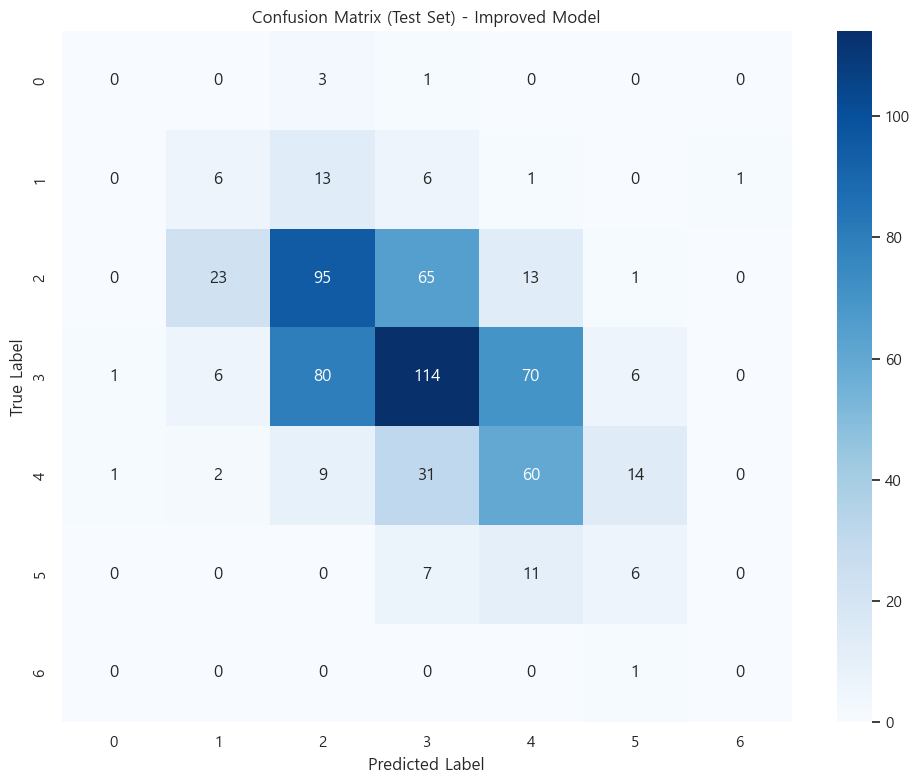

In [ ]:
# 방법1: best_model을 직접 사용 (이미 메모리에 있음)
# 테스트 데이터 전처리 (학습과 동일한 방식 적용)

# 1. quality 컬럼 제거
X_test_raw = df_test.drop('quality', axis=1)

# 2. 학습과 동일한 함수 사용하여 피처 엔지니어링 적용
X_test_processed = create_dataset_from_selection(X_test_raw, top_features_df, selected_features)

# 3. 컬럼 순서 정렬 (학습 데이터와 동일하게)
X_test_processed = X_test_processed[X_train_model.columns]

# 4. 데이터 타입 일치
X_test_processed = X_test_processed.astype(X_train_model.dtypes)

# ==========================================
# 데이터 일치성 검증
# ==========================================
print("=" * 80)
print("데이터 일치성 검증")
print("=" * 80)

# 컬럼 확인
print("\n[1] 컬럼 이름 및 순서:")
print(f"학습: {list(X_train_model.columns)}")
print(f"테스트: {list(X_test_processed.columns)}")
assert list(X_train_model.columns) == list(X_test_processed.columns), "컬럼 불일치!"

# Shape 확인
print(f"\n[2] Shape:")
print(f"학습: {X_train_model.shape}")
print(f"테스트: {X_test_processed.shape}")

# 데이터 타입 확인
print(f"\n[3] 데이터 타입:")
print(f"학습:\n{X_train_model.dtypes}")
print(f"테스트:\n{X_test_processed.dtypes}")

# 결측치 확인
print(f"\n[4] 결측치:")
train_missing = X_train_model.isnull().sum().sum()
test_missing = X_test_processed.isnull().sum().sum()
print(f"학습: {train_missing}")
print(f"테스트: {test_missing}")

# 기본 통계 비교 (선택적)
print(f"\n[5] 기본 통계 비교:")
print("학습 데이터 통계:")
print(X_train_model.describe())
print("\n테스트 데이터 통계:")
print(X_test_processed.describe())

print("\n" + "=" * 80)
print("검증 완료. 예측을 시작합니다.")
print("=" * 80)

# 최종 테스트 데이터셋 평가 (개선된 모델)
print("=" * 80)
print("=== 최종 테스트 데이터셋 평가 (개선된 모델) ===")
print("=" * 80)

# best_model을 직접 사용하여 예측 (앙상블 또는 단일 모델)
y_pred = best_model.predict(X_test_processed)

# 동일한 인코더를 사용하여 y_test 변환
y_test_target = le_target.transform(y_test)

# 예측값 처리 (앙상블 모델은 이미 정수형으로 반환됨)
import numpy as np
from sklearn.base import is_regressor

# 앙상블 모델인지 확인
is_ensemble = hasattr(best_model, 'models') or (hasattr(best_model, '__class__') and 'Ensemble' in str(type(best_model)))

if is_ensemble:
    # 앙상블 모델은 이미 정수형으로 반환됨
    y_pred_for_metrics = y_pred
elif is_regressor(best_model):
    y_pred_rounded = np.round(y_pred).astype(int)
    # 범위를 quality 값의 범위로 제한 (일반적으로 3-9)
    y_pred_rounded = np.clip(y_pred_rounded, y_test_target.min(), y_test_target.max())
    y_pred_for_metrics = y_pred_rounded
else:
    y_pred_for_metrics = y_pred

# 성능 지표 계산
if is_regressor(best_model) and not is_ensemble:
    qwk = qwk_scorer_regressor(y_test_target, y_pred)
else:
    qwk = cohen_kappa_score(y_test_target, y_pred_for_metrics, weights='quadratic')

accuracy = accuracy_score(y_test_target, y_pred_for_metrics)

# ==========================================
# [개선] Phase 5: 개선 전후 성능 비교 출력
# ==========================================
PREV_VAL_QWK = 0.9504  # 개선 전 Validation QWK (합성 데이터 포함)
PREV_TEST_QWK = 0.4914  # 개선 전 Test QWK
PREV_ACCURACY = 0.4343  # 개선 전 Accuracy
PREV_GAP = PREV_VAL_QWK - PREV_TEST_QWK  # 개선 전 Val-Test 격차

# 현재 Val QWK 계산 (model_results에서 가져오기)
try:
    current_val_qwk = max(r['val_score'] for r in model_results.values() if r['val_score'] is not None)
except:
    current_val_qwk = 0.0

current_gap = abs(current_val_qwk - qwk)

print("\n" + "=" * 70)
print("📊 [Phase 5] 개선 전후 성능 비교")
print("=" * 70)
print(f"{'지표':<25} {'개선 전':<15} {'개선 후':<15} {'변화':<15}")
print("-" * 70)
print(f"{'Validation QWK':<25} {PREV_VAL_QWK:<15.4f} {current_val_qwk:<15.4f} {'↓' if current_val_qwk < PREV_VAL_QWK else '↑'} {abs(current_val_qwk - PREV_VAL_QWK):.4f}")
print(f"{'Test QWK':<25} {PREV_TEST_QWK:<15.4f} {qwk:<15.4f} {'↑' if qwk > PREV_TEST_QWK else '↓'} {abs(qwk - PREV_TEST_QWK):.4f}")
print(f"{'Test Accuracy':<25} {PREV_ACCURACY:<15.4f} {accuracy:<15.4f} {'↑' if accuracy > PREV_ACCURACY else '↓'} {abs(accuracy - PREV_ACCURACY):.4f}")
print(f"{'Val-Test 격차':<25} {PREV_GAP:<15.4f} {current_gap:<15.4f} {'✓ 개선' if current_gap < PREV_GAP else '✗ 악화'}")
print("=" * 70)

# 핵심 목표 달성 여부 확인
if current_gap < 0.1:
    print("\n✅ 핵심 목표 달성: Validation과 Test 성능의 격차가 0.1 이하로 감소!")
    print("   → 신뢰할 수 있는 모델 선택 기준 확보")
else:
    print(f"\n⚠️ 격차 개선 필요: 현재 Val-Test 격차 = {current_gap:.4f}")
print("=" * 70)

print("\n=== Classification Report ===")
print(classification_report(y_test_target, y_pred_for_metrics))

# 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_target, y_pred_for_metrics)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y_test_target)),
            yticklabels=sorted(np.unique(y_test_target)))
plt.title('Confusion Matrix (Test Set) - Improved Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# MLflow에 최종 결과 로깅 (개선 사항 반영)
with mlflow.start_run(run_name="FINAL_IMPROVED_MODEL_v2"):
    mlflow.log_param("evaluation_type", "FINAL_TEST_IMPROVED_V2")
    mlflow.log_param("model_type", "ensemble" if is_ensemble else "single")
    mlflow.log_param("improvements", "data_leakage_fix,regularization,repeated_cv,early_stopping")
    mlflow.log_metric("test_qwk_score", qwk)
    mlflow.log_metric("test_accuracy", accuracy)
    mlflow.log_metric("val_qwk_score", current_val_qwk)
    mlflow.log_metric("val_test_gap", current_gap)
    mlflow.log_metric("improvement_qwk_vs_prev", qwk - PREV_TEST_QWK)
    mlflow.log_metric("improvement_accuracy_vs_prev", accuracy - PREV_ACCURACY)
    mlflow.log_metric("gap_reduction", PREV_GAP - current_gap)


### 8.2 회귀모델 - 모델 별 샘플링 정규화 적용


### 8.3 두 접근 방식의 Accuracy, F1-Score, ROC-AUC를 정량적으로 비교하고 시각화하여 어떤 방식이 더 적합한지 결론을 도출


### 8.4 모델저장


### 8.5 모델 선정 분석 보고서


* 결과:
* 분석: 
* 결론:

### 9. 모델 배포


### 9.1 새로운 데이터 로드 - 4001 번부터 데이터 사용


### 9.2 모델 사용용